# Species Identity Across Global K-Means Clusters

This notebook reads the `N=1000` global k-means states and asks how species identity is distributed across clusters. It saves count/proportion tables and compact diagnostic plots.

In [144]:
from pathlib import Path
import csv
import importlib
import pickle
import sys
import warnings
REPO_ROOT = Path('/Users/meganbishop/slowmodeevo').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pipeline as pp
import pooled_user_pipeline as pup
pup = importlib.reload(pup)
if not hasattr(pup, 'CovariancePCA'):
    raise AttributeError(f'pooled_user_pipeline missing CovariancePCA: {pup.__file__}')
import figures as fg
import gpcca_utils as gu
import all_pair_distance_data as apd
import fly_plot_recreation as fpr
fpr = importlib.reload(fpr)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def find_kmeans_root():
    base = REPO_ROOT / 'outputs/single_species_distance_comparison'
    candidates = []
    for value in ['pca_multispecies_evensamp' , 'multispecies_pca_wavelet_pca/pca_before_wavelet_pca_after_multispecies', 'pca_before_wavelet_pca_after_multispecies']:
        run_root = base / value
        candidates.extend([
            run_root / 'global_kmeans_N1000_balanced_species',
            run_root / 'global_kmeans_N1000',
        ])
    manifests = sorted(
        base.glob('**/global_kmeans_manifest.csv'),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    candidates.extend(path.parent for path in manifests)
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'global_kmeans_manifest.csv').exists():
            return candidate
    raise FileNotFoundError(
        'Could not find global_kmeans_manifest.csv. Run '
        '03_global_kmeans_all_species_N1000.ipynb first.'
    )

KMEANS_ROOT = find_kmeans_root()
OUT_DIR = KMEANS_ROOT / 'species_identity_by_cluster'
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_CLUSTERS = 1000
MIN_CLUSTER_FRAMES_FOR_HEATMAP = 1000
RAREFIED_ENTROPY_DEPTH = None  # None uses the smallest species total.
TOP_N_CLUSTERS = 60
TRANSFER_TOP_N_CLUSTERS = 80
SPECIES_TRANSFER_LAG_FRAMES = None
MOSEQ_TIMESERIES_CSV = Path('/Users/meganbishop/moseq_dataverse/multispecies_moseq_timeseries.csv')
UMAP_RANDOM_STATE = 14
N_BASINS = 4

MANIFEST_CSV = KMEANS_ROOT / 'global_kmeans_manifest.csv'
manifest = pd.read_csv(MANIFEST_CSV)
species_names = sorted(manifest['species'].dropna().astype(str).unique())
species_to_col = {species: i for i, species in enumerate(species_names)}
print(f'KMEANS_ROOT = {KMEANS_ROOT}')
print(f'{len(species_names)} species, {len(manifest)} individuals')
display(manifest.groupby('species')['n_embedded_frames'].agg(['count', 'sum']).reset_index())


KMEANS_ROOT = /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/pca_multispecies_evensamp/global_kmeans_N1000_balanced_species
8 species, 354 individuals


,species,count,sum
0,Mus_caroli,15,9288209
1,Mus_musculus,93,85753806
2,Mus_spretus,16,9720216
3,Peromyscus_californicus,23,5183673
4,Peromyscus_gossypinus,20,4319720
5,Peromyscus_leucopus,14,3023804
6,Peromyscus_maniculatus,129,31750104
7,Peromyscus_polionotus,44,10583359


## Count Species Frames Per Cluster

In [145]:
counts = np.zeros((N_CLUSTERS, len(species_names)), dtype=np.int64)
for _, row in manifest.iterrows():
    states = np.load(row['state_file'], mmap_mode='r')
    species_col = species_to_col[str(row['species'])]
    counts[:, species_col] += np.bincount(states.astype(int), minlength=N_CLUSTERS)

counts_df = pd.DataFrame(counts, columns=species_names)
counts_df.insert(0, 'cluster', np.arange(N_CLUSTERS))
counts_df['total_frames'] = counts_df[species_names].sum(axis=1)
counts_df.to_csv(OUT_DIR / 'species_counts_by_cluster.csv', index=False)

cluster_totals = counts_df['total_frames'].to_numpy()
proportions = counts / np.maximum(cluster_totals[:, None], 1)
proportion_df = pd.DataFrame(proportions, columns=species_names)
proportion_df.insert(0, 'cluster', np.arange(N_CLUSTERS))
proportion_df['total_frames'] = cluster_totals
proportion_df.to_csv(OUT_DIR / 'species_proportions_by_cluster.csv', index=False)

species_totals = counts.sum(axis=0)
cluster_given_species = counts / np.maximum(species_totals[None, :], 1)
cluster_given_species_df = pd.DataFrame(cluster_given_species, columns=species_names)
cluster_given_species_df.insert(0, 'cluster', np.arange(N_CLUSTERS))
cluster_given_species_df.to_csv(OUT_DIR / 'cluster_distribution_within_species.csv', index=False)

display(counts_df.sort_values('total_frames', ascending=False).head(20))

,cluster,Mus_caroli,Mus_musculus,Mus_spretus,Peromyscus_californicus,Peromyscus_gossypinus,Peromyscus_leucopus,Peromyscus_maniculatus,Peromyscus_polionotus,total_frames
198,198,3880,441798,87906,8242,13381,5070,116246,34901,711424
869,869,7547,405515,73787,9224,5644,4664,81348,15357,603086
985,985,8518,265877,126149,7898,6780,7829,114144,18533,555728
116,116,41947,433264,17728,7889,3994,3466,26132,11716,546136
981,981,12765,315049,87151,7479,9515,5454,81407,22590,541410
112,112,4068,250797,145890,7670,3848,2342,104762,11787,531164
215,215,17339,461191,20548,9633,3529,2734,11426,2326,528726
585,585,22685,417241,23161,19565,2922,1860,12845,2757,503036
891,891,7608,219457,80103,6016,11573,10020,131502,24901,491180
528,528,4379,280589,53503,6439,8608,6464,104979,19039,484000


## Cluster Species Identity Metrics

In [146]:
raw_nonzero = proportions > 0
raw_entropy = np.zeros(N_CLUSTERS, dtype=float)
raw_entropy[raw_nonzero.any(axis=1)] = -np.sum(
    np.where(raw_nonzero, proportions * np.log2(np.maximum(proportions, 1e-12)), 0.0),
    axis=1,
)[raw_nonzero.any(axis=1)]
max_entropy = np.log2(max(len(species_names), 1))
raw_normalized_entropy = raw_entropy / max_entropy if max_entropy > 0 else raw_entropy
raw_purity = proportions.max(axis=1)
raw_dominant_idx = proportions.argmax(axis=1)

# Expected rarefaction: equalize total sampling effort before asking which species
# dominate each shared cluster. This uses E[counts] under equal per-species draw
# depth, so it is deterministic and fast while preserving the rarefaction target.
positive_species_totals = species_totals[species_totals > 0]
if positive_species_totals.size == 0:
    raise ValueError('No species frames found for rarefied entropy calculation.')
rarefied_depth = int(positive_species_totals.min() if RAREFIED_ENTROPY_DEPTH is None else RAREFIED_ENTROPY_DEPTH)
rarefied_depth = max(1, rarefied_depth)
expected_rarefied_counts = np.divide(
    counts.astype(float) * rarefied_depth,
    np.maximum(species_totals[None, :].astype(float), 1.0),
)
expected_rarefied_totals = expected_rarefied_counts.sum(axis=1)
rarefied_proportions = np.divide(
    expected_rarefied_counts,
    np.maximum(expected_rarefied_totals[:, None], 1e-12),
)
rarefied_nonzero = rarefied_proportions > 0
rarefied_entropy = np.zeros(N_CLUSTERS, dtype=float)
rarefied_entropy[rarefied_nonzero.any(axis=1)] = -np.sum(
    np.where(
        rarefied_nonzero,
        rarefied_proportions * np.log2(np.maximum(rarefied_proportions, 1e-12)),
        0.0,
    ),
    axis=1,
)[rarefied_nonzero.any(axis=1)]
rarefied_normalized_entropy = rarefied_entropy / max_entropy if max_entropy > 0 else rarefied_entropy
rarefied_purity = rarefied_proportions.max(axis=1)
rarefied_dominant_idx = rarefied_proportions.argmax(axis=1)

expected_rarefied_counts_df = pd.DataFrame(expected_rarefied_counts, columns=species_names)
expected_rarefied_counts_df.insert(0, 'cluster', np.arange(N_CLUSTERS))
expected_rarefied_counts_df['expected_rarefied_total_frames'] = expected_rarefied_totals
expected_rarefied_counts_df.to_csv(OUT_DIR / 'expected_rarefied_species_counts_by_cluster.csv', index=False)

rarefied_proportion_df = pd.DataFrame(rarefied_proportions, columns=species_names)
rarefied_proportion_df.insert(0, 'cluster', np.arange(N_CLUSTERS))
rarefied_proportion_df['expected_rarefied_total_frames'] = expected_rarefied_totals
rarefied_proportion_df.to_csv(OUT_DIR / 'expected_rarefied_species_proportions_by_cluster.csv', index=False)

cluster_summary = pd.DataFrame({
    'cluster': np.arange(N_CLUSTERS),
    'total_frames': cluster_totals,
    'expected_rarefied_total_frames': expected_rarefied_totals,
    'rarefied_depth_per_species': rarefied_depth,
    'dominant_species': [species_names[i] for i in raw_dominant_idx],
    'dominant_species_fraction': raw_purity,
    'species_entropy_bits': raw_entropy,
    'species_entropy_normalized': raw_normalized_entropy,
    'raw_dominant_species': [species_names[i] for i in raw_dominant_idx],
    'raw_dominant_species_fraction': raw_purity,
    'raw_species_entropy_bits': raw_entropy,
    'raw_species_entropy_normalized': raw_normalized_entropy,
    'rarefied_dominant_species': [species_names[i] for i in rarefied_dominant_idx],
    'rarefied_dominant_species_fraction': rarefied_purity,
    'rarefied_species_entropy_bits': rarefied_entropy,
    'rarefied_species_entropy_normalized': rarefied_normalized_entropy,
    'entropy_normalized_rarefied_minus_raw': rarefied_normalized_entropy - raw_normalized_entropy,
    'dominant_fraction_raw_minus_rarefied': raw_purity - rarefied_purity,
})
cluster_summary.to_csv(OUT_DIR / 'cluster_species_identity_summary.csv', index=False)
print(f'Expected rarefied entropy depth per species: {rarefied_depth:,} frames')
display(cluster_summary.head(25))


Expected rarefied entropy depth per species: 3,023,804 frames


,cluster,total_frames,expected_rarefied_total_frames,rarefied_depth_per_species,dominant_species,dominant_species_fraction,species_entropy_bits,species_entropy_normalized,raw_dominant_species,raw_dominant_species_fraction,raw_species_entropy_bits,raw_species_entropy_normalized,rarefied_dominant_species,rarefied_dominant_species_fraction,rarefied_species_entropy_bits,rarefied_species_entropy_normalized,entropy_normalized_rarefied_minus_raw,dominant_fraction_raw_minus_rarefied
0,0,224709,32808.277291,3023804,Mus_musculus,0.540557,2.079387,0.693129,Mus_musculus,0.540557,2.079387,0.693129,Mus_spretus,0.183702,2.934698,0.978233,0.285104,0.356855
1,1,1255,564.699804,3023804,Peromyscus_californicus,0.687649,1.510066,0.503355,Peromyscus_californicus,0.687649,1.510066,0.503355,Peromyscus_californicus,0.891475,0.727375,0.242458,-0.260897,-0.203826
2,2,228348,38886.783025,3023804,Mus_musculus,0.487304,1.946066,0.648689,Mus_musculus,0.487304,1.946066,0.648689,Mus_spretus,0.550150,2.213621,0.737874,0.089185,-0.062845
3,3,135723,20109.575507,3023804,Mus_musculus,0.590637,1.976033,0.658678,Mus_musculus,0.590637,1.976033,0.658678,Peromyscus_californicus,0.183880,2.957191,0.985730,0.327053,0.406757
4,4,8627,2810.177122,3023804,Peromyscus_maniculatus,0.481512,1.810760,0.603587,Peromyscus_maniculatus,0.481512,1.810760,0.603587,Peromyscus_californicus,0.632907,1.669642,0.556547,-0.047039,-0.151395
5,5,91209,34437.172200,3023804,Mus_caroli,0.396145,2.216231,0.738744,Mus_caroli,0.396145,2.216231,0.738744,Mus_caroli,0.341575,2.161384,0.720461,-0.018282,0.054570
6,6,46002,22454.993961,3023804,Peromyscus_maniculatus,0.272053,2.399085,0.799695,Peromyscus_maniculatus,0.272053,2.399085,0.799695,Peromyscus_leucopus,0.449432,2.056194,0.685398,-0.114297,-0.177379
7,7,42995,8039.706981,3023804,Peromyscus_maniculatus,0.667799,1.708880,0.569627,Peromyscus_maniculatus,0.667799,1.708880,0.569627,Peromyscus_maniculatus,0.340120,2.416304,0.805435,0.235808,0.327679
8,8,87792,15464.346212,3023804,Mus_musculus,0.544514,2.066865,0.688955,Mus_musculus,0.544514,2.066865,0.688955,Peromyscus_gossypinus,0.330483,2.717823,0.905941,0.216986,0.214032
9,9,56545,12865.708548,3023804,Peromyscus_maniculatus,0.585817,2.026472,0.675491,Peromyscus_maniculatus,0.585817,2.026472,0.675491,Peromyscus_californicus,0.247194,2.581360,0.860453,0.184963,0.338622


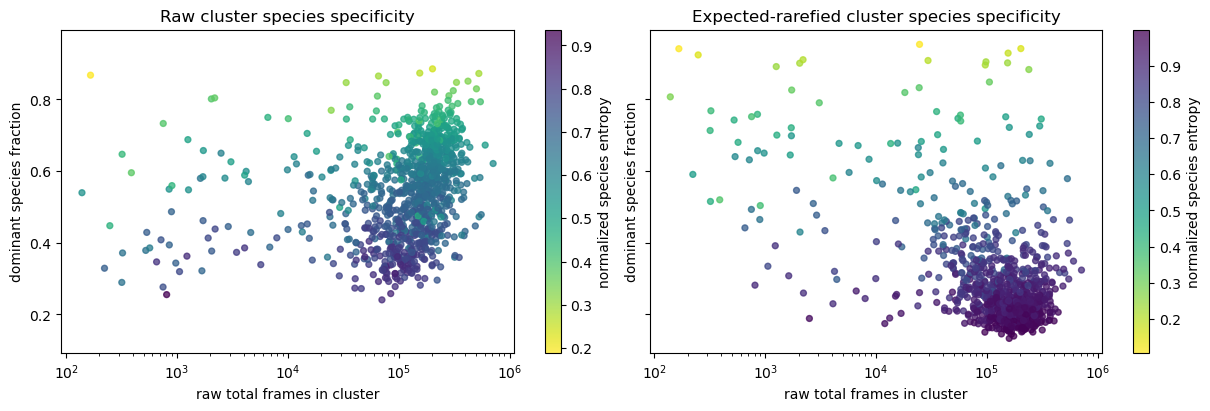

In [147]:
# 1. Purity vs occupancy, shown both raw and after equal per-species depth.
occupied = cluster_summary['total_frames'] > 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=True)
scatter_specs = [
    (
        axes[0],
        'raw_dominant_species_fraction',
        'raw_species_entropy_normalized',
        'Raw cluster species specificity',
    ),
    (
        axes[1],
        'rarefied_dominant_species_fraction',
        'rarefied_species_entropy_normalized',
        'Expected-rarefied cluster species specificity',
    ),
]
for ax, purity_col, entropy_col, title in scatter_specs:
    scatter = ax.scatter(
        cluster_summary.loc[occupied, 'total_frames'],
        cluster_summary.loc[occupied, purity_col],
        c=cluster_summary.loc[occupied, entropy_col],
        cmap='viridis_r',
        s=18,
        alpha=0.75,
    )
    ax.set_xscale('log')
    ax.set_xlabel('raw total frames in cluster')
    ax.set_ylabel('dominant species fraction')
    ax.set_title(title)
    cb = fig.colorbar(scatter, ax=ax)
    cb.set_label('normalized species entropy')
plt.show()


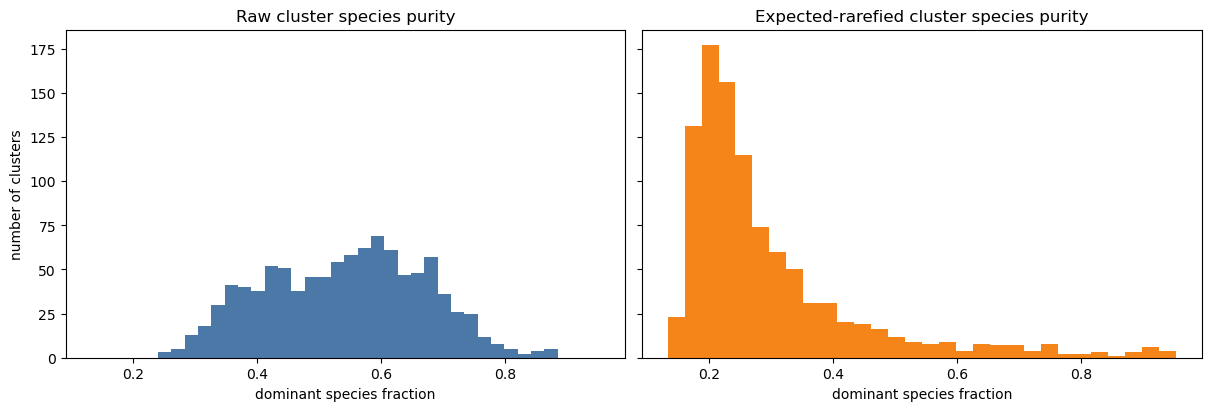

In [148]:
# 2. Histogram of species purity, shown both raw and after equal per-species depth.
occupied = cluster_summary['total_frames'] > 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=True)
axes[0].hist(
    cluster_summary.loc[occupied, 'raw_dominant_species_fraction'],
    bins=30,
    color='#4c78a8',
)
axes[0].set_xlabel('dominant species fraction')
axes[0].set_ylabel('number of clusters')
axes[0].set_title('Raw cluster species purity')

axes[1].hist(
    cluster_summary.loc[occupied, 'rarefied_dominant_species_fraction'],
    bins=30,
    color='#f58518',
)
axes[1].set_xlabel('dominant species fraction')
axes[1].set_title('Expected-rarefied cluster species purity')
plt.show()


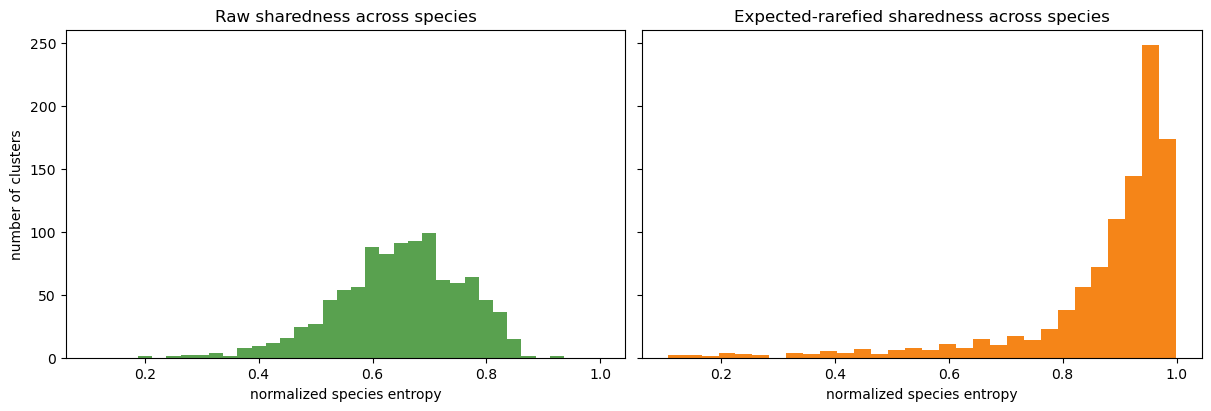

In [149]:
# 3. Entropy distribution, shown both raw and after equal per-species depth.
occupied = cluster_summary['total_frames'] > 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=True)
axes[0].hist(
    cluster_summary.loc[occupied, 'raw_species_entropy_normalized'],
    bins=30,
    color='#59a14f',
)
axes[0].set_xlabel('normalized species entropy')
axes[0].set_ylabel('number of clusters')
axes[0].set_title('Raw sharedness across species')

axes[1].hist(
    cluster_summary.loc[occupied, 'rarefied_species_entropy_normalized'],
    bins=30,
    color='#f58518',
)
axes[1].set_xlabel('normalized species entropy')
axes[1].set_title('Expected-rarefied sharedness across species')
plt.show()


## Expected Rarefied Entropy Diagnostics


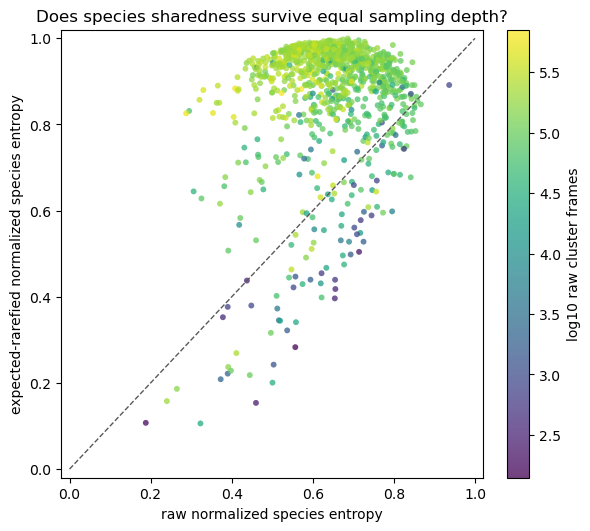

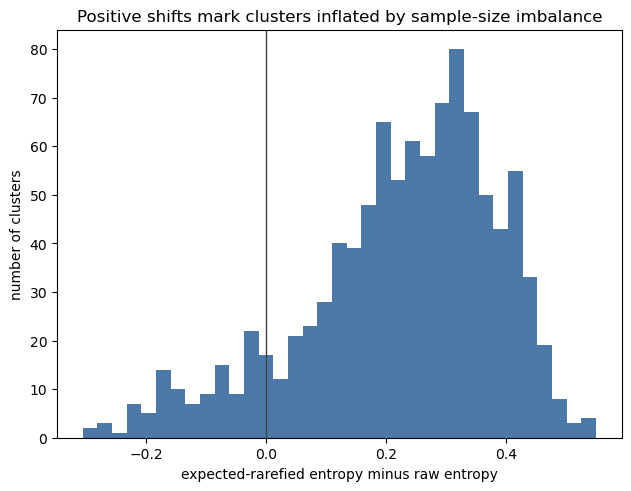

,cluster,total_frames,raw_dominant_species,raw_dominant_species_fraction,raw_species_entropy_normalized,rarefied_dominant_species,rarefied_dominant_species_fraction,rarefied_species_entropy_normalized,entropy_normalized_rarefied_minus_raw
629,629,421993,Mus_musculus,0.850827,0.330009,Mus_musculus,0.363390,0.879841,0.549831
215,215,528726,Mus_musculus,0.872268,0.287512,Mus_musculus,0.397849,0.825726,0.538214
31,31,332269,Mus_musculus,0.847371,0.320414,Mus_musculus,0.423750,0.857181,0.536767
160,160,65744,Mus_musculus,0.865128,0.295032,Mus_musculus,0.439141,0.831379,0.536348
439,439,310815,Mus_musculus,0.824223,0.365730,Mus_musculus,0.341390,0.890063,0.524333
38,38,162775,Mus_musculus,0.781969,0.436631,Mus_musculus,0.282077,0.942609,0.505978
712,712,219084,Mus_musculus,0.776442,0.443178,Mus_musculus,0.281233,0.948249,0.505070
362,362,296527,Mus_musculus,0.764059,0.452910,Mus_musculus,0.284254,0.953417,0.500507
714,714,233901,Mus_musculus,0.780215,0.433821,Mus_musculus,0.288412,0.929465,0.495644
883,883,279053,Mus_musculus,0.797236,0.414271,Mus_musculus,0.294347,0.909733,0.495462


In [150]:
rarefied_dir = OUT_DIR / 'expected_rarefied_entropy'
rarefied_dir.mkdir(parents=True, exist_ok=True)

occupied = cluster_summary['total_frames'] > 0
fig, ax = plt.subplots(figsize=(5.8, 5.2), constrained_layout=True)
scatter = ax.scatter(
    cluster_summary.loc[occupied, 'raw_species_entropy_normalized'],
    cluster_summary.loc[occupied, 'rarefied_species_entropy_normalized'],
    c=np.log10(cluster_summary.loc[occupied, 'total_frames'] + 1),
    s=18,
    cmap='viridis',
    alpha=0.75,
    linewidths=0,
)
ax.plot([0, 1], [0, 1], color='0.35', linewidth=1, linestyle='--')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('raw normalized species entropy')
ax.set_ylabel('expected-rarefied normalized species entropy')
ax.set_title('Does species sharedness survive equal sampling depth?')
fig.colorbar(scatter, ax=ax, label='log10 raw cluster frames')
fig.savefig(rarefied_dir / 'raw_vs_expected_rarefied_species_entropy.png', dpi=260)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4.8), constrained_layout=True)
ax.hist(
    cluster_summary.loc[occupied, 'entropy_normalized_rarefied_minus_raw'],
    bins=35,
    color='#4c78a8',
)
ax.axvline(0, color='0.25', linewidth=1)
ax.set_xlabel('expected-rarefied entropy minus raw entropy')
ax.set_ylabel('number of clusters')
ax.set_title('Positive shifts mark clusters inflated by sample-size imbalance')
fig.savefig(rarefied_dir / 'expected_rarefied_minus_raw_entropy_histogram.png', dpi=260)
plt.show()

largest_shifts = cluster_summary.loc[occupied].sort_values(
    'entropy_normalized_rarefied_minus_raw', ascending=False
).head(TOP_N_CLUSTERS)
largest_shifts.to_csv(rarefied_dir / 'clusters_with_largest_rarefied_entropy_increase.csv', index=False)
display(largest_shifts[[
    'cluster',
    'total_frames',
    'raw_dominant_species',
    'raw_dominant_species_fraction',
    'raw_species_entropy_normalized',
    'rarefied_dominant_species',
    'rarefied_dominant_species_fraction',
    'rarefied_species_entropy_normalized',
    'entropy_normalized_rarefied_minus_raw',
]].head(20))


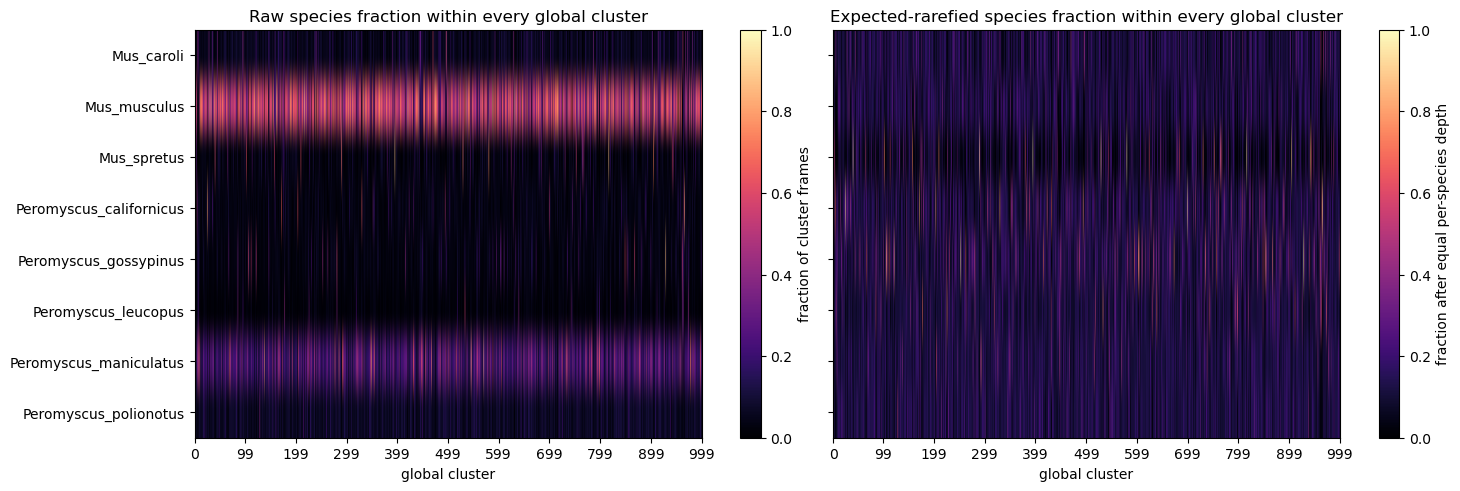

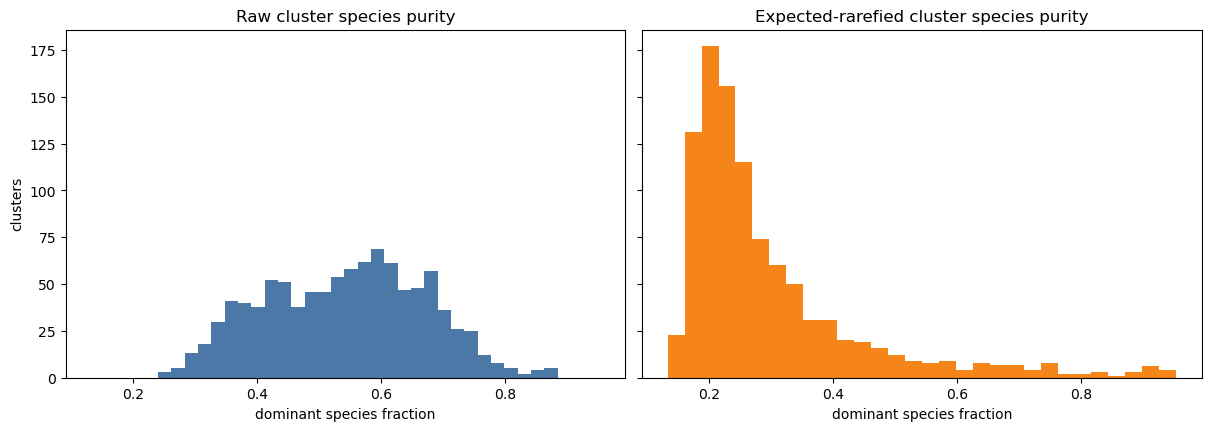

In [151]:
# Raw counts answer: among frames assigned to a cluster, which species supplied them?
# Balanced counts answer: after equalizing total frames per species, which species still use it?
occupied = cluster_summary['total_frames'] > 0
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), constrained_layout=True, sharey=True)
xticks = np.linspace(0, N_CLUSTERS - 1, 11, dtype=int)
heatmap_specs = [
    (
        axes[0],
        proportions.T,
        'Raw species fraction within every global cluster',
        'fraction of cluster frames',
        'species_fraction_heatmap_all_clusters_raw.png',
    ),
    (
        axes[1],
        rarefied_proportions.T,
        'Expected-rarefied species fraction within every global cluster',
        'fraction after equal per-species depth',
        'species_fraction_heatmap_all_clusters_expected_rarefied.png',
    ),
]
for ax, values, title, cbar_label, filename in heatmap_specs:
    image = ax.imshow(values, aspect='auto', cmap='magma', vmin=0, vmax=1)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    ax.set_xlabel('global cluster')
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=cbar_label)
axes[0].set_yticks(np.arange(len(species_names)))
axes[0].set_yticklabels(species_names)
fig.savefig(OUT_DIR / 'species_fraction_heatmap_all_clusters_raw_vs_expected_rarefied.png', dpi=240)
fig.savefig(OUT_DIR / 'species_fraction_heatmap_all_clusters.png', dpi=240)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True, sharex=True, sharey=True)
axes[0].hist(cluster_summary.loc[occupied, 'raw_dominant_species_fraction'], bins=30, color='#4c78a8')
axes[0].set(title='Raw cluster species purity', xlabel='dominant species fraction', ylabel='clusters')
axes[1].hist(cluster_summary.loc[occupied, 'rarefied_dominant_species_fraction'], bins=30, color='#f58518')
axes[1].set(title='Expected-rarefied cluster species purity', xlabel='dominant species fraction')
fig.savefig(OUT_DIR / 'cluster_species_purity_histogram_raw_vs_expected_rarefied.png', dpi=240)
fig.savefig(OUT_DIR / 'cluster_species_purity_histogram.png', dpi=240)
plt.show()


## Within-Species Allocation Across All Clusters

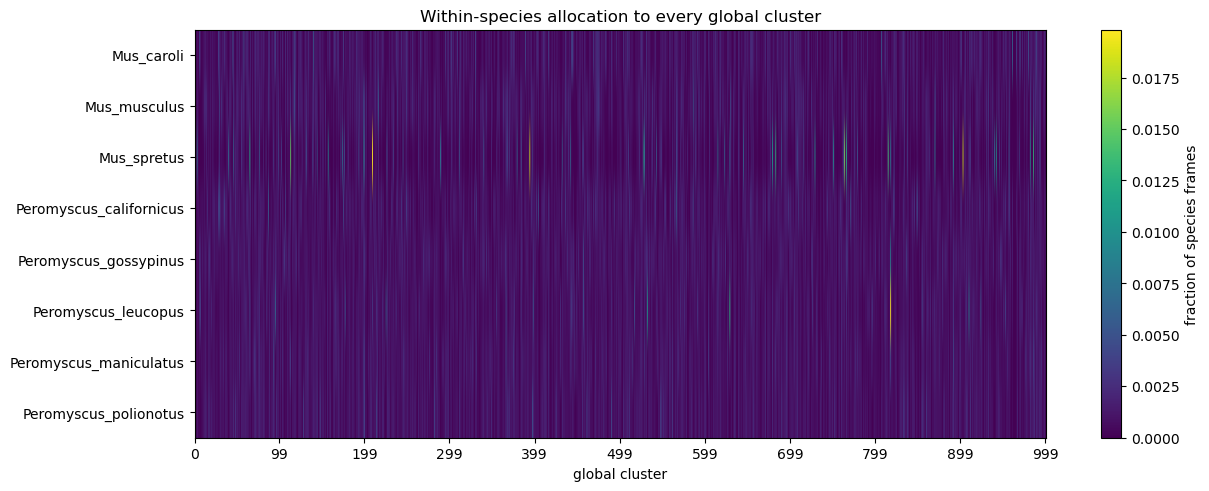

In [152]:
within_species_cluster_usage = pd.DataFrame(
    cluster_given_species.T,
    index=species_names,
    columns=[f'cluster_{i}' for i in range(N_CLUSTERS)],
)
within_species_cluster_usage.to_csv(OUT_DIR / 'within_species_cluster_usage_all_clusters.csv')

fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
image = ax.imshow(cluster_given_species.T, aspect='auto', cmap='viridis', vmin=0)
ax.set_yticks(np.arange(len(species_names)))
ax.set_yticklabels(species_names)
xticks = np.linspace(0, N_CLUSTERS - 1, 11, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
ax.set_xlabel('global cluster')
ax.set_title('Within-species allocation to every global cluster')
fig.colorbar(image, ax=ax, label='fraction of species frames')
fig.savefig(OUT_DIR / 'within_species_cluster_usage_all_clusters.png', dpi=240)
plt.show()


## Hierarchical Clustering Of Species Transfer Operators

,species,individuals,lag_frames,transition_frames,occupied_source_clusters
0,Mus_caroli,15,240,9284609,986
1,Mus_musculus,93,240,85731486,996
2,Mus_spretus,16,240,9716376,942
3,Peromyscus_californicus,23,240,5178153,969
4,Peromyscus_gossypinus,20,240,4314920,996
5,Peromyscus_leucopus,14,240,3020444,983
6,Peromyscus_maniculatus,129,240,31719144,997
7,Peromyscus_polionotus,44,240,10572799,991


,Mus_caroli,Mus_musculus,Mus_spretus,Peromyscus_californicus,Peromyscus_gossypinus,Peromyscus_leucopus,Peromyscus_maniculatus,Peromyscus_polionotus
Mus_caroli,0.000000,6.744405,11.375754,8.503707,7.383110,7.661335,6.428490,7.253801
Mus_musculus,6.744405,0.000000,10.457216,7.847711,6.011949,7.192885,4.831754,6.203433
Mus_spretus,11.375754,10.457216,0.000000,11.534628,11.150084,11.520712,10.608578,11.174230
Peromyscus_californicus,8.503707,7.847711,11.534628,0.000000,8.661461,8.838722,7.740256,8.384764
Peromyscus_gossypinus,7.383110,6.011949,11.150084,8.661461,0.000000,7.680339,5.847914,6.742303
Peromyscus_leucopus,7.661335,7.192885,11.520712,8.838722,7.680339,0.000000,7.121087,7.504234
Peromyscus_maniculatus,6.428490,4.831754,10.608578,7.740256,5.847914,7.121087,0.000000,5.997279
Peromyscus_polionotus,7.253801,6.203433,11.174230,8.384764,6.742303,7.504234,5.997279,0.000000


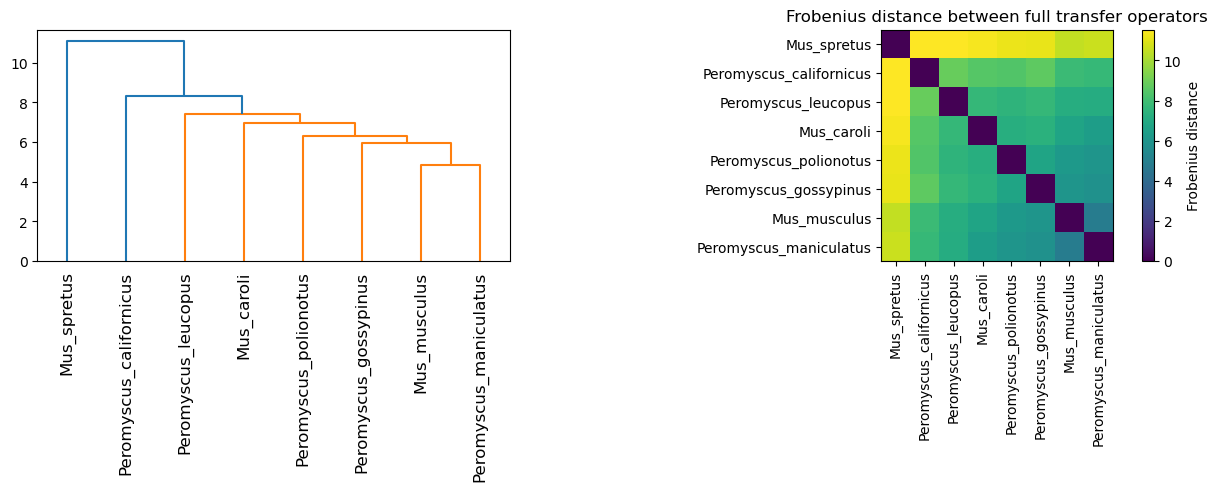

In [153]:
def infer_transfer_lag_frames():
    if SPECIES_TRANSFER_LAG_FRAMES is not None:
        return int(SPECIES_TRANSFER_LAG_FRAMES)
    params_csv = KMEANS_ROOT.parent / 'final_outputs' / 'parameters.csv'
    if params_csv.exists():
        params = pd.read_csv(params_csv)
        values = dict(zip(params['parameter'], params['value']))
        if 'lag_frames' in values:
            return int(float(values['lag_frames']))
        if {'tau_seconds', 'fs'}.issubset(values):
            return int(float(values['tau_seconds']) * float(values['fs']))
    return 240


def make_transition_matrix(state_arrays, lag, n_states):
    counts_matrix = np.zeros((n_states, n_states), dtype=np.float64)
    for states in state_arrays:
        states = np.asarray(states, dtype=np.int64)
        if len(states) <= lag:
            continue
        np.add.at(counts_matrix, (states[:-lag], states[lag:]), 1.0)
    row_sums = counts_matrix.sum(axis=1, keepdims=True)
    T = np.divide(counts_matrix, row_sums, out=np.zeros_like(counts_matrix), where=row_sums > 0)
    empty = np.flatnonzero(row_sums[:, 0] == 0)
    if len(empty):
        T[empty, empty] = 1.0
    return T, counts_matrix


transfer_dir = OUT_DIR / 'species_transfer_operators'
transfer_dir.mkdir(parents=True, exist_ok=True)
lag_frames = infer_transfer_lag_frames()
species_transfer = {}
species_transition_counts = {}
transfer_rows = []

for species in species_names:
    species_manifest = manifest.loc[manifest['species'] == species]
    state_arrays = [np.load(path, mmap_mode='r') for path in species_manifest['state_file']]
    T, transition_counts = make_transition_matrix(state_arrays, lag_frames, N_CLUSTERS)
    species_transfer[species] = T
    species_transition_counts[species] = transition_counts
    np.save(transfer_dir / f'{species}_transfer_operator_lag{lag_frames}.npy', T)
    np.save(transfer_dir / f'{species}_transition_counts_lag{lag_frames}.npy', transition_counts)
    transfer_rows.append({
        'species': species,
        'individuals': int(len(species_manifest)),
        'lag_frames': int(lag_frames),
        'transition_frames': int(transition_counts.sum()),
        'occupied_source_clusters': int((transition_counts.sum(axis=1) > 0).sum()),
    })

transfer_summary = pd.DataFrame(transfer_rows)
transfer_summary.to_csv(transfer_dir / 'species_transfer_operator_summary.csv', index=False)
display(transfer_summary)

transfer_stack = np.stack([species_transfer[species] for species in species_names], axis=0)
flat_transfer = transfer_stack.reshape(len(species_names), -1)
distance = np.sqrt(((flat_transfer[:, None, :] - flat_transfer[None, :, :]) ** 2).sum(axis=2))
distance_df = pd.DataFrame(distance, index=species_names, columns=species_names)
distance_df.to_csv(transfer_dir / 'species_transfer_operator_frobenius_distance.csv')
display(distance_df)

try:
    from scipy.cluster.hierarchy import dendrogram, linkage
    from scipy.spatial.distance import squareform

    linkage_matrix = linkage(squareform(distance, checks=False), method='average')
    np.save(transfer_dir / 'species_transfer_operator_hclust_linkage.npy', linkage_matrix)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True, gridspec_kw={'width_ratios': [1.0, 1.25]})
    dendro = dendrogram(linkage_matrix, labels=species_names, ax=axes[0], leaf_rotation=90)
    ordered_species = dendro['ivl']
    ordered_idx = [species_names.index(species) for species in ordered_species]
    im = axes[1].imshow(distance[np.ix_(ordered_idx, ordered_idx)], cmap='viridis')
    axes[1].set_xticks(np.arange(len(ordered_species)))
    axes[1].set_xticklabels(ordered_species, rotation=90)
    axes[1].set_yticks(np.arange(len(ordered_species)))
    axes[1].set_yticklabels(ordered_species)
    axes[1].set_title('Frobenius distance between full transfer operators')
    fig.colorbar(im, ax=axes[1], label='Frobenius distance')
    fig.savefig(transfer_dir / 'species_transfer_operator_hierarchical_clustering.png', dpi=240)
    plt.show()
except Exception as exc:
    ordered_species = species_names
    print(f'SciPy hierarchical clustering unavailable or failed ({exc}); saved distance matrix only.')


## Mean-Subtracted Transfer Operators

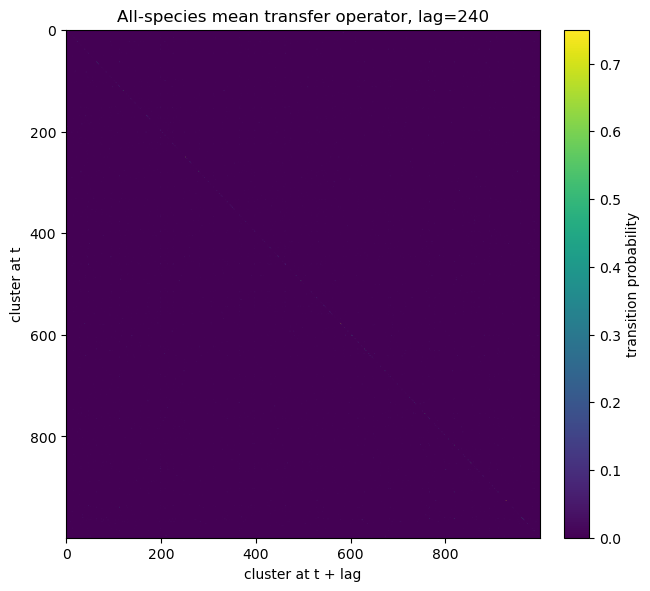

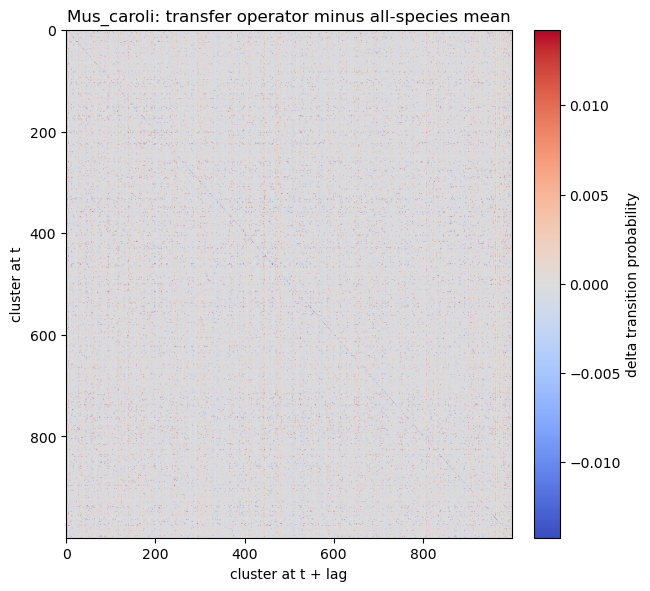

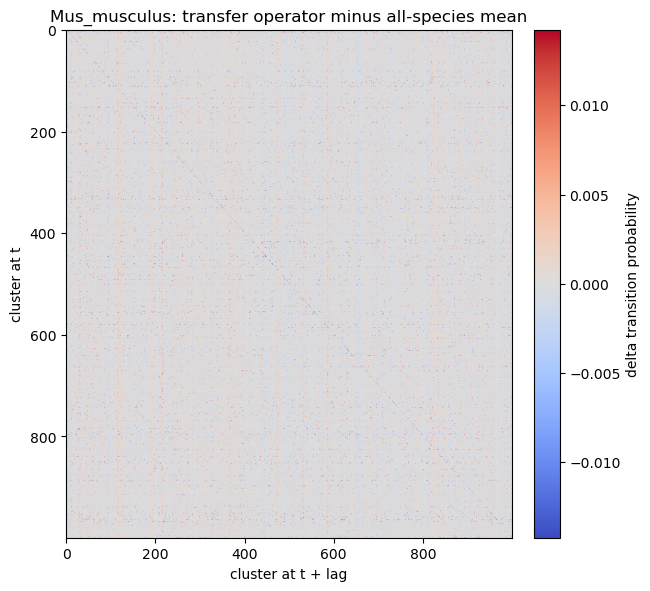

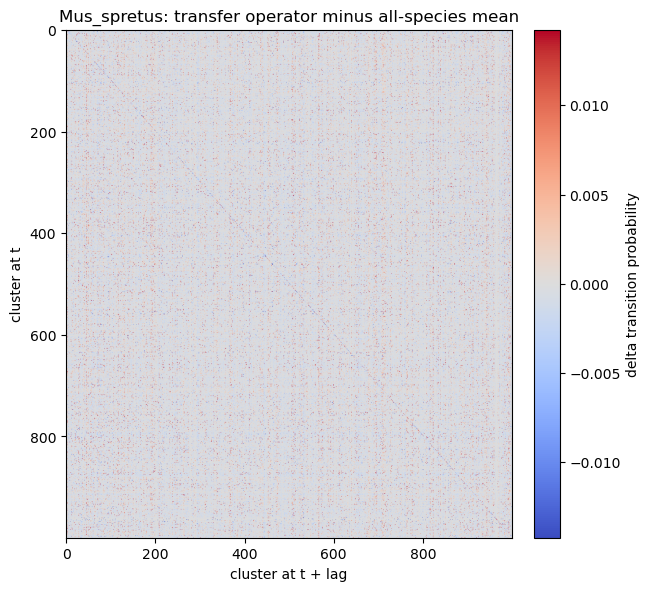

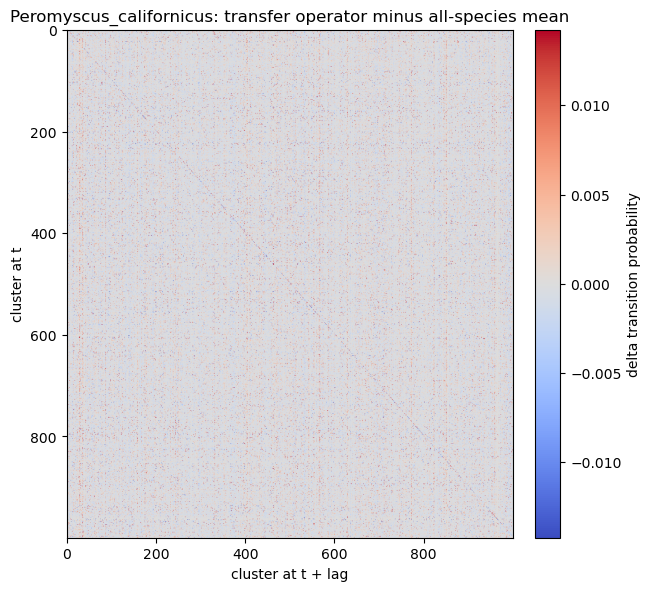

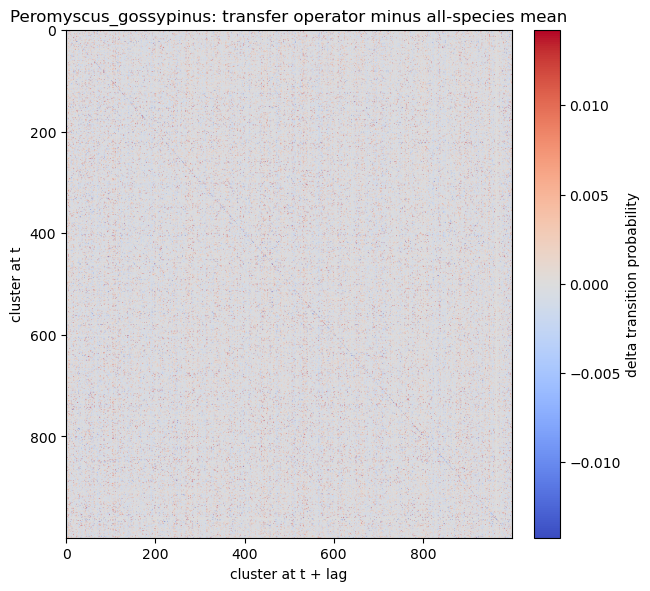

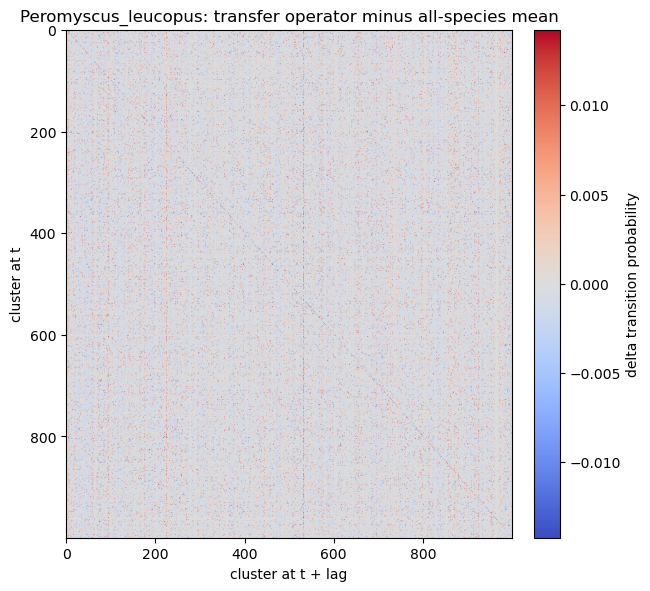

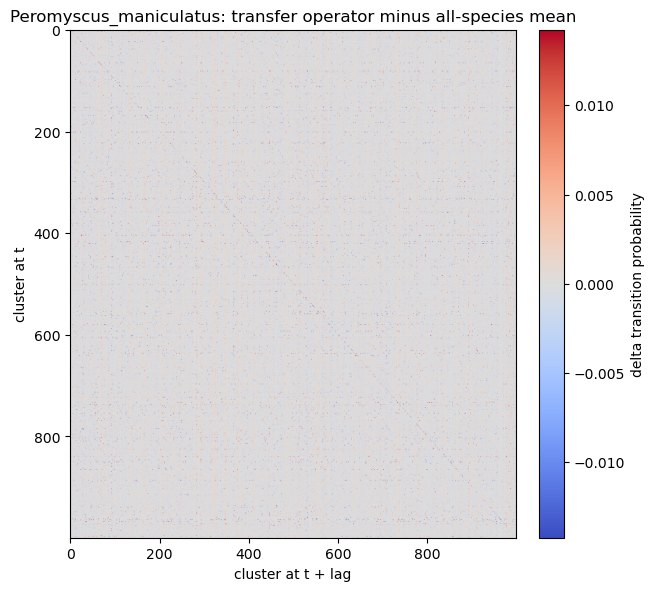

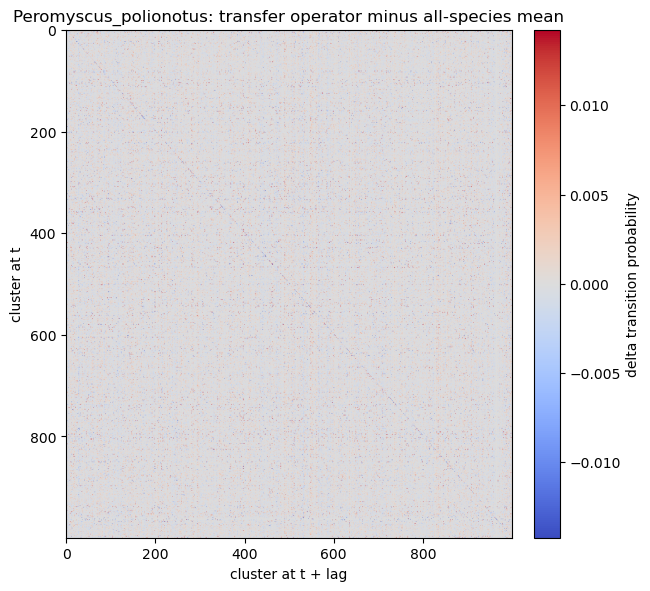

In [154]:
mean_transfer = transfer_stack.mean(axis=0)
np.save(transfer_dir / f'all_species_mean_transfer_operator_lag{lag_frames}.npy', mean_transfer)

fig, ax = plt.subplots(figsize=(6.4, 5.8), constrained_layout=True)
im = ax.imshow(mean_transfer, aspect='auto', cmap='viridis', vmin=0)
ax.set_title(f'All-species mean transfer operator, lag={lag_frames}')
ax.set_xlabel('cluster at t + lag')
ax.set_ylabel('cluster at t')
fig.colorbar(im, ax=ax, label='transition probability')
fig.savefig(transfer_dir / 'all_species_mean_transfer_operator.png', dpi=240)
plt.show()

residual_stack = transfer_stack - mean_transfer[None, :, :]
residual_limit = np.nanpercentile(np.abs(residual_stack), 99.5)
if not np.isfinite(residual_limit) or residual_limit <= 0:
    residual_limit = 1e-6

for species, residual in zip(species_names, residual_stack):
    np.save(transfer_dir / f'{species}_transfer_operator_minus_species_mean_lag{lag_frames}.npy', residual)
    fig, ax = plt.subplots(figsize=(6.4, 5.8), constrained_layout=True)
    im = ax.imshow(residual, aspect='auto', cmap='coolwarm', vmin=-residual_limit, vmax=residual_limit)
    ax.set_title(f'{species}: transfer operator minus all-species mean')
    ax.set_xlabel('cluster at t + lag')
    ax.set_ylabel('cluster at t')
    fig.colorbar(im, ax=ax, label='delta transition probability')
    fig.savefig(transfer_dir / f'{species}_transfer_operator_minus_mean.png', dpi=240)
    plt.show()


## Cluster-Space Density UMAP By Species

cluster embedding saved to /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/pca_multispecies_evensamp/global_kmeans_N1000_balanced_species/species_identity_by_cluster/cluster_space_embedding/global_cluster_embedding.csv


,cluster,x,y,embedding_method,total_frames
0,0,7.514440,5.312384,umap,224709
1,1,2.517527,4.438908,umap,1255
2,2,8.638943,4.734296,umap,228348
3,3,6.626481,6.436121,umap,135723
4,4,3.012914,3.403964,umap,8627


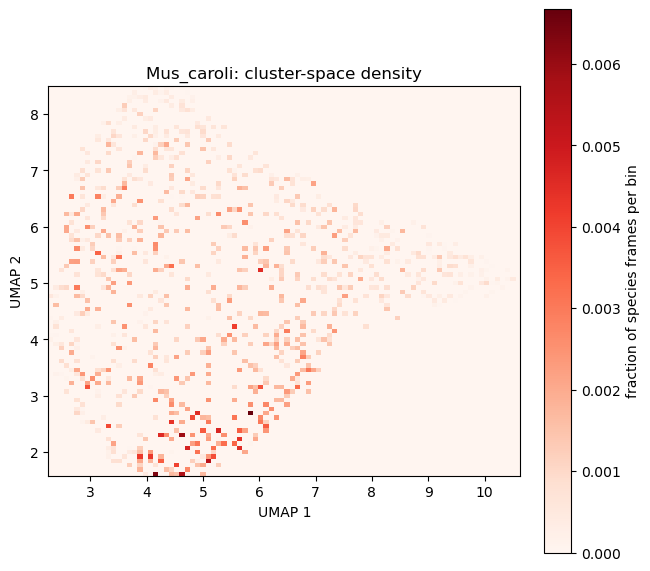

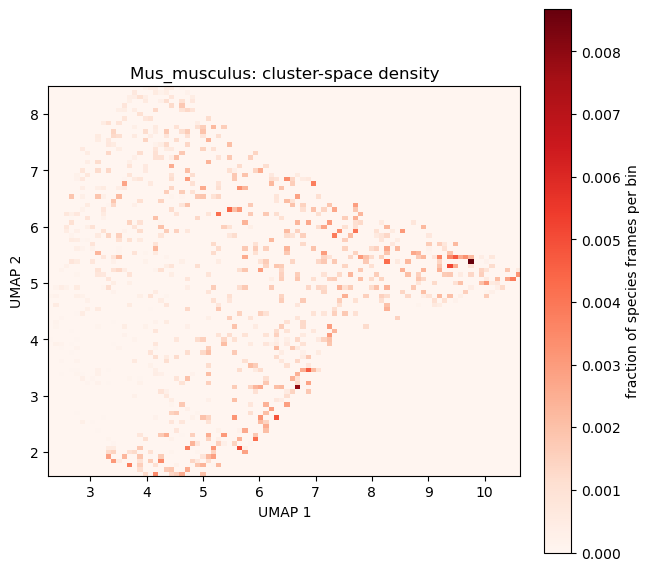

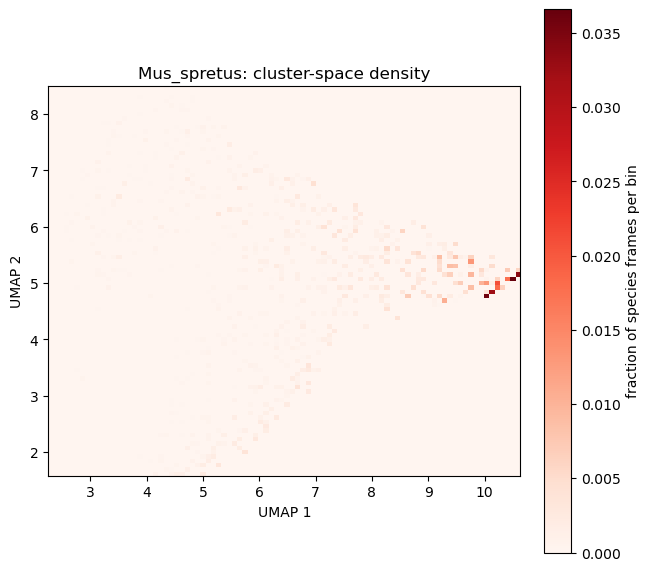

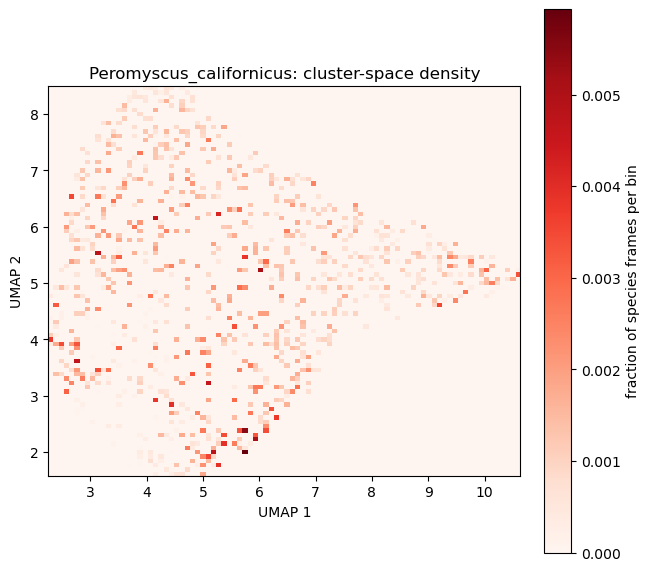

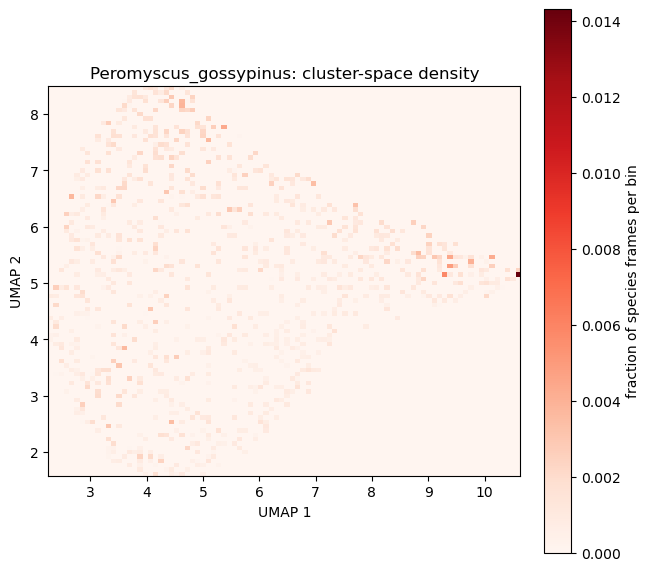

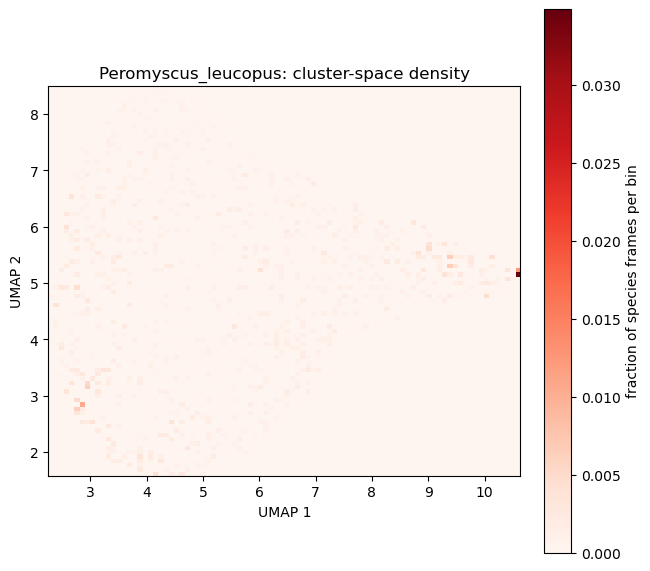

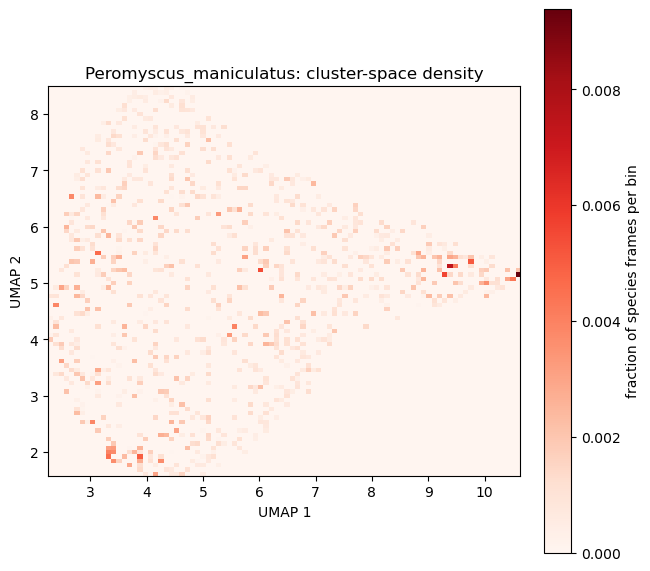

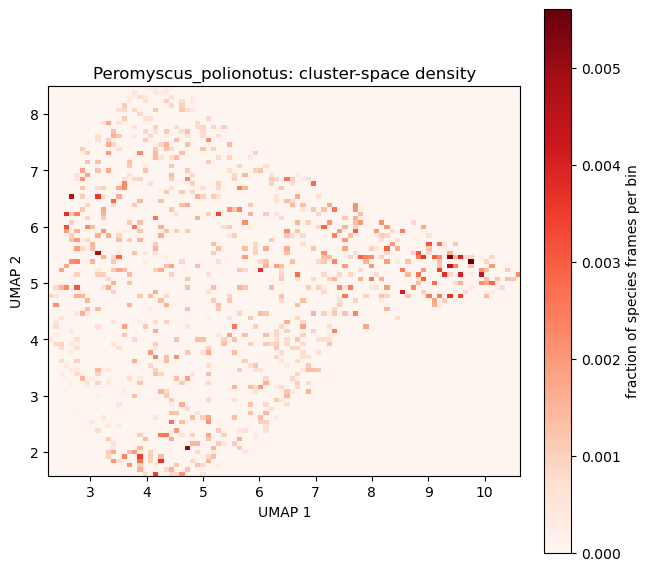

In [155]:
def load_kmeans_centers():
    result_path = KMEANS_ROOT / 'global_kmeans_result.pkl'
    if not result_path.exists():
        raise FileNotFoundError(f'Missing {result_path}; run notebook 3 first.')
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        with open(result_path, 'rb') as handle:
            result = pickle.load(handle)
    return np.asarray(result['kmeans'].cluster_centers_, dtype=np.float32)


def fit_cluster_embedding(cluster_centers):
    try:
        import umap
        reducer = umap.UMAP(
            n_components=2,
            metric='euclidean',
            n_neighbors=30,
            min_dist=0.1,
            random_state=UMAP_RANDOM_STATE,
        )
        xy = reducer.fit_transform(cluster_centers)
        method = 'umap'
    except Exception as exc:
        print(f'UMAP unavailable or failed ({exc}); using PCA fallback.')
        xy = PCA(n_components=2, random_state=UMAP_RANDOM_STATE).fit_transform(cluster_centers)
        method = 'pca_fallback'
    return np.asarray(xy, dtype=float), method


def weighted_density_grid(x, y, weights, bins=90):
    H, x_edges, y_edges = np.histogram2d(x, y, bins=bins, weights=weights)
    return H.T, x_edges, y_edges


embedding_dir = OUT_DIR / 'cluster_space_embedding'
embedding_dir.mkdir(parents=True, exist_ok=True)
cluster_centers = load_kmeans_centers()
embedding_csv = embedding_dir / 'global_cluster_embedding.csv'
if embedding_csv.exists():
    cluster_embedding = pd.read_csv(embedding_csv)
    embedding_method = str(cluster_embedding.get('embedding_method', pd.Series(['saved'])).iloc[0])
else:
    xy, embedding_method = fit_cluster_embedding(cluster_centers)
    cluster_embedding = pd.DataFrame({
        'cluster': np.arange(cluster_centers.shape[0]),
        'x': xy[:, 0],
        'y': xy[:, 1],
        'embedding_method': embedding_method,
        'total_frames': cluster_totals,
    })
    cluster_embedding.to_csv(embedding_csv, index=False)
print(f'cluster embedding saved to {embedding_csv}')
display(cluster_embedding.head())

x = cluster_embedding['x'].to_numpy(float)
y = cluster_embedding['y'].to_numpy(float)
for species in species_names:
    weights = cluster_given_species[:, species_to_col[species]]
    H, x_edges, y_edges = weighted_density_grid(x, y, weights, bins=90)
    np.save(embedding_dir / f'{species}_cluster_space_density_grid.npy', H)
    fig, ax = plt.subplots(figsize=(6.4, 5.6), constrained_layout=True)
    im = ax.imshow(
        H,
        origin='lower',
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        cmap = 'Reds',
        vmin=0,
    )
    ax.set_title(f'{species}: cluster-space density')
    ax.set_xlabel('UMAP 1' if embedding_method == 'umap' else 'PC 1')
    ax.set_ylabel('UMAP 2' if embedding_method == 'umap' else 'PC 2')
    fig.colorbar(im, ax=ax, label='fraction of species frames per bin')
    fig.savefig(embedding_dir / f'{species}_cluster_space_density_linear.png', dpi=240)
    plt.show()


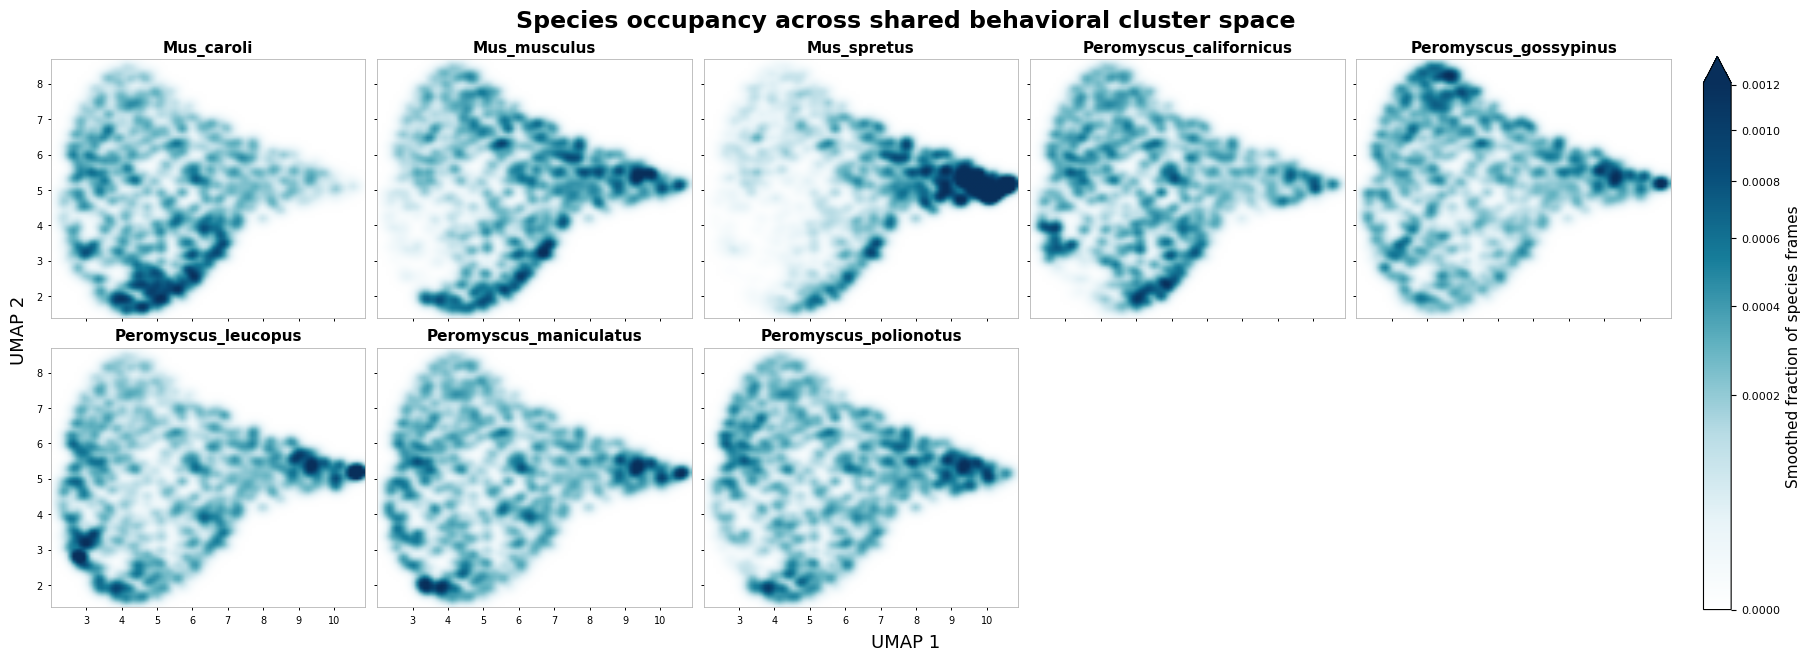

Combined density plot saved to /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/pca_multispecies_evensamp/global_kmeans_N1000_balanced_species/species_identity_by_cluster/cluster_space_embedding/all_species_cluster_space_density.png


In [156]:
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
import math


# White background with progressively richer blue/teal density colors.
density_cmap = LinearSegmentedColormap.from_list(
    'white_teal_blue',
    [
        '#ffffff',
        '#e8f4f8',
        '#b8dce5',
        '#63b3c1',
        '#167d9a',
        '#084c78',
        '#082f5b',
    ],
)


x = cluster_embedding['x'].to_numpy(float)
y = cluster_embedding['y'].to_numpy(float)

DENSITY_BINS = 90
DENSITY_SMOOTH_SIGMA = 1.25
DENSITY_VMAX_PERCENTILE = 99.5

# Explicitly define common bin edges so every species is plotted in exactly
# the same coordinate system.
x_padding = 0.03 * max(np.ptp(x), 1e-12)
y_padding = 0.03 * max(np.ptp(y), 1e-12)

x_edges = np.linspace(
    x.min() - x_padding,
    x.max() + x_padding,
    DENSITY_BINS + 1,
)
y_edges = np.linspace(
    y.min() - y_padding,
    y.max() + y_padding,
    DENSITY_BINS + 1,
)

# Calculate and save every species density grid before plotting.
species_density = {}

for species in species_names:
    weights = cluster_given_species[:, species_to_col[species]]

    H, _, _ = np.histogram2d(
        x,
        y,
        bins=[x_edges, y_edges],
        weights=weights,
    )
    H = H.T

    # Light smoothing makes the distribution easier to see without obscuring
    # the broad cluster-space structure.
    H_smooth = gaussian_filter(
        H,
        sigma=DENSITY_SMOOTH_SIGMA,
        mode='constant',
    )

    species_density[species] = H_smooth

    np.save(
        embedding_dir / f'{species}_cluster_space_density_grid.npy',
        H,
    )
    np.save(
        embedding_dir / f'{species}_cluster_space_density_grid_smoothed.npy',
        H_smooth,
    )


# Use one robust upper limit across species so colors are comparable.
positive_values = np.concatenate([
    H[H > 0]
    for H in species_density.values()
    if np.any(H > 0)
])

shared_vmax = (
    np.percentile(positive_values, DENSITY_VMAX_PERCENTILE)
    if len(positive_values)
    else 1.0
)

# PowerNorm increases visibility of moderately occupied regions while
# retaining a shared quantitative scale.
density_norm = PowerNorm(
    gamma=0.5,
    vmin=0,
    vmax=shared_vmax,
)


# Choose a compact subplot layout.
n_species = len(species_names)
n_cols = min(5, n_species)
n_rows = math.ceil(n_species / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.6 * n_cols, 3.25 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    facecolor='white',
    squeeze=False,
)

im = None

for ax, species in zip(axes.flat, species_names):
    ax.set_facecolor('white')

    im = ax.imshow(
        species_density[species],
        origin='lower',
        extent=[
            x_edges[0],
            x_edges[-1],
            y_edges[0],
            y_edges[-1],
        ],
        aspect='equal',
        interpolation='bilinear',
        cmap=density_cmap,
        norm=density_norm,
        rasterized=True,
    )

    ax.set_title(
        str(species),
        fontsize=11,
        fontweight='semibold',
        pad=5,
    )

    ax.tick_params(
        axis='both',
        labelsize=7,
        length=2.5,
        width=0.7,
    )

    # Make the panels visually lighter.
    for spine in ax.spines.values():
        spine.set_color('#b5b5b5')
        spine.set_linewidth(0.6)


# Remove unused subplot panels.
for ax in axes.flat[n_species:]:
    ax.remove()


x_label = 'UMAP 1' if embedding_method == 'umap' else 'PC 1'
y_label = 'UMAP 2' if embedding_method == 'umap' else 'PC 2'

fig.supxlabel(x_label, fontsize=13)
fig.supylabel(y_label, fontsize=13)

fig.suptitle(
    'Species occupancy across shared behavioral cluster space',
    fontsize=17,
    fontweight='bold',
)

if im is not None:
    cbar = fig.colorbar(
        im,
        ax=[ax for ax in axes.flat[:n_species]],
        location='right',
        fraction=0.025,
        pad=0.02,
        extend='max',
    )
    cbar.set_label(
        'Smoothed fraction of species frames',
        fontsize=11,
    )
    cbar.ax.tick_params(labelsize=8)

combined_path = (
    embedding_dir
    / 'all_species_cluster_space_density.png'
)

fig.savefig(
    combined_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)

plt.show()
plt.close(fig)

print(f'Combined density plot saved to {combined_path}')

## Species-Specific Phi, Arms, And Arm Enrichment

In [157]:
import gpcca_utils as gu
import pipeline as pp

ARM_EPS = 1e-12
ARM_ENRICHMENT_MIN_MATCHED_FRAMES = 1
GPCCA_TELEPORT_EPS = 1e-6


def normalize_transition_counts(transition_counts):
    transition_counts = np.asarray(transition_counts, dtype=np.float64)
    row_sums = transition_counts.sum(axis=1, keepdims=True)
    T = np.divide(
        transition_counts,
        row_sums,
        out=np.zeros_like(transition_counts),
        where=row_sums > 0,
    )
    empty = np.flatnonzero(row_sums[:, 0] == 0)
    if len(empty):
        T[empty, empty] = 1.0
    return T


def active_submatrix(T, active_clusters):
    active_clusters = np.asarray(active_clusters, dtype=int)
    if active_clusters.size < N_BASINS:
        raise ValueError(
            f'Need at least {N_BASINS} occupied clusters for GPCCA; '
            f'got {active_clusters.size}'
        )
    sub = np.asarray(T, dtype=np.float64)[np.ix_(active_clusters, active_clusters)].copy()
    row_sums = sub.sum(axis=1, keepdims=True)
    sub = np.divide(sub, row_sums, out=np.zeros_like(sub), where=row_sums > 0)
    empty = np.flatnonzero(sub.sum(axis=1) == 0)
    if len(empty):
        sub[empty, empty] = 1.0
    return sub


def regularize_transition_for_gpcca(T, eps=GPCCA_TELEPORT_EPS):
    T = np.asarray(T, dtype=np.float64)
    n = T.shape[0]
    base = np.full(n, 1.0 / max(n, 1), dtype=np.float64)
    T_reg = (1.0 - float(eps)) * T + float(eps) * base[None, :]
    T_reg /= T_reg.sum(axis=1, keepdims=True)
    return T_reg


def fit_modes_and_gpcca(T_active, *, n_basins=N_BASINS):
    fit_T = np.asarray(T_active, dtype=np.float64)
    regularization = 0.0
    try:
        pi = pp.stationary_distribution(fit_T)
        evals, evecs = pp.leading_eigvecs(fit_T, k=min(10, max(1, fit_T.shape[0] - 1)))
        gpcca = gu.run_gpcca(fit_T, M=int(n_basins), eta=pi)
    except Exception as exc:
        print(f'GPCCA failed on raw active operator ({exc}); retrying with teleport eps={GPCCA_TELEPORT_EPS:g}.')
        fit_T = regularize_transition_for_gpcca(fit_T, eps=GPCCA_TELEPORT_EPS)
        regularization = float(GPCCA_TELEPORT_EPS)
        pi = pp.stationary_distribution(fit_T)
        evals, evecs = pp.leading_eigvecs(fit_T, k=min(10, max(1, fit_T.shape[0] - 1)))
        gpcca = gu.run_gpcca(fit_T, M=int(n_basins), eta=pi)
    return fit_T, pi, evals, evecs, gpcca, regularization


def expand_active_run_arrays(T_full, active_clusters, T_fit, pi_active, evals, evecs, gpcca):
    active_clusters = np.asarray(active_clusters, dtype=int)
    n_full = int(np.asarray(T_full).shape[0])
    n_modes = int(evecs.shape[1])
    n_arms = int(gpcca['chi'].shape[1])

    full_pi = np.zeros(n_full, dtype=np.float64)
    full_pi[active_clusters] = pi_active

    full_evecs = np.zeros((n_full, n_modes), dtype=np.float64)
    full_evecs[active_clusters] = np.asarray(evecs.real, dtype=np.float64)

    phi_active = np.asarray(evecs[:, 1:4].real, dtype=np.float64)
    if phi_active.shape[1] < 3:
        phi_active = np.pad(phi_active, ((0, 0), (0, 3 - phi_active.shape[1])))
    full_phi = np.zeros((n_full, 3), dtype=np.float64)
    full_phi[active_clusters] = phi_active

    full_chi = np.zeros((n_full, n_arms), dtype=np.float64)
    full_chi[active_clusters] = np.asarray(gpcca['chi'], dtype=np.float64)

    full_assignments = np.full(n_full, -1, dtype=int)
    full_assignments[active_clusters] = np.asarray(gpcca['assignments'], dtype=int)
    geometry = gu.compute_hub_arms(full_phi, full_pi, full_chi)
    return full_pi, full_evecs, full_phi, full_chi, full_assignments, geometry


def build_slow_mode_run_from_transfer(T, *, name, active_clusters=None, n_basins=N_BASINS):
    T = np.asarray(T, dtype=np.float64)
    if active_clusters is None:
        active_clusters = np.flatnonzero(T.sum(axis=0) + T.sum(axis=1) > 0)
    active_clusters = np.asarray(active_clusters, dtype=int)
    T_active = active_submatrix(T, active_clusters)
    T_fit, pi_active, evals, evecs, gpcca, regularization = fit_modes_and_gpcca(
        T_active,
        n_basins=n_basins,
    )
    full_pi, full_evecs, full_phi, full_chi, full_assignments, geometry = expand_active_run_arrays(
        T,
        active_clusters,
        T_fit,
        pi_active,
        evals,
        evecs,
        gpcca,
    )
    return {
        'name': str(name),
        'lag': int(lag_frames),
        'n_basins': int(n_basins),
        'n_clusters': int(T.shape[0]),
        'n_fit_clusters': int(active_clusters.size),
        'active_clusters': active_clusters,
        'T': T,
        'T_active': T_active,
        'T_fit': T_fit,
        'gpcca_regularization': float(regularization),
        'pi': full_pi,
        'pi_active': pi_active,
        'evals': evals,
        'evecs': full_evecs,
        'evecs_active': evecs,
        'phi': full_phi,
        'chi': full_chi,
        'assignments': full_assignments,
        'gpcca': gpcca,
        'geometry': geometry,
    }


def save_slow_mode_run(run, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / 'phi.npy', run['phi'])
    np.save(out_dir / 'chi.npy', run['chi'])
    np.save(out_dir / 'arm_assignments.npy', run['assignments'])
    np.save(out_dir / 'stationary_distribution.npy', run['pi'])
    np.save(out_dir / 'evals.npy', run['evals'])
    np.save(out_dir / 'evecs.npy', run['evecs'])
    np.save(out_dir / 'transfer_operator.npy', run['T'])
    np.save(out_dir / 'active_clusters.npy', run['active_clusters'])
    np.save(out_dir / 'active_transfer_operator.npy', run['T_active'])
    np.save(out_dir / 'gpcca_fit_transfer_operator.npy', run['T_fit'])
    with open(out_dir / 'slow_mode_run.pkl', 'wb') as handle:
        pickle.dump(run, handle)

    table = pd.DataFrame({
        'cluster': np.arange(run['n_clusters']),
        'is_active_for_gpcca': np.isin(np.arange(run['n_clusters']), run['active_clusters']),
        'pi': run['pi'],
        'arm_assignment': run['assignments'],
    })
    for j in range(run['phi'].shape[1]):
        table[f'phi_{j + 2}'] = run['phi'][:, j]
    for arm in range(run['chi'].shape[1]):
        table[f'chi_arm_{arm + 1}'] = run['chi'][:, arm]
    table.to_csv(out_dir / 'cluster_phi_chi_arms.csv', index=False)

    arm_table = pd.DataFrame({
        'arm': np.arange(run['chi'].shape[1]),
        'pi_basin': run['gpcca']['pi_basin'],
        'hard_cluster_count': run['gpcca']['basin_counts'],
    })
    arm_table.to_csv(out_dir / 'arm_summary.csv', index=False)


arm_dir = OUT_DIR / 'slow_mode_arm_enrichment'
arm_dir.mkdir(parents=True, exist_ok=True)

species_runs = {}
for species in species_names:
    occupancy = counts[:, species_to_col[species]]
    active_clusters = np.flatnonzero(occupancy > 0)
    run = build_slow_mode_run_from_transfer(
        species_transfer[species],
        name=f'{species}_operator',
        active_clusters=active_clusters,
        n_basins=N_BASINS,
    )
    species_runs[species] = run
    save_slow_mode_run(run, arm_dir / 'species_operators' / species)

all_species_counts = np.sum(
    np.stack([species_transition_counts[species] for species in species_names], axis=0),
    axis=0,
)
all_species_T = normalize_transition_counts(all_species_counts)
all_species_active_clusters = np.flatnonzero(cluster_totals > 0)
np.save(transfer_dir / f'all_species_pooled_transition_counts_lag{lag_frames}.npy', all_species_counts)
np.save(transfer_dir / f'all_species_pooled_transfer_operator_lag{lag_frames}.npy', all_species_T)
all_species_run = build_slow_mode_run_from_transfer(
    all_species_T,
    name='all_species_operator',
    active_clusters=all_species_active_clusters,
    n_basins=N_BASINS,
)
save_slow_mode_run(all_species_run, arm_dir / 'all_species_operator')

run_summary = []
for scope, run in [('all_species_operator', all_species_run), *[(f'{species}_operator', species_runs[species]) for species in species_names]]:
    run_summary.append({
        'operator_scope': scope,
        'n_clusters': int(run['n_clusters']),
        'n_fit_clusters': int(run['n_fit_clusters']),
        'n_basins': int(run['n_basins']),
        'lag_frames': int(run['lag']),
        'gpcca_regularization': float(run['gpcca_regularization']),
        'crispness': float(run['gpcca']['crispness']),
        'pi_basin': ';'.join(f'{value:.8g}' for value in run['gpcca']['pi_basin']),
        'basin_counts': ';'.join(str(int(value)) for value in run['gpcca']['basin_counts']),
    })
run_summary = pd.DataFrame(run_summary)
run_summary.to_csv(arm_dir / 'slow_mode_run_summary.csv', index=False)
display(run_summary)


def projection_metadata_by_global_id():
    projection_result_path = KMEANS_ROOT.parent / 'projection_result.pkl'
    if not projection_result_path.exists():
        raise FileNotFoundError(f'Missing {projection_result_path}; run notebook 1 first.')
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        with open(projection_result_path, 'rb') as handle:
            projection_result = pickle.load(handle)
    return {str(meta['individual_id']): meta for meta in projection_result['metadata']}


def needed_recording_ids(metadata_by_id):
    ids = set()
    for meta in metadata_by_id.values():
        ids.update(str(value) for value in meta.get('recording_ids', []))
    return ids


def stream_moseq_recording_rows(path, keep_recording_ids):
    keep_recording_ids = {str(value) for value in keep_recording_ids}
    with open(path, newline='') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        recording_col = header.index('recording_id')
        time_cols = [i for i, name in enumerate(header) if name.startswith('t_')]
        for row in reader:
            recording_id = str(row[recording_col])
            if recording_id not in keep_recording_ids:
                continue
            values = np.asarray([
                int(float(row[i])) if row[i] not in {'', 'nan', 'NaN'} else -1
                for i in time_cols
            ], dtype=np.int16)
            yield recording_id, values


def arm_moseq_counts_for_run(run, rows_to_score, syllables_by_recording, metadata_by_id):
    weighted_rows = []
    baseline_rows = []
    join_rows = []
    chi = np.asarray(run['chi'], dtype=float)
    n_arms = chi.shape[1]

    for _, manifest_row in rows_to_score.iterrows():
        global_id = str(manifest_row['global_id'])
        source_species = str(manifest_row['species'])
        meta = metadata_by_id.get(global_id)
        if meta is None:
            join_rows.append({'global_id': global_id, 'species': source_species, 'matched_frames': 0, 'excluded_boundary_frames': 0, 'status': 'missing_projection_metadata'})
            continue

        states = np.asarray(np.load(manifest_row['state_file'], mmap_mode='r'), dtype=np.int64)
        segment_lengths = np.asarray(meta.get('segment_lengths', []), dtype=int)
        rec_ids = [str(value) for value in meta.get('recording_ids', [])]
        if len(segment_lengths) == 0 or len(rec_ids) == 0:
            segment_lengths = np.array([len(states)], dtype=int)
            rec_ids = [global_id]

        segment_ends = np.cumsum(segment_lengths)
        starts = np.r_[0, segment_ends[:-1]]
        embedding_window = max(1, int(meta.get('n_frames', len(states))) - len(states) + 1)
        frame_index = np.arange(len(states), dtype=int)
        segment_index = np.searchsorted(segment_ends, frame_index, side='right')
        valid_segment = segment_index < len(segment_ends)
        crosses = np.ones(len(states), dtype=bool)
        crosses[valid_segment] = frame_index[valid_segment] + embedding_window - 1 >= segment_ends[segment_index[valid_segment]]

        matched_frames = 0
        missing_recordings = 0
        for segment, recording_id in enumerate(rec_ids):
            syllable_sequence = syllables_by_recording.get(recording_id)
            if syllable_sequence is None:
                missing_recordings += 1
                continue
            mask = valid_segment & (segment_index == segment) & ~crosses
            if not mask.any():
                continue
            local_states = states[mask]
            raw_frames = frame_index[mask] - starts[segment]
            valid = (
                (local_states >= 0)
                & (local_states < chi.shape[0])
                & (raw_frames >= 0)
                & (raw_frames < len(syllable_sequence))
            )
            if not np.any(valid):
                continue
            local_states = local_states[valid]
            syllables = np.asarray(syllable_sequence[raw_frames[valid]], dtype=np.int64)
            valid_syllables = syllables >= 0
            if not np.any(valid_syllables):
                continue
            local_states = local_states[valid_syllables]
            syllables = syllables[valid_syllables]
            memberships = chi[local_states]
            matched_frames += int(len(syllables))

            unique, inverse = np.unique(syllables, return_inverse=True)
            baseline_counts = np.bincount(inverse, minlength=len(unique))
            baseline_rows.extend({
                'species': source_species,
                'moseq_cluster': int(syllable),
                'matched_frames': int(count),
            } for syllable, count in zip(unique, baseline_counts))

            for arm in range(n_arms):
                arm_counts = np.bincount(
                    inverse,
                    weights=memberships[:, arm],
                    minlength=len(unique),
                )
                weighted_rows.extend({
                    'species': source_species,
                    'arm': int(arm),
                    'moseq_cluster': int(syllable),
                    'weighted_frames': float(value),
                } for syllable, value in zip(unique, arm_counts) if value > 0)

        join_rows.append({
            'global_id': global_id,
            'species': source_species,
            'matched_frames': int(matched_frames),
            'excluded_boundary_frames': int(crosses.sum()),
            'missing_recordings': int(missing_recordings),
            'embedding_window': int(embedding_window),
            'status': 'ok' if matched_frames else 'no_matched_frames',
        })

    weighted = pd.DataFrame(weighted_rows)
    baseline = pd.DataFrame(baseline_rows)
    join_stats = pd.DataFrame(join_rows)
    if weighted.empty or baseline.empty:
        return weighted, baseline, pd.DataFrame(), join_stats

    weighted = weighted.groupby(['species', 'arm', 'moseq_cluster'], as_index=False)['weighted_frames'].sum()
    baseline = baseline.groupby(['species', 'moseq_cluster'], as_index=False)['matched_frames'].sum()
    species_totals = baseline.groupby('species')['matched_frames'].sum().rename('species_matched_frames')
    arm_totals = weighted.groupby(['species', 'arm'])['weighted_frames'].sum().rename('arm_weighted_frames_total')
    enriched = weighted.join(arm_totals, on=['species', 'arm'])
    enriched = enriched.merge(baseline, on=['species', 'moseq_cluster'], how='left')
    enriched = enriched.join(species_totals, on='species')
    enriched['p_moseq_given_arm_species'] = enriched['weighted_frames'] / enriched['arm_weighted_frames_total'].clip(lower=ARM_EPS)
    enriched['p_moseq_given_species'] = enriched['matched_frames'] / enriched['species_matched_frames'].clip(lower=1)
    enriched['probability_delta'] = enriched['p_moseq_given_arm_species'] - enriched['p_moseq_given_species']
    enriched['log2_enrichment'] = np.log2(
        (enriched['p_moseq_given_arm_species'] + ARM_EPS)
        / (enriched['p_moseq_given_species'] + ARM_EPS)
    )
    return weighted, baseline, enriched, join_stats


if not MOSEQ_TIMESERIES_CSV.exists():
    raise FileNotFoundError(f'Missing MoSeq timeseries CSV: {MOSEQ_TIMESERIES_CSV}')

metadata_by_id = projection_metadata_by_global_id()
record_ids = needed_recording_ids(metadata_by_id)
syllables_by_recording = dict(stream_moseq_recording_rows(MOSEQ_TIMESERIES_CSV, record_ids))
print(f'loaded MoSeq syllable rows for {len(syllables_by_recording)}/{len(record_ids)} recordings')

def save_arm_enrichment_outputs(operator_name, run, rows_to_score):
    out = arm_dir / 'arm_moseq_enrichment' / operator_name
    out.mkdir(parents=True, exist_ok=True)
    weighted, baseline, enriched, join_stats = arm_moseq_counts_for_run(
        run,
        rows_to_score,
        syllables_by_recording,
        metadata_by_id,
    )
    weighted.to_csv(out / 'arm_moseq_weighted_counts.csv', index=False)
    baseline.to_csv(out / 'species_moseq_baseline_counts.csv', index=False)
    enriched.to_csv(out / 'arm_moseq_enrichment.csv', index=False)
    join_stats.to_csv(out / 'moseq_join_stats.csv', index=False)
    return enriched, join_stats

all_enrichment = []
all_join_stats = []
for species in species_names:
    rows_to_score = manifest.loc[manifest['species'] == species].copy()
    enriched, join_stats = save_arm_enrichment_outputs(
        f'species_operator/{species}',
        species_runs[species],
        rows_to_score,
    )
    if not enriched.empty:
        enriched = enriched.assign(operator_scope='species_operator', operator_species=species)
        all_enrichment.append(enriched)
    if not join_stats.empty:
        join_stats = join_stats.assign(operator_scope='species_operator', operator_species=species)
        all_join_stats.append(join_stats)

enriched, join_stats = save_arm_enrichment_outputs(
    'all_species_operator',
    all_species_run,
    manifest.copy(),
)
if not enriched.empty:
    enriched = enriched.assign(operator_scope='all_species_operator', operator_species='all_species')
    all_enrichment.append(enriched)
if not join_stats.empty:
    join_stats = join_stats.assign(operator_scope='all_species_operator', operator_species='all_species')
    all_join_stats.append(join_stats)

combined_enrichment = pd.concat(all_enrichment, ignore_index=True) if all_enrichment else pd.DataFrame()
combined_join_stats = pd.concat(all_join_stats, ignore_index=True) if all_join_stats else pd.DataFrame()
combined_enrichment.to_csv(arm_dir / 'combined_arm_moseq_enrichment.csv', index=False)
combined_join_stats.to_csv(arm_dir / 'combined_moseq_join_stats.csv', index=False)

display(combined_join_stats.groupby(['operator_scope', 'operator_species', 'species'])['matched_frames'].sum().reset_index().head(20))
display(combined_enrichment.head())


/opt/anaconda3/lib/python3.10/site-packages/pygpcca/_gpcca.py:353: UserWarning: The condition number 649713.1968793627 of the matrix of start simplex vertices X[index, :] is quite high for safe inversion (to build the initial rotation matrix).
  warnings.warn(


,operator_scope,n_clusters,n_fit_clusters,n_basins,lag_frames,gpcca_regularization,crispness,pi_basin,basin_counts
0,all_species_operator,1000,1000,4,240,0.0,0.415316,0.74684983;0.20831408;0.033943817;0.01089228,916;64;14;6
1,Mus_caroli_operator,1000,986,4,240,0.0,0.292959,0.62872852;0.32977204;0.036022438;0.0054770019,843;107;31;5
2,Mus_musculus_operator,1000,997,4,240,0.0,0.372258,0.72817682;0.27182318;1.5066073e-10;7.0106048e-12,1;922;72;2
3,Mus_spretus_operator,1000,942,4,240,0.0,0.428516,0.49241029;0.29587598;0.15825778;0.053455946,871;53;12;6
4,Peromyscus_californicus_operator,1000,969,4,240,0.0,0.345234,0.71624216;0.20274805;0.07039287;0.010616912,905;8;49;7
5,Peromyscus_gossypinus_operator,1000,996,4,240,0.0,0.348534,0.81861143;0.13018462;0.036250607;0.01495334,933;57;6;0
6,Peromyscus_leucopus_operator,1000,983,4,240,0.0,0.457261,0.73095448;0.19654664;0.052401093;0.020097786,894;82;6;1
7,Peromyscus_maniculatus_operator,1000,997,4,240,0.0,0.444867,0.84097833;0.14603068;0.010806516;0.0021844754,922;69;4;2
8,Peromyscus_polionotus_operator,1000,991,4,240,0.0,0.327764,0.69984376;0.2487736;0.037293389;0.01408925,890;92;2;7


loaded MoSeq syllable rows for 739/739 recordings


,operator_scope,operator_species,species,matched_frames
0,all_species_operator,all_species,Mus_caroli,9287785
1,all_species_operator,all_species,Mus_musculus,85749646
2,all_species_operator,all_species,Mus_spretus,9719775
3,all_species_operator,all_species,Peromyscus_californicus,5183664
4,all_species_operator,all_species,Peromyscus_gossypinus,4319720
5,all_species_operator,all_species,Peromyscus_leucopus,3023804
6,all_species_operator,all_species,Peromyscus_maniculatus,31749942
7,all_species_operator,all_species,Peromyscus_polionotus,10583314
8,species_operator,Mus_caroli,Mus_caroli,9287785
9,species_operator,Mus_musculus,Mus_musculus,85749646


,species,arm,moseq_cluster,weighted_frames,arm_weighted_frames_total,matched_frames,species_matched_frames,p_moseq_given_arm_species,p_moseq_given_species,probability_delta,log2_enrichment,operator_scope,operator_species
0,Mus_caroli,0,0,136444.878178,5.839802e+06,209748,9287785,0.023365,0.022583,0.000781,0.049076,species_operator,Mus_caroli
1,Mus_caroli,0,1,368383.752497,5.839802e+06,575984,9287785,0.063082,0.062015,0.001066,0.024596,species_operator,Mus_caroli
2,Mus_caroli,0,2,57963.370583,5.839802e+06,90565,9287785,0.009926,0.009751,0.000175,0.025603,species_operator,Mus_caroli
3,Mus_caroli,0,3,73733.937969,5.839802e+06,107664,9287785,0.012626,0.011592,0.001034,0.123280,species_operator,Mus_caroli
4,Mus_caroli,0,4,164155.941800,5.839802e+06,246527,9287785,0.028110,0.026543,0.001567,0.082736,species_operator,Mus_caroli


## Occupancy-Threshold Species-Specific Transfer Operators

This section rebuilds species-specific slow-mode operators after absorbing minimally occupied / low-transition-support clusters into nearest neighbors. The per-species macro-cluster counts come from notebook 05's full nearest-neighbor absorption diagnostic, using the most compressed operator that stayed within the eigenspectrum/entropy tolerances.

Outputs are written to `slow_mode_arm_enrichment_occupancy_threshold`, leaving the original species-specific operators untouched.

In [ ]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cosine

OCCUPANCY_THRESHOLD_DIR = OUT_DIR / 'slow_mode_arm_enrichment_occupancy_threshold'
OCCUPANCY_THRESHOLD_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF_ARM_COLORS = np.array([
    '#E68613',  # arm 1: orange
    '#C44E52',  # arm 2: red
    '#4C78A8',  # arm 3: blue
    '#54A24B',  # arm 4: green
])
CUTOFF_ARM_COLOR_LABELS = {
    0: 'orange',
    1: 'red',
    2: 'blue',
    3: 'green',
}


def cutoff_arm_color_array(n_arms=N_BASINS):
    if int(n_arms) <= len(CUTOFF_ARM_COLORS):
        return CUTOFF_ARM_COLORS[:int(n_arms)]
    extra = plt.cm.tab20(np.linspace(0, 1, int(n_arms) - len(CUTOFF_ARM_COLORS)))
    return np.concatenate([CUTOFF_ARM_COLORS, extra])


ABSORPTION_DIAGNOSTIC_DIR = OUT_DIR / 'species_specific_transfer_operator_diagnostics' / 'full_nearest_neighbor_absorption_by_outgoing'
ABSORPTION_RECOMMENDATIONS_CSV = ABSORPTION_DIAGNOSTIC_DIR / 'full_absorption_cutoff_recommendations.csv'
if not ABSORPTION_RECOMMENDATIONS_CSV.exists():
    raise FileNotFoundError(
        f'Missing {ABSORPTION_RECOMMENDATIONS_CSV}. Run notebook 05 through the full absorption section first.'
    )

cutoff_recommendations = pd.read_csv(ABSORPTION_RECOMMENDATIONS_CSV)
cutoff_recommendations = cutoff_recommendations.loc[cutoff_recommendations['species'].isin(species_names)].copy()
if cutoff_recommendations.empty:
    raise ValueError('No species cutoff recommendations matched the current manifest species.')

species_to_target_macro_clusters = dict(zip(
    cutoff_recommendations['species'].astype(str),
    cutoff_recommendations['recommended_n_macro_clusters'].astype(int),
))

print('Cutoff-aware macro-cluster targets from notebook 05:')
display(cutoff_recommendations.sort_values('species'))

plot_warning_rows = []


def record_plot_warning(section, name, exc):
    plot_warning_rows.append({
        'section': str(section),
        'name': str(name),
        'error_type': type(exc).__name__,
        'message': str(exc),
    })
    print(f'[plot skipped] {section} / {name}: {type(exc).__name__}: {exc}')


def save_plot_warning_log():
    if plot_warning_rows:
        pd.DataFrame(plot_warning_rows).to_csv(OCCUPANCY_THRESHOLD_DIR / 'plot_warnings.csv', index=False)


In [ ]:
def cutoff_load_cluster_centers():
    result_path = KMEANS_ROOT / 'global_kmeans_result.pkl'
    if not result_path.exists():
        raise FileNotFoundError(f'Missing {result_path}; run notebook 03 first.')
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        with open(result_path, 'rb') as handle:
            result = pickle.load(handle)
    return np.asarray(result['kmeans'].cluster_centers_, dtype=np.float32)


cutoff_cluster_centers = cutoff_load_cluster_centers()


def cutoff_nearest_active_cluster(cluster_id, active_clusters, centers):
    active_clusters = np.asarray(active_clusters, dtype=int)
    candidates = active_clusters[active_clusters != int(cluster_id)]
    if candidates.size == 0:
        return None
    delta = centers[candidates] - centers[int(cluster_id)]
    distances = np.einsum('ij,ij->i', delta, delta)
    return int(candidates[int(np.argmin(distances))])


def cutoff_contiguous_mapping(old_to_rep):
    reps = np.array(sorted(np.unique(old_to_rep)), dtype=int)
    rep_to_idx = {int(rep): i for i, rep in enumerate(reps)}
    old_to_macro = np.array([rep_to_idx[int(rep)] for rep in old_to_rep], dtype=int)
    return old_to_macro, reps


def cutoff_aggregate_counts(counts_matrix, old_to_macro, n_macro):
    counts_matrix = np.asarray(counts_matrix, dtype=np.float64)
    row_idx, col_idx = np.nonzero(counts_matrix)
    grouped = np.zeros((int(n_macro), int(n_macro)), dtype=np.float64)
    np.add.at(grouped, (old_to_macro[row_idx], old_to_macro[col_idx]), counts_matrix[row_idx, col_idx])
    return grouped


def cutoff_absorption_mapping_for_species(species, target_macro_clusters):
    counts_matrix = np.asarray(species_transition_counts[species], dtype=np.float64)
    support = counts_matrix.sum(axis=1).astype(np.float64)
    outgoing = counts_matrix.sum(axis=1)
    active_clusters = np.flatnonzero(outgoing > 0)
    if active_clusters.size == 0:
        raise ValueError(f'{species} has no clusters with outgoing transitions.')

    target_macro_clusters = max(int(N_BASINS), min(int(target_macro_clusters), int(active_clusters.size)))
    old_to_rep = np.arange(N_CLUSTERS, dtype=int)

    zero_outgoing = np.setdiff1d(np.arange(N_CLUSTERS, dtype=int), active_clusters, assume_unique=True)
    for cluster in zero_outgoing:
        neighbor = cutoff_nearest_active_cluster(cluster, active_clusters, cutoff_cluster_centers)
        if neighbor is not None:
            old_to_rep[cluster] = neighbor
            support[neighbor] += support[cluster]
            support[cluster] = 0.0

    while active_clusters.size > target_macro_clusters:
        active_support = support[active_clusters]
        merge_source = int(active_clusters[int(np.argmin(active_support))])
        merge_target = cutoff_nearest_active_cluster(merge_source, active_clusters, cutoff_cluster_centers)
        if merge_target is None:
            break
        old_to_rep[old_to_rep == merge_source] = merge_target
        support[merge_target] += support[merge_source]
        support[merge_source] = 0.0
        active_clusters = active_clusters[active_clusters != merge_source]

    old_to_macro, macro_representative_clusters = cutoff_contiguous_mapping(old_to_rep)
    return old_to_macro, macro_representative_clusters


def cutoff_grouped_operator_for_species(species, target_macro_clusters):
    counts_matrix = np.asarray(species_transition_counts[species], dtype=np.float64)
    old_to_macro, macro_representatives = cutoff_absorption_mapping_for_species(species, target_macro_clusters)
    grouped_counts = cutoff_aggregate_counts(counts_matrix, old_to_macro, len(macro_representatives))
    row_sums = grouped_counts.sum(axis=1, keepdims=True)
    active_macros = np.flatnonzero(row_sums[:, 0] > 0)
    if active_macros.size != grouped_counts.shape[0]:
        grouped_counts = grouped_counts[np.ix_(active_macros, active_macros)]
        macro_representatives = macro_representatives[active_macros]
        remap = np.full(old_to_macro.max() + 1, -1, dtype=int)
        remap[active_macros] = np.arange(active_macros.size, dtype=int)
        old_to_macro = remap[old_to_macro]
        row_sums = grouped_counts.sum(axis=1, keepdims=True)
    if np.any(row_sums[:, 0] <= 0):
        raise ValueError(f'{species} grouped operator has empty rows after absorption.')
    T_macro = grouped_counts / row_sums
    return T_macro, grouped_counts, old_to_macro, macro_representatives


def cutoff_expand_macro_run_to_global_clusters(run, old_to_macro):
    old_to_macro = np.asarray(old_to_macro, dtype=int)
    expanded = dict(run)
    expanded['macro_run'] = run
    expanded['old_to_macro'] = old_to_macro
    expanded['phi'] = np.asarray(run['phi'])[old_to_macro]
    expanded['chi'] = np.asarray(run['chi'])[old_to_macro]
    macro_pi = np.asarray(run['pi'], dtype=float)
    macro_member_counts = np.bincount(old_to_macro, minlength=len(macro_pi)).clip(min=1)
    expanded['pi'] = macro_pi[old_to_macro] / macro_member_counts[old_to_macro]
    expanded['assignments'] = np.asarray(run['assignments'])[old_to_macro]
    expanded['n_clusters'] = int(N_CLUSTERS)
    expanded['n_macro_clusters'] = int(run['n_clusters'])
    return expanded

In [ ]:
cutoff_species_runs = {}
cutoff_species_macro_runs = {}
cutoff_species_mappings = {}
cutoff_rows = []

for species in species_names:
    target_macro_clusters = species_to_target_macro_clusters.get(species)
    if target_macro_clusters is None:
        raise KeyError(f'Missing cutoff recommendation for {species}')
    T_macro, grouped_counts, old_to_macro, macro_reps = cutoff_grouped_operator_for_species(
        species,
        target_macro_clusters,
    )
    macro_run = build_slow_mode_run_from_transfer(
        T_macro,
        name=f'{species}_occupancy_threshold_operator',
        active_clusters=np.arange(T_macro.shape[0], dtype=int),
        n_basins=N_BASINS,
    )
    expanded_run = cutoff_expand_macro_run_to_global_clusters(macro_run, old_to_macro)
    expanded_run['name'] = f'{species}_occupancy_threshold_operator_expanded_to_global_clusters'

    out = OCCUPANCY_THRESHOLD_DIR / 'species_operators' / species
    out.mkdir(parents=True, exist_ok=True)
    save_slow_mode_run(macro_run, out / 'macro_operator')
    np.save(out / 'macro_transition_counts.npy', grouped_counts)
    np.save(out / 'global_cluster_to_macro_cluster.npy', old_to_macro)
    np.save(out / 'macro_representative_global_clusters.npy', macro_reps)
    np.save(out / 'expanded_global_phi.npy', expanded_run['phi'])
    np.save(out / 'expanded_global_chi.npy', expanded_run['chi'])
    np.save(out / 'expanded_global_arm_assignments.npy', expanded_run['assignments'])

    cutoff_species_macro_runs[species] = macro_run
    cutoff_species_runs[species] = expanded_run
    cutoff_species_mappings[species] = old_to_macro
    cutoff_rows.append({
        'species': species,
        'target_macro_clusters': int(target_macro_clusters),
        'actual_macro_clusters': int(T_macro.shape[0]),
        'n_basins': int(N_BASINS),
        'lag_frames': int(lag_frames),
        'crispness': float(macro_run['gpcca']['crispness']),
        'pi_basin': ';'.join(f'{value:.8g}' for value in macro_run['gpcca']['pi_basin']),
        'basin_counts': ';'.join(str(int(value)) for value in macro_run['gpcca']['basin_counts']),
    })

cutoff_run_summary = pd.DataFrame(cutoff_rows)
cutoff_run_summary.to_csv(OCCUPANCY_THRESHOLD_DIR / 'occupancy_threshold_species_operator_summary.csv', index=False)
display(cutoff_run_summary)

### Individual Coverage Per Cluster

For each species and macro-cluster, count how many individuals ever visit that macro-cluster. The PPT plot ranks macro-clusters by individual coverage within species.

In [ ]:
coverage_rows = []
for species in species_names:
    species_manifest = manifest.loc[manifest['species'].astype(str) == str(species)].copy()
    old_to_macro = cutoff_species_mappings[species]
    n_macro = int(old_to_macro.max() + 1)
    individual_counts = np.zeros(n_macro, dtype=int)
    frame_counts = np.zeros(n_macro, dtype=np.int64)

    for row in species_manifest.itertuples(index=False):
        states = np.asarray(np.load(row.state_file, mmap_mode='r'), dtype=np.int64)
        valid = (states >= 0) & (states < N_CLUSTERS)
        macro_states = old_to_macro[states[valid]]
        visited = np.unique(macro_states)
        individual_counts[visited] += 1
        frame_counts += np.bincount(macro_states, minlength=n_macro)

    for macro_cluster in range(n_macro):
        coverage_rows.append({
            'species': species,
            'macro_cluster': int(macro_cluster),
            'n_individuals_in_cluster': int(individual_counts[macro_cluster]),
            'n_species_individuals': int(len(species_manifest)),
            'fraction_individuals_in_cluster': float(individual_counts[macro_cluster] / max(len(species_manifest), 1)),
            'n_frames': int(frame_counts[macro_cluster]),
            'arm_assignment': int(cutoff_species_macro_runs[species]['assignments'][macro_cluster]),
        })

cluster_individual_coverage = pd.DataFrame(coverage_rows)
cluster_individual_coverage.to_csv(OCCUPANCY_THRESHOLD_DIR / 'macro_cluster_individual_coverage_by_species.csv', index=False)

def plot_cluster_individual_coverage_ppt():
    fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), constrained_layout=True, sharey=True)
    axes = axes.ravel()
    arm_colors = cutoff_arm_color_array(N_BASINS)
    for ax, species in zip(axes, species_names):
        df = cluster_individual_coverage.loc[cluster_individual_coverage['species'] == species].copy()
        df = df.sort_values('n_individuals_in_cluster', ascending=False).reset_index(drop=True)
        colors = [arm_colors[int(arm) % len(arm_colors)] for arm in df['arm_assignment']]
        ax.bar(np.arange(len(df)), df['n_individuals_in_cluster'], color=colors, width=1.0, linewidth=0)
        ax.set_title(species.replace('_', ' '), fontsize=10, fontweight='bold')
        ax.set_xlabel('macro-clusters ranked by individual coverage')
        ax.set_ylabel('individuals')
        ax.set_ylim(0, max(cluster_individual_coverage['n_species_individuals']) + 2)
    for ax in axes[len(species_names):]:
        ax.axis('off')
    fig.suptitle('Individuals represented in each occupancy-threshold macro-cluster', fontsize=13, fontweight='bold')
    fig.savefig(OCCUPANCY_THRESHOLD_DIR / 'ppt_macro_cluster_individual_coverage_by_species.png', dpi=260)
    fig.savefig(OCCUPANCY_THRESHOLD_DIR / 'ppt_macro_cluster_individual_coverage_by_species.pdf')
    plt.show()

plot_cluster_individual_coverage_ppt()
display(cluster_individual_coverage.head())

### Shared-Cluster UMAP Arm Enrichment And Hungarian Matching

The macro-cluster arms are expanded back onto the original 1000 shared global clusters, then aligned to the all-species reference arms with Hungarian matching over cosine similarity of full-cluster chi profiles.

In [ ]:
def cosine_similarity_matrix(A, B, eps=1e-12):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    A_norm = A / np.maximum(np.linalg.norm(A, axis=0, keepdims=True), eps)
    B_norm = B / np.maximum(np.linalg.norm(B, axis=0, keepdims=True), eps)
    return A_norm.T @ B_norm


reference_chi = np.asarray(all_species_run['chi'], dtype=float)
cutoff_arm_matching_rows = []
cutoff_species_aligned_chi = {}
cutoff_species_arm_permutation = {}

for species in species_names:
    chi = np.asarray(cutoff_species_runs[species]['chi'], dtype=float)
    sim = cosine_similarity_matrix(reference_chi, chi)
    ref_idx, species_idx = linear_sum_assignment(-sim)
    permutation = np.full(chi.shape[1], -1, dtype=int)
    for r, s in zip(ref_idx, species_idx):
        permutation[int(r)] = int(s)
        cutoff_arm_matching_rows.append({
            'species': species,
            'aligned_arm': int(r),
            'species_original_arm': int(s),
            'cosine_similarity_to_all_species_chi': float(sim[r, s]),
            'cosine_distance_to_all_species_chi': float(1.0 - sim[r, s]),
        })
    if np.any(permutation < 0):
        remaining = [idx for idx in range(chi.shape[1]) if idx not in set(permutation[permutation >= 0])]
        permutation[permutation < 0] = remaining[:np.sum(permutation < 0)]
    cutoff_species_arm_permutation[species] = permutation
    cutoff_species_aligned_chi[species] = chi[:, permutation]

cutoff_arm_matching = pd.DataFrame(cutoff_arm_matching_rows)
cutoff_arm_matching.to_csv(OCCUPANCY_THRESHOLD_DIR / 'hungarian_arm_matching_to_all_species_reference.csv', index=False)
display(cutoff_arm_matching)

In [ ]:
cutoff_umap_dir = OCCUPANCY_THRESHOLD_DIR / 'shared_cluster_umap_arm_enrichment'
cutoff_umap_dir.mkdir(exist_ok=True)

cluster_xy = cluster_embedding.sort_values('cluster')[['x', 'y']].to_numpy(float)
cluster_x = cluster_xy[:, 0]
cluster_y = cluster_xy[:, 1]

x_pad = 0.03 * max(np.ptp(cluster_x), 1e-12)
y_pad = 0.03 * max(np.ptp(cluster_y), 1e-12)
x_edges = np.linspace(cluster_x.min() - x_pad, cluster_x.max() + x_pad, 91)
y_edges = np.linspace(cluster_y.min() - y_pad, cluster_y.max() + y_pad, 91)
arm_colors = cutoff_arm_color_array(N_BASINS)


def plot_cutoff_species_aligned_arms_on_umap(species):
    chi = cutoff_species_aligned_chi[species]
    species_col = species_to_col[species]
    weights_base = cluster_given_species[:, species_col]
    fig, axes = plt.subplots(1, N_BASINS, figsize=(4 * N_BASINS, 3.8), constrained_layout=True)
    if N_BASINS == 1:
        axes = [axes]
    for arm, ax in enumerate(axes):
        weights = weights_base * chi[:, arm]
        H, _, _ = np.histogram2d(cluster_x, cluster_y, bins=[x_edges, y_edges], weights=weights)
        H = gaussian_filter(H.T, sigma=1.25, mode='constant')
        im = ax.imshow(
            H,
            origin='lower',
            extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
            cmap='magma',
            aspect='auto',
        )
        ax.set_title(f'aligned arm {arm + 1}', fontsize=10, fontweight='bold')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f'{species}: occupancy-threshold aligned arms in shared cluster UMAP', fontsize=12, fontweight='bold')
    fig.savefig(cutoff_umap_dir / f'{species}_cutoff_aligned_arms_shared_cluster_umap.png', dpi=260)
    fig.savefig(cutoff_umap_dir / f'{species}_cutoff_aligned_arms_shared_cluster_umap.pdf')
    plt.show()


for species in species_names:
    plot_cutoff_species_aligned_arms_on_umap(species)

### Aligned Arms In A Shared Eigenspace

All species-specific arms are visualized in the all-species reference eigenspace. Arm centroids are computed by weighting the shared all-species `phi` coordinates by each species' aligned chi and cluster occupancy.

In [ ]:
reference_phi = np.asarray(all_species_run['phi'], dtype=float)
shared_space_rows = []
for species in species_names:
    chi = cutoff_species_aligned_chi[species]
    occupancy = counts[:, species_to_col[species]].astype(float)
    for arm in range(N_BASINS):
        weights = occupancy * chi[:, arm]
        if weights.sum() <= 0:
            centroid = np.full(reference_phi.shape[1], np.nan)
        else:
            centroid = np.average(reference_phi, axis=0, weights=weights)
        shared_space_rows.append({
            'species': species,
            'aligned_arm': int(arm),
            'phi_2_centroid': float(centroid[0]),
            'phi_3_centroid': float(centroid[1]),
            'phi_4_centroid': float(centroid[2]),
            'weighted_cluster_mass': float(weights.sum()),
        })

cutoff_arm_centroids_shared_eigenspace = pd.DataFrame(shared_space_rows)
cutoff_arm_centroids_shared_eigenspace.to_csv(OCCUPANCY_THRESHOLD_DIR / 'aligned_arm_centroids_in_all_species_eigenspace.csv', index=False)

def plot_aligned_arm_centroids_shared_eigenspace():
    palette = dict(zip(species_names, plt.cm.tab10(np.linspace(0, 1, len(species_names)))))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
    pairs = [('phi_2_centroid', 'phi_3_centroid'), ('phi_2_centroid', 'phi_4_centroid')]
    for ax, (xcol, ycol) in zip(axes, pairs):
        for species in species_names:
            df = cutoff_arm_centroids_shared_eigenspace.loc[cutoff_arm_centroids_shared_eigenspace['species'] == species]
            ax.plot(df[xcol], df[ycol], color=palette[species], alpha=0.35, linewidth=1)
            ax.scatter(df[xcol], df[ycol], color=palette[species], s=65, label=species)
            for row in df.itertuples(index=False):
                ax.text(getattr(row, xcol), getattr(row, ycol), str(int(row.aligned_arm) + 1), fontsize=8, ha='center', va='center', color='white')
        ax.axhline(0, color='0.75', linewidth=1)
        ax.axvline(0, color='0.75', linewidth=1)
        ax.set_xlabel(xcol.replace('_centroid', ''))
        ax.set_ylabel(ycol.replace('_centroid', ''))
        ax.set_title('aligned arm centroids')
    axes[1].legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.suptitle('Cutoff-aware species arms in the same all-species eigenspace', fontsize=13, fontweight='bold')
    fig.savefig(OCCUPANCY_THRESHOLD_DIR / 'aligned_arm_centroids_same_eigenspace.png', dpi=260)
    fig.savefig(OCCUPANCY_THRESHOLD_DIR / 'aligned_arm_centroids_same_eigenspace.pdf')
    plt.show()

plot_aligned_arm_centroids_shared_eigenspace()
display(cutoff_arm_centroids_shared_eigenspace)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

shared_eigenspace_dir = OCCUPANCY_THRESHOLD_DIR / 'aligned_arms_shared_eigenspace'
shared_eigenspace_dir.mkdir(exist_ok=True)


def plot_aligned_arm_centroids_shared_eigenspace_3d():
    palette = dict(zip(species_names, plt.cm.tab10(np.linspace(0, 1, len(species_names)))))
    fig = plt.figure(figsize=(8.5, 7.2), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    for species in species_names:
        df = cutoff_arm_centroids_shared_eigenspace.loc[
            cutoff_arm_centroids_shared_eigenspace['species'] == species
        ].sort_values('aligned_arm')
        ax.plot(
            df['phi_2_centroid'],
            df['phi_3_centroid'],
            df['phi_4_centroid'],
            color=palette[species],
            alpha=0.45,
            linewidth=1.2,
        )
        ax.scatter(
            df['phi_2_centroid'],
            df['phi_3_centroid'],
            df['phi_4_centroid'],
            color=palette[species],
            s=70,
            label=species,
            depthshade=True,
        )
        for row in df.itertuples(index=False):
            ax.text(
                row.phi_2_centroid,
                row.phi_3_centroid,
                row.phi_4_centroid,
                str(int(row.aligned_arm) + 1),
                fontsize=8,
            )
    ax.set_xlabel('phi 2')
    ax.set_ylabel('phi 3')
    ax.set_zlabel('phi 4')
    ax.set_title('Cutoff-aware aligned arm centroids in shared eigenspace')
    ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.savefig(shared_eigenspace_dir / 'aligned_arm_centroids_same_eigenspace_3d.png', dpi=260)
    fig.savefig(shared_eigenspace_dir / 'aligned_arm_centroids_same_eigenspace_3d.pdf')
    plt.show()


def plot_species_aligned_arm_clouds_shared_eigenspace(species, max_points_per_arm=220):
    chi = cutoff_species_aligned_chi[species]
    occupancy = counts[:, species_to_col[species]].astype(float)
    hard_arm = np.argmax(chi, axis=1)
    rng = np.random.default_rng(14)
    arm_colors = cutoff_arm_color_array(N_BASINS)

    selected_indices = []
    for arm in range(N_BASINS):
        candidates = np.flatnonzero((hard_arm == arm) & (occupancy > 0))
        if candidates.size > max_points_per_arm:
            weights = occupancy[candidates] / occupancy[candidates].sum()
            candidates = rng.choice(candidates, size=max_points_per_arm, replace=False, p=weights)
        selected_indices.append(candidates)

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), constrained_layout=True)
    pairs = [(0, 1, 'phi 2', 'phi 3'), (0, 2, 'phi 2', 'phi 4'), (1, 2, 'phi 3', 'phi 4')]
    for ax, (i, j, xlabel, ylabel) in zip(axes, pairs):
        for arm, idx in enumerate(selected_indices):
            if idx.size == 0:
                continue
            ax.scatter(
                reference_phi[idx, i],
                reference_phi[idx, j],
                s=np.clip(np.sqrt(occupancy[idx]), 8, 70),
                color=arm_colors[arm],
                alpha=0.55,
                linewidths=0,
                label=f'aligned arm {arm + 1}',
            )
        ax.axhline(0, color='0.8', linewidth=1)
        ax.axvline(0, color='0.8', linewidth=1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{xlabel} vs {ylabel}')
    axes[-1].legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.suptitle(f'{species}: occupancy-threshold aligned arms in shared eigenspace, 2D views', fontsize=12, fontweight='bold')
    fig.savefig(shared_eigenspace_dir / f'{species}_aligned_arm_clouds_same_eigenspace_2d.png', dpi=260)
    fig.savefig(shared_eigenspace_dir / f'{species}_aligned_arm_clouds_same_eigenspace_2d.pdf')
    plt.show()

    fig = plt.figure(figsize=(8.2, 7.0), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    for arm, idx in enumerate(selected_indices):
        if idx.size == 0:
            continue
        ax.scatter(
            reference_phi[idx, 0],
            reference_phi[idx, 1],
            reference_phi[idx, 2],
            s=np.clip(np.sqrt(occupancy[idx]), 8, 65),
            color=arm_colors[arm],
            alpha=0.55,
            linewidths=0,
            label=f'aligned arm {arm + 1}',
            depthshade=True,
        )
    ax.set_xlabel('phi 2')
    ax.set_ylabel('phi 3')
    ax.set_zlabel('phi 4')
    ax.set_title(f'{species}: occupancy-threshold aligned arms in shared eigenspace, 3D')
    ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.savefig(shared_eigenspace_dir / f'{species}_aligned_arm_clouds_same_eigenspace_3d.png', dpi=260)
    fig.savefig(shared_eigenspace_dir / f'{species}_aligned_arm_clouds_same_eigenspace_3d.pdf')
    plt.show()


plot_aligned_arm_centroids_shared_eigenspace_3d()
for species in species_names:
    plot_species_aligned_arm_clouds_shared_eigenspace(species)

In [ ]:
def arm_direction_cosine_distance_matrix(arm):
    df = cutoff_arm_centroids_shared_eigenspace.loc[
        cutoff_arm_centroids_shared_eigenspace['aligned_arm'] == arm
    ].set_index('species').loc[species_names]
    X = df[['phi_2_centroid', 'phi_3_centroid', 'phi_4_centroid']].to_numpy(float)
    center = np.nanmean(X, axis=0, keepdims=True)
    V = X - center
    D = np.zeros((len(species_names), len(species_names)), dtype=float)
    for i in range(len(species_names)):
        for j in range(len(species_names)):
            ni = np.linalg.norm(V[i])
            nj = np.linalg.norm(V[j])
            if ni == 0 or nj == 0:
                D[i, j] = np.nan
            else:
                D[i, j] = 1.0 - float(np.dot(V[i], V[j]) / (ni * nj))
    return pd.DataFrame(D, index=species_names, columns=species_names)

cosine_distance_dir = OCCUPANCY_THRESHOLD_DIR / 'aligned_arm_cosine_distances_same_eigenspace'
cosine_distance_dir.mkdir(exist_ok=True)

for arm in range(N_BASINS):
    D = arm_direction_cosine_distance_matrix(arm)
    D.to_csv(cosine_distance_dir / f'aligned_arm_{arm + 1}_species_cosine_distance.csv')
    fig, ax = plt.subplots(figsize=(6.2, 5.4), constrained_layout=True)
    im = ax.imshow(D.to_numpy(float), cmap='viridis', vmin=0, vmax=np.nanmax(D.to_numpy(float)))
    ax.set_xticks(np.arange(len(species_names)))
    ax.set_xticklabels(species_names, rotation=90)
    ax.set_yticks(np.arange(len(species_names)))
    ax.set_yticklabels(species_names)
    ax.set_title(f'aligned arm {arm + 1}: cosine distance in shared eigenspace')
    fig.colorbar(im, ax=ax, label='cosine distance')
    fig.savefig(cosine_distance_dir / f'aligned_arm_{arm + 1}_species_cosine_distance.png', dpi=260)
    plt.show()

### Cluster-by-Syllable Distribution Matrix

For each global cluster, compute `p(syllable | cluster)`: among MoSeq-matched frames assigned to this cluster, what is the probability of each syllable?

In [ ]:

MOSEQ_LABELS_CSV = (
    REPO_ROOT
    / 'outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances'
    / 'setM_basin_syllable_matching_phylo/setM_moseq_syllable_labels.csv'
)


def load_moseq_label_table():
    if not MOSEQ_LABELS_CSV.exists():
        print(f'MoSeq label table not found: {MOSEQ_LABELS_CSV}; using numeric syllable IDs.')
        return pd.DataFrame(columns=['moseq_cluster', 'moseq_label', 'syllable_label'])
    labels = pd.read_csv(MOSEQ_LABELS_CSV)
    labels['moseq_cluster'] = pd.to_numeric(labels['moseq_cluster'], errors='coerce')
    labels = labels.dropna(subset=['moseq_cluster']).copy()
    labels['moseq_cluster'] = labels['moseq_cluster'].astype(int)
    if 'syllable_label' not in labels:
        if 'moseq_label' in labels:
            labels['syllable_label'] = labels['moseq_label']
        else:
            labels['syllable_label'] = labels['moseq_cluster'].astype(str)
    if 'moseq_label' not in labels:
        labels['moseq_label'] = labels['syllable_label']
    keep = [col for col in ['moseq_cluster', 'moseq_label', 'moseq_syllable_name', 'moseq_category', 'syllable_label'] if col in labels]
    return labels[keep].drop_duplicates('moseq_cluster')


moseq_label_table = load_moseq_label_table()
syllable_label_map = dict(zip(moseq_label_table['moseq_cluster'], moseq_label_table['syllable_label'])) if not moseq_label_table.empty else {}


def label_syllables(values, max_chars=34):
    labels = []
    for value in values:
        label = str(syllable_label_map.get(int(value), str(int(value))))
        if len(label) > max_chars:
            label = label[:max_chars - 1] + '...'
        labels.append(label)
    return labels

def cluster_syllable_counts_for_rows(rows_to_score, syllables_by_recording, metadata_by_id):
    count_rows = []
    join_rows = []
    for _, manifest_row in rows_to_score.iterrows():
        global_id = str(manifest_row['global_id'])
        source_species = str(manifest_row['species'])
        meta = metadata_by_id.get(global_id)
        if meta is None:
            join_rows.append({'global_id': global_id, 'species': source_species, 'matched_frames': 0, 'status': 'missing_projection_metadata'})
            continue

        states = np.asarray(np.load(manifest_row['state_file'], mmap_mode='r'), dtype=np.int64)
        segment_lengths = np.asarray(meta.get('segment_lengths', []), dtype=int)
        rec_ids = [str(value) for value in meta.get('recording_ids', [])]
        if len(segment_lengths) == 0 or len(rec_ids) == 0:
            segment_lengths = np.array([len(states)], dtype=int)
            rec_ids = [global_id]

        segment_ends = np.cumsum(segment_lengths)
        starts = np.r_[0, segment_ends[:-1]]
        embedding_window = max(1, int(meta.get('n_frames', len(states))) - len(states) + 1)
        frame_index = np.arange(len(states), dtype=int)
        segment_index = np.searchsorted(segment_ends, frame_index, side='right')
        valid_segment = segment_index < len(segment_ends)
        crosses = np.ones(len(states), dtype=bool)
        crosses[valid_segment] = frame_index[valid_segment] + embedding_window - 1 >= segment_ends[segment_index[valid_segment]]

        matched_frames = 0
        for segment, recording_id in enumerate(rec_ids):
            syllable_sequence = syllables_by_recording.get(recording_id)
            if syllable_sequence is None:
                continue
            mask = valid_segment & (segment_index == segment) & ~crosses
            if not mask.any():
                continue
            local_states = states[mask]
            raw_frames = frame_index[mask] - starts[segment]
            valid = (
                (local_states >= 0)
                & (local_states < N_CLUSTERS)
                & (raw_frames >= 0)
                & (raw_frames < len(syllable_sequence))
            )
            if not np.any(valid):
                continue
            local_states = local_states[valid]
            syllables = np.asarray(syllable_sequence[raw_frames[valid]], dtype=np.int64)
            valid_syllables = syllables >= 0
            if not np.any(valid_syllables):
                continue
            local_states = local_states[valid_syllables]
            syllables = syllables[valid_syllables]
            matched_frames += int(len(syllables))
            pair_df = pd.DataFrame({'cluster': local_states.astype(int), 'moseq_cluster': syllables.astype(int)})
            pair_counts = pair_df.value_counts(['cluster', 'moseq_cluster']).reset_index(name='frames')
            pair_counts['species'] = source_species
            pair_counts['global_id'] = global_id
            count_rows.append(pair_counts)

        join_rows.append({'global_id': global_id, 'species': source_species, 'matched_frames': int(matched_frames), 'status': 'ok' if matched_frames else 'no_matched_frames'})

    counts_df = pd.concat(count_rows, ignore_index=True) if count_rows else pd.DataFrame(columns=['cluster', 'moseq_cluster', 'frames', 'species', 'global_id'])
    join_df = pd.DataFrame(join_rows)
    return counts_df, join_df

syllable_dir = OCCUPANCY_THRESHOLD_DIR / 'cluster_syllable_distribution'
syllable_dir.mkdir(exist_ok=True)
cluster_syllable_counts, cluster_syllable_join = cluster_syllable_counts_for_rows(manifest.copy(), syllables_by_recording, metadata_by_id)
cluster_syllable_counts_labeled = cluster_syllable_counts.merge(moseq_label_table, on='moseq_cluster', how='left') if not moseq_label_table.empty else cluster_syllable_counts.copy()
cluster_syllable_counts_labeled.to_csv(syllable_dir / 'cluster_syllable_counts_long.csv', index=False)
cluster_syllable_join.to_csv(syllable_dir / 'cluster_syllable_join_stats.csv', index=False)

cluster_syllable = cluster_syllable_counts.groupby(['species', 'cluster', 'moseq_cluster'], as_index=False)['frames'].sum()
cluster_totals_for_syllables = cluster_syllable.groupby(['species', 'cluster'])['frames'].transform('sum')
cluster_syllable['p_syllable_given_cluster'] = cluster_syllable['frames'] / cluster_totals_for_syllables.clip(lower=1)
cluster_syllable = cluster_syllable.merge(moseq_label_table, on='moseq_cluster', how='left') if not moseq_label_table.empty else cluster_syllable
cluster_syllable.to_csv(syllable_dir / 'p_syllable_given_cluster_long.csv', index=False)
display(cluster_syllable.head())

In [ ]:
def plot_cluster_syllable_matrix(species='all_species', top_clusters=80, top_syllables=50):
    if species == 'all_species':
        df = cluster_syllable_counts.groupby(['cluster', 'moseq_cluster'], as_index=False)['frames'].sum()
    else:
        df = cluster_syllable_counts.loc[cluster_syllable_counts['species'] == species].groupby(['cluster', 'moseq_cluster'], as_index=False)['frames'].sum()
    if df.empty:
        print(f'No cluster-syllable data for {species}')
        return

    cluster_order = df.groupby('cluster')['frames'].sum().sort_values(ascending=False).head(top_clusters).index.to_numpy()
    syllable_order = df.groupby('moseq_cluster')['frames'].sum().sort_values(ascending=False).head(top_syllables).index.to_numpy()
    if len(cluster_order) == 0 or len(syllable_order) == 0:
        print(f'No plottable cluster-syllable matrix for {species}')
        return
    sub = df.loc[df['cluster'].isin(cluster_order) & df['moseq_cluster'].isin(syllable_order)].copy()
    matrix = sub.pivot_table(index='cluster', columns='moseq_cluster', values='frames', aggfunc='sum', fill_value=0)
    matrix = matrix.reindex(index=cluster_order, columns=syllable_order, fill_value=0)
    probs = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    probs.to_csv(syllable_dir / f'{species}_p_syllable_given_cluster_matrix.csv')
    labeled_probs = probs.copy()
    labeled_probs.columns = label_syllables(labeled_probs.columns)
    labeled_probs.to_csv(syllable_dir / f'{species}_p_syllable_given_cluster_matrix_labeled_columns.csv')

    fig_width = max(13.5, min(24, 0.28 * len(syllable_order)))
    fig, ax = plt.subplots(figsize=(fig_width, 7.5), constrained_layout=True)
    im = ax.imshow(probs.to_numpy(float), aspect='auto', cmap='magma', vmin=0)
    ax.set_xlabel('MoSeq syllable')
    ax.set_ylabel('global cluster ranked by matched frames')
    ax.set_title(f'{species}: p(syllable | global cluster)')
    ax.set_xticks(np.arange(len(syllable_order)))
    ax.set_xticklabels(label_syllables(syllable_order), rotation=90, fontsize=6, ha='right')
    tick_step = max(1, len(cluster_order) // 20)
    ax.set_yticks(np.arange(0, len(cluster_order), tick_step))
    ax.set_yticklabels(cluster_order[::tick_step], fontsize=7)
    fig.colorbar(im, ax=ax, label='p(syllable | cluster)')
    fig.savefig(syllable_dir / f'{species}_p_syllable_given_cluster_heatmap.png', dpi=260)
    fig.savefig(syllable_dir / f'{species}_p_syllable_given_cluster_heatmap.pdf')
    plt.show()

plot_cluster_syllable_matrix('all_species')
for species in species_names:
    plot_cluster_syllable_matrix(species)

### Genus And Species Classifiers From Aligned-Arm Syllable Distributions

For each Hungarian-matched arm, this section builds a per-individual `p(syllable | aligned arm)` vector using the occupancy-threshold aligned chi values. It then trains separate classifiers to predict genus and species from those syllable distributions.

Because this uses `cutoff_species_aligned_chi`, minimally supported clusters are not standalone states here: they have already been absorbed into the occupancy-threshold macro-cluster arms.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

classifier_dir = OCCUPANCY_THRESHOLD_DIR / 'aligned_arm_syllable_classifiers'
classifier_dir.mkdir(exist_ok=True)

CLASSIFIER_MIN_CLASS_COUNT = 2
CLASSIFIER_TOP_SYLLABLES = 80
CLASSIFIER_RANDOM_STATE = 14


def genus_from_species_name(species):
    return str(species).split('_')[0]


def top_syllables_for_classifier(top_n=CLASSIFIER_TOP_SYLLABLES):
    totals = cluster_syllable_counts.groupby('moseq_cluster')['frames'].sum().sort_values(ascending=False)
    return totals.head(int(top_n)).index.astype(int).to_numpy()


classifier_syllables = top_syllables_for_classifier()
classifier_syllable_index = {int(value): idx for idx, value in enumerate(classifier_syllables)}


def individual_aligned_arm_syllable_distributions():
    rows = []
    matrices = {arm: [] for arm in range(N_BASINS)}
    for _, manifest_row in manifest.iterrows():
        global_id = str(manifest_row['global_id'])
        species = str(manifest_row['species'])
        meta = metadata_by_id.get(global_id)
        if meta is None:
            continue

        states = np.asarray(np.load(manifest_row['state_file'], mmap_mode='r'), dtype=np.int64)
        segment_lengths = np.asarray(meta.get('segment_lengths', []), dtype=int)
        rec_ids = [str(value) for value in meta.get('recording_ids', [])]
        if len(segment_lengths) == 0 or len(rec_ids) == 0:
            segment_lengths = np.array([len(states)], dtype=int)
            rec_ids = [global_id]

        aligned_chi = cutoff_species_aligned_chi[species]
        arm_syllable_weights = np.zeros((N_BASINS, len(classifier_syllables)), dtype=np.float64)
        arm_total_weights = np.zeros(N_BASINS, dtype=np.float64)

        segment_ends = np.cumsum(segment_lengths)
        starts = np.r_[0, segment_ends[:-1]]
        embedding_window = max(1, int(meta.get('n_frames', len(states))) - len(states) + 1)
        frame_index = np.arange(len(states), dtype=int)
        segment_index = np.searchsorted(segment_ends, frame_index, side='right')
        valid_segment = segment_index < len(segment_ends)
        crosses = np.ones(len(states), dtype=bool)
        crosses[valid_segment] = frame_index[valid_segment] + embedding_window - 1 >= segment_ends[segment_index[valid_segment]]

        for segment, recording_id in enumerate(rec_ids):
            syllable_sequence = syllables_by_recording.get(recording_id)
            if syllable_sequence is None:
                continue
            mask = valid_segment & (segment_index == segment) & ~crosses
            if not mask.any():
                continue
            local_states = states[mask]
            raw_frames = frame_index[mask] - starts[segment]
            valid = (
                (local_states >= 0)
                & (local_states < N_CLUSTERS)
                & (raw_frames >= 0)
                & (raw_frames < len(syllable_sequence))
            )
            if not np.any(valid):
                continue
            local_states = local_states[valid]
            syllables = np.asarray(syllable_sequence[raw_frames[valid]], dtype=np.int64)
            valid_syllables = np.array([int(value) in classifier_syllable_index for value in syllables], dtype=bool)
            if not np.any(valid_syllables):
                continue
            local_states = local_states[valid_syllables]
            syllables = syllables[valid_syllables]
            memberships = aligned_chi[local_states]
            syllable_cols = np.array([classifier_syllable_index[int(value)] for value in syllables], dtype=int)
            for arm in range(N_BASINS):
                weights = memberships[:, arm]
                if weights.sum() <= 0:
                    continue
                np.add.at(arm_syllable_weights[arm], syllable_cols, weights)
                arm_total_weights[arm] += float(weights.sum())

        for arm in range(N_BASINS):
            if arm_total_weights[arm] > 0:
                distribution = arm_syllable_weights[arm] / arm_total_weights[arm]
            else:
                distribution = np.zeros(len(classifier_syllables), dtype=np.float64)
            matrices[arm].append(distribution)
            row = {
                'global_id': global_id,
                'species': species,
                'genus': genus_from_species_name(species),
                'aligned_arm': int(arm),
                'matched_weighted_frames': float(arm_total_weights[arm]),
            }
            for syllable, value in zip(classifier_syllables, distribution):
                row[f'syllable_{int(syllable)}'] = float(value)
            rows.append(row)

    distributions = pd.DataFrame(rows)
    return distributions


aligned_arm_syllable_distributions = individual_aligned_arm_syllable_distributions()
aligned_arm_syllable_distributions_labeled = aligned_arm_syllable_distributions.copy()
label_columns = {
    f'syllable_{int(syllable)}': f'{int(syllable)} | {syllable_label_map.get(int(syllable), int(syllable))}'
    for syllable in classifier_syllables
}
aligned_arm_syllable_distributions_labeled = aligned_arm_syllable_distributions_labeled.rename(columns=label_columns)
aligned_arm_syllable_distributions.to_csv(classifier_dir / 'individual_aligned_arm_syllable_distributions.csv', index=False)
aligned_arm_syllable_distributions_labeled.to_csv(classifier_dir / 'individual_aligned_arm_syllable_distributions_labeled_columns.csv', index=False)

display(aligned_arm_syllable_distributions[['global_id', 'species', 'genus', 'aligned_arm', 'matched_weighted_frames']].head())

In [ ]:
def classify_labels_from_arm_distribution(df, arm, label_column):
    arm_df = df.loc[(df['aligned_arm'] == arm) & (df['matched_weighted_frames'] > 0)].copy()
    feature_cols = [col for col in arm_df.columns if col.startswith('syllable_')]
    y = arm_df[label_column].astype(str).to_numpy()
    X = arm_df[feature_cols].to_numpy(float)
    labels, counts_by_label = np.unique(y, return_counts=True)
    min_count = int(counts_by_label.min()) if counts_by_label.size else 0

    if len(labels) < 2 or min_count < CLASSIFIER_MIN_CLASS_COUNT:
        return None, pd.DataFrame(), pd.DataFrame()

    n_splits = min(5, min_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CLASSIFIER_RANDOM_STATE)
    clf = make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=CLASSIFIER_RANDOM_STATE,
        ),
    )
    baseline = DummyClassifier(strategy='most_frequent')

    y_pred = cross_val_predict(clf, X, y, cv=cv)
    y_base = cross_val_predict(baseline, X, y, cv=cv)
    summary = {
        'aligned_arm': int(arm),
        'target': label_column,
        'n_samples': int(len(y)),
        'n_classes': int(len(labels)),
        'n_splits': int(n_splits),
        'accuracy': float(accuracy_score(y, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y, y_pred)),
        'baseline_accuracy': float(accuracy_score(y, y_base)),
        'baseline_balanced_accuracy': float(balanced_accuracy_score(y, y_base)),
    }
    predictions = arm_df[['global_id', 'species', 'genus', 'aligned_arm']].copy()
    predictions['target'] = label_column
    predictions['true_label'] = y
    predictions['predicted_label'] = y_pred

    cm = confusion_matrix(y, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    return summary, predictions, cm_df


classifier_summaries = []
classifier_predictions = []
confusion_matrices = {}
for target in ['genus', 'species']:
    for arm in range(N_BASINS):
        summary, predictions, cm_df = classify_labels_from_arm_distribution(
            aligned_arm_syllable_distributions,
            arm,
            target,
        )
        if summary is None:
            classifier_summaries.append({
                'aligned_arm': int(arm),
                'target': target,
                'status': 'skipped_insufficient_class_counts',
            })
            continue
        summary['status'] = 'ok'
        classifier_summaries.append(summary)
        classifier_predictions.append(predictions)
        confusion_matrices[(target, arm)] = cm_df
        cm_df.to_csv(classifier_dir / f'{target}_classifier_aligned_arm_{arm + 1}_confusion_matrix.csv')

classifier_summary = pd.DataFrame(classifier_summaries)
classifier_summary.to_csv(classifier_dir / 'aligned_arm_syllable_classifier_summary.csv', index=False)
if classifier_predictions:
    classifier_predictions = pd.concat(classifier_predictions, ignore_index=True)
else:
    classifier_predictions = pd.DataFrame()
classifier_predictions.to_csv(classifier_dir / 'aligned_arm_syllable_classifier_predictions.csv', index=False)
display(classifier_summary)

In [ ]:
def plot_classifier_summary():
    ok = classifier_summary.loc[classifier_summary['status'] == 'ok'].copy()
    if ok.empty:
        print('No classifier results to plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), constrained_layout=True, sharey=True)
    for ax, target in zip(axes, ['genus', 'species']):
        sub = ok.loc[ok['target'] == target].sort_values('aligned_arm')
        x = np.arange(len(sub))
        ax.bar(x - 0.18, sub['balanced_accuracy'], width=0.36, label='classifier')
        ax.bar(x + 0.18, sub['baseline_balanced_accuracy'], width=0.36, label='majority baseline')
        ax.set_xticks(x)
        ax.set_xticklabels([f'arm {int(arm) + 1}' for arm in sub['aligned_arm']])
        ax.set_ylim(0, 1.02)
        ax.set_ylabel('balanced accuracy')
        ax.set_title(f'{target} from p(syllable | aligned arm)')
        ax.legend(frameon=False)
    fig.suptitle('Classification from occupancy-threshold Hungarian-aligned arm syllable distributions', fontsize=12, fontweight='bold')
    fig.savefig(classifier_dir / 'aligned_arm_syllable_classifier_balanced_accuracy.png', dpi=260)
    fig.savefig(classifier_dir / 'aligned_arm_syllable_classifier_balanced_accuracy.pdf')
    plt.show()


def plot_classifier_confusion_matrices():
    for (target, arm), cm_df in confusion_matrices.items():
        values = cm_df.to_numpy(float)
        row_sums = values.sum(axis=1, keepdims=True)
        norm = np.divide(values, row_sums, out=np.zeros_like(values), where=row_sums > 0)
        summary_row = classifier_summary.loc[
            (classifier_summary['target'].astype(str) == str(target))
            & (classifier_summary['aligned_arm'].astype(int) == int(arm))
            & (classifier_summary['status'].astype(str) == 'ok')
        ]
        if summary_row.empty:
            accuracy = np.trace(values) / max(values.sum(), 1.0)
            balanced_accuracy = np.nan
        else:
            accuracy = float(summary_row.iloc[0]['accuracy'])
            balanced_accuracy = float(summary_row.iloc[0]['balanced_accuracy'])
        fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
        im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(np.arange(len(cm_df.columns)))
        ax.set_xticklabels(cm_df.columns, rotation=90)
        ax.set_yticks(np.arange(len(cm_df.index)))
        ax.set_yticklabels(cm_df.index)
        ax.set_xlabel('predicted')
        ax.set_ylabel('true')
        ax.set_title(
            f'{target} classifier, aligned arm {arm + 1}\n'
            f'accuracy = {100 * accuracy:.1f}%, balanced accuracy = {100 * balanced_accuracy:.1f}%'
        )
        ax.text(
            0.02,
            0.98,
            f'acc {100 * accuracy:.1f}%\nbal {100 * balanced_accuracy:.1f}%',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=9,
            bbox=dict(facecolor='white', edgecolor='0.75', alpha=0.86, boxstyle='round,pad=0.25'),
        )
        fig.colorbar(im, ax=ax, label='row-normalized fraction')
        fig.savefig(classifier_dir / f'{target}_classifier_aligned_arm_{arm + 1}_confusion_matrix.png', dpi=260)
        fig.savefig(classifier_dir / f'{target}_classifier_aligned_arm_{arm + 1}_confusion_matrix.pdf')
        plt.show()


try:
    plot_classifier_summary()
except Exception as exc:
    record_plot_warning('aligned_arm_syllable_classifier_summary', 'balanced_accuracy', exc)
try:
    plot_classifier_confusion_matrices()
except Exception as exc:
    record_plot_warning('aligned_arm_syllable_classifier_confusion', 'confusion_matrices', exc)
save_plot_warning_log()

### Genus And Species Classifiers From Sampled 2-Second Chi Windows

This section matches the earlier window-based classifier: it samples 2-second windows within each recording segment, computes window-level occupancy-threshold Hungarian-aligned `chi` summaries, and predicts genus/species. Cross-validation is grouped by individual to reduce train/test leakage across windows from the same animal.


In [ ]:

from sklearn.model_selection import GroupKFold
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

chi_window_classifier_dir = OCCUPANCY_THRESHOLD_DIR / 'aligned_arm_chi_window_classifiers'
chi_window_classifier_dir.mkdir(exist_ok=True)

CHI_WINDOW_SECONDS = 2.0
CHI_WINDOW_FS_HZ = 30.0
CHI_WINDOW_FRAMES = int(round(CHI_WINDOW_SECONDS * CHI_WINDOW_FS_HZ))
CHI_WINDOW_STRIDE_FRAMES = CHI_WINDOW_FRAMES
CHI_WINDOW_MAX_WINDOWS_PER_INDIVIDUAL = 400
CHI_WINDOW_RANDOM_STATE = 14


def sampled_chi_window_features():
    rows = []
    rng = np.random.default_rng(CHI_WINDOW_RANDOM_STATE)
    for _, manifest_row in manifest.iterrows():
        global_id = str(manifest_row['global_id'])
        species = str(manifest_row['species'])
        meta = metadata_by_id.get(global_id, {})
        states = np.asarray(np.load(manifest_row['state_file'], mmap_mode='r'), dtype=np.int64)
        segment_lengths = np.asarray(meta.get('segment_lengths', []), dtype=int)
        rec_ids = [str(value) for value in meta.get('recording_ids', [])]
        if len(segment_lengths) == 0 or len(rec_ids) == 0:
            segment_lengths = np.array([len(states)], dtype=int)
            rec_ids = [global_id]

        aligned_chi = cutoff_species_aligned_chi[species]
        segment_ends = np.cumsum(segment_lengths)
        starts = np.r_[0, segment_ends[:-1]]
        candidate_windows = []
        for segment, recording_id in enumerate(rec_ids):
            seg_start = int(starts[segment])
            seg_end = int(min(segment_ends[segment], len(states)))
            usable = seg_end - seg_start
            if usable < CHI_WINDOW_FRAMES:
                continue
            for local_start in range(0, usable - CHI_WINDOW_FRAMES + 1, CHI_WINDOW_STRIDE_FRAMES):
                candidate_windows.append((segment, recording_id, seg_start + local_start, local_start))

        if len(candidate_windows) > CHI_WINDOW_MAX_WINDOWS_PER_INDIVIDUAL:
            chosen = rng.choice(len(candidate_windows), size=CHI_WINDOW_MAX_WINDOWS_PER_INDIVIDUAL, replace=False)
            candidate_windows = [candidate_windows[int(idx)] for idx in np.sort(chosen)]

        for window_idx, (segment, recording_id, state_start, local_start) in enumerate(candidate_windows):
            local_states = states[state_start:state_start + CHI_WINDOW_FRAMES]
            valid = (local_states >= 0) & (local_states < N_CLUSTERS)
            if not np.any(valid):
                continue
            memberships = aligned_chi[local_states[valid]]
            chi_mean = memberships.mean(axis=0)
            chi_std = memberships.std(axis=0)
            dominant_arm = int(np.argmax(chi_mean))
            row = {
                'global_id': global_id,
                'recording_id': recording_id,
                'species': species,
                'genus': genus_from_species_name(species),
                'segment': int(segment),
                'window_index_within_sample': int(window_idx),
                'window_start_frame': int(local_start),
                'window_frames': int(valid.sum()),
                'dominant_aligned_arm': dominant_arm,
                'dominant_aligned_arm_1based': dominant_arm + 1,
                'max_mean_chi': float(chi_mean[dominant_arm]),
                'chi_entropy_bits': float(-np.sum(chi_mean * np.log2(np.maximum(chi_mean, ARM_EPS)))),
            }
            for arm in range(N_BASINS):
                row[f'chi_mean_arm_{arm + 1}'] = float(chi_mean[arm])
                row[f'chi_std_arm_{arm + 1}'] = float(chi_std[arm])
            rows.append(row)
    return pd.DataFrame(rows)


chi_window_features = sampled_chi_window_features()
chi_window_features.to_csv(chi_window_classifier_dir / 'sampled_2sec_chi_window_features.csv', index=False)
display(chi_window_features[['global_id', 'species', 'genus', 'dominant_aligned_arm_1based', 'window_start_frame', 'max_mean_chi']].head())


def grouped_window_cv(y, groups, min_count):
    n_splits = min(5, int(min_count), len(np.unique(groups)))
    if n_splits < 2:
        return None
    if HAS_STRATIFIED_GROUP_KFOLD:
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=CLASSIFIER_RANDOM_STATE)
    return GroupKFold(n_splits=n_splits)


def classify_window_features(df, label_column, *, dominant_arm=None):
    work = df.copy()
    if dominant_arm is not None:
        work = work.loc[work['dominant_aligned_arm'].astype(int) == int(dominant_arm)].copy()
    feature_cols = [
        col for col in work.columns
        if col.startswith('chi_mean_arm_') or col.startswith('chi_std_arm_') or col == 'chi_entropy_bits' or col == 'max_mean_chi'
    ]
    y = work[label_column].astype(str).to_numpy()
    groups = work['global_id'].astype(str).to_numpy()
    X = work[feature_cols].to_numpy(float)
    labels, counts_by_label = np.unique(y, return_counts=True)
    min_count = int(counts_by_label.min()) if counts_by_label.size else 0
    cv = grouped_window_cv(y, groups, min_count)
    if len(labels) < 2 or cv is None:
        return None, pd.DataFrame(), pd.DataFrame()

    clf = make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=CLASSIFIER_RANDOM_STATE,
        ),
    )
    baseline = DummyClassifier(strategy='most_frequent')
    y_pred = cross_val_predict(clf, X, y, cv=cv, groups=groups)
    y_base = cross_val_predict(baseline, X, y, cv=cv, groups=groups)
    scope = 'all_windows' if dominant_arm is None else f'dominant_arm_{int(dominant_arm) + 1}'
    summary = {
        'window_seconds': float(CHI_WINDOW_SECONDS),
        'window_frames': int(CHI_WINDOW_FRAMES),
        'scope': scope,
        'dominant_aligned_arm': -1 if dominant_arm is None else int(dominant_arm),
        'target': label_column,
        'n_windows': int(len(y)),
        'n_individuals': int(len(np.unique(groups))),
        'n_classes': int(len(labels)),
        'n_splits': int(cv.n_splits),
        'accuracy': float(accuracy_score(y, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y, y_pred)),
        'baseline_accuracy': float(accuracy_score(y, y_base)),
        'baseline_balanced_accuracy': float(balanced_accuracy_score(y, y_base)),
    }
    predictions = work[['global_id', 'recording_id', 'species', 'genus', 'dominant_aligned_arm', 'window_start_frame']].copy()
    predictions['scope'] = scope
    predictions['target'] = label_column
    predictions['true_label'] = y
    predictions['predicted_label'] = y_pred
    cm = confusion_matrix(y, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    return summary, predictions, cm_df


chi_window_summaries = []
chi_window_predictions = []
chi_window_confusion_matrices = {}
window_scopes = [None] + list(range(N_BASINS))
for target in ['genus', 'species']:
    for dominant_arm in window_scopes:
        summary, predictions, cm_df = classify_window_features(
            chi_window_features,
            target,
            dominant_arm=dominant_arm,
        )
        scope = 'all_windows' if dominant_arm is None else f'dominant_arm_{int(dominant_arm) + 1}'
        if summary is None:
            chi_window_summaries.append({
                'window_seconds': float(CHI_WINDOW_SECONDS),
                'window_frames': int(CHI_WINDOW_FRAMES),
                'scope': scope,
                'dominant_aligned_arm': -1 if dominant_arm is None else int(dominant_arm),
                'target': target,
                'status': 'skipped_insufficient_grouped_class_counts',
            })
            continue
        summary['status'] = 'ok'
        chi_window_summaries.append(summary)
        chi_window_predictions.append(predictions)
        chi_window_confusion_matrices[(target, scope)] = cm_df
        cm_df.to_csv(chi_window_classifier_dir / f'{target}_classifier_{scope}_confusion_matrix.csv')

chi_window_classifier_summary = pd.DataFrame(chi_window_summaries)
chi_window_classifier_summary.to_csv(chi_window_classifier_dir / 'sampled_2sec_chi_window_classifier_summary.csv', index=False)
if chi_window_predictions:
    chi_window_predictions = pd.concat(chi_window_predictions, ignore_index=True)
else:
    chi_window_predictions = pd.DataFrame()
chi_window_predictions.to_csv(chi_window_classifier_dir / 'sampled_2sec_chi_window_classifier_predictions.csv', index=False)
display(chi_window_classifier_summary)


def plot_chi_window_classifier_summary():
    ok = chi_window_classifier_summary.loc[chi_window_classifier_summary['status'] == 'ok'].copy()
    if ok.empty:
        print('No sampled chi-window classifier results to plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), constrained_layout=True, sharey=True)
    scope_order = ['all_windows'] + [f'dominant_arm_{arm + 1}' for arm in range(N_BASINS)]
    for ax, target in zip(axes, ['genus', 'species']):
        sub = ok.loc[ok['target'] == target].copy()
        sub['scope'] = pd.Categorical(sub['scope'], categories=scope_order, ordered=True)
        sub = sub.sort_values('scope')
        x = np.arange(len(sub))
        ax.bar(x - 0.18, sub['balanced_accuracy'], width=0.36, label='classifier')
        ax.bar(x + 0.18, sub['baseline_balanced_accuracy'], width=0.36, label='majority baseline')
        ax.set_xticks(x)
        ax.set_xticklabels([str(scope).replace('dominant_', '').replace('_', ' ') for scope in sub['scope']], rotation=35, ha='right')
        ax.set_ylim(0, 1.02)
        ax.set_ylabel('balanced accuracy')
        ax.set_title(f'{target} from sampled 2-sec chi windows')
        ax.legend(frameon=False)
    fig.suptitle('Classification from sampled 2-second occupancy-threshold aligned-chi windows', fontsize=12, fontweight='bold')
    fig.savefig(chi_window_classifier_dir / 'sampled_2sec_chi_window_classifier_balanced_accuracy.png', dpi=260)
    fig.savefig(chi_window_classifier_dir / 'sampled_2sec_chi_window_classifier_balanced_accuracy.pdf')
    plt.show()


def plot_chi_window_confusion_matrices():
    for (target, scope), cm_df in chi_window_confusion_matrices.items():
        values = cm_df.to_numpy(float)
        row_sums = values.sum(axis=1, keepdims=True)
        norm = np.divide(values, row_sums, out=np.zeros_like(values), where=row_sums > 0)
        summary_row = chi_window_classifier_summary.loc[
            (chi_window_classifier_summary['target'].astype(str) == str(target))
            & (chi_window_classifier_summary['scope'].astype(str) == str(scope))
            & (chi_window_classifier_summary['status'].astype(str) == 'ok')
        ]
        accuracy = float(summary_row.iloc[0]['accuracy']) if not summary_row.empty else np.trace(values) / max(values.sum(), 1.0)
        balanced_accuracy = float(summary_row.iloc[0]['balanced_accuracy']) if not summary_row.empty else np.nan
        fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
        im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(np.arange(len(cm_df.columns)))
        ax.set_xticklabels(cm_df.columns, rotation=90)
        ax.set_yticks(np.arange(len(cm_df.index)))
        ax.set_yticklabels(cm_df.index)
        ax.set_xlabel('predicted')
        ax.set_ylabel('true')
        ax.set_title(
            f'{target} classifier, {scope.replace("_", " ")}\n'
            f'accuracy = {100 * accuracy:.1f}%, balanced accuracy = {100 * balanced_accuracy:.1f}%'
        )
        ax.text(
            0.02, 0.98,
            f'acc {100 * accuracy:.1f}%\nbal {100 * balanced_accuracy:.1f}%',
            transform=ax.transAxes,
            ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='0.75', alpha=0.86, boxstyle='round,pad=0.25'),
        )
        fig.colorbar(im, ax=ax, label='row-normalized fraction')
        safe_scope = scope.replace('/', '_')
        fig.savefig(chi_window_classifier_dir / f'{target}_classifier_{safe_scope}_confusion_matrix.png', dpi=260)
        fig.savefig(chi_window_classifier_dir / f'{target}_classifier_{safe_scope}_confusion_matrix.pdf')
        plt.show()


try:
    plot_chi_window_classifier_summary()
except Exception as exc:
    record_plot_warning('sampled_2sec_chi_window_classifier_summary', 'balanced_accuracy', exc)
try:
    plot_chi_window_confusion_matrices()
except Exception as exc:
    record_plot_warning('sampled_2sec_chi_window_classifier_confusion', 'confusion_matrices', exc)
save_plot_warning_log()


## 2D Phi Views: All-Species Operator, Then Species Operators

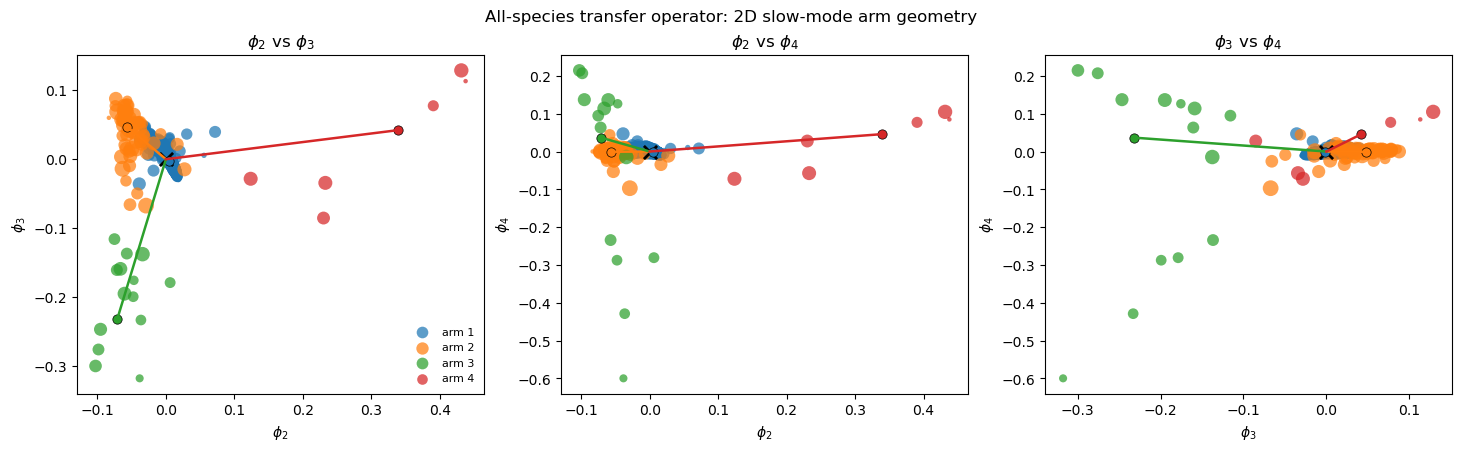

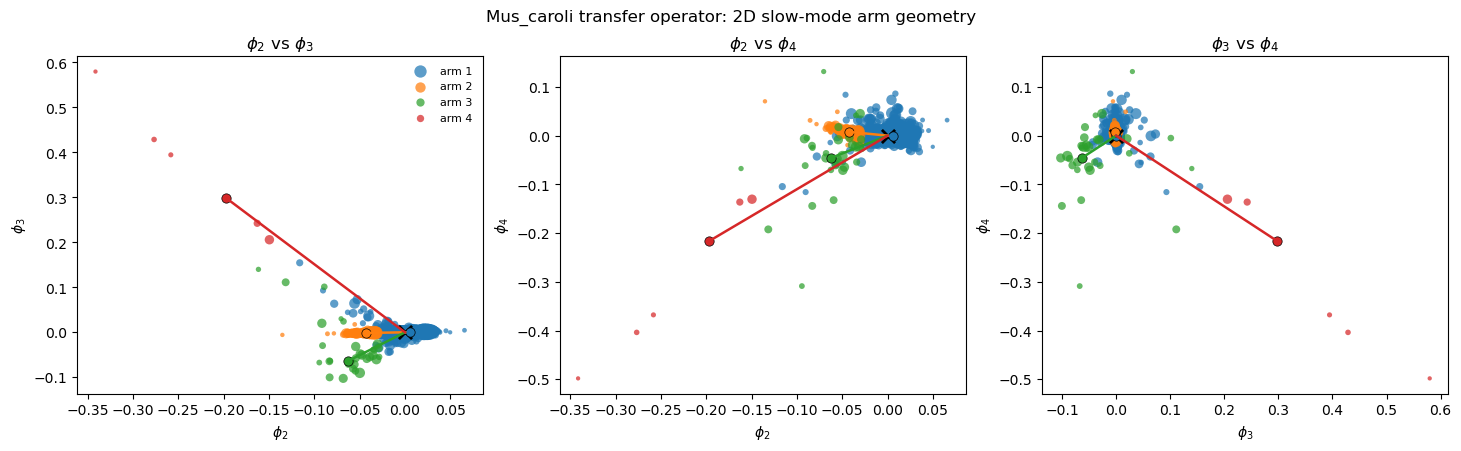

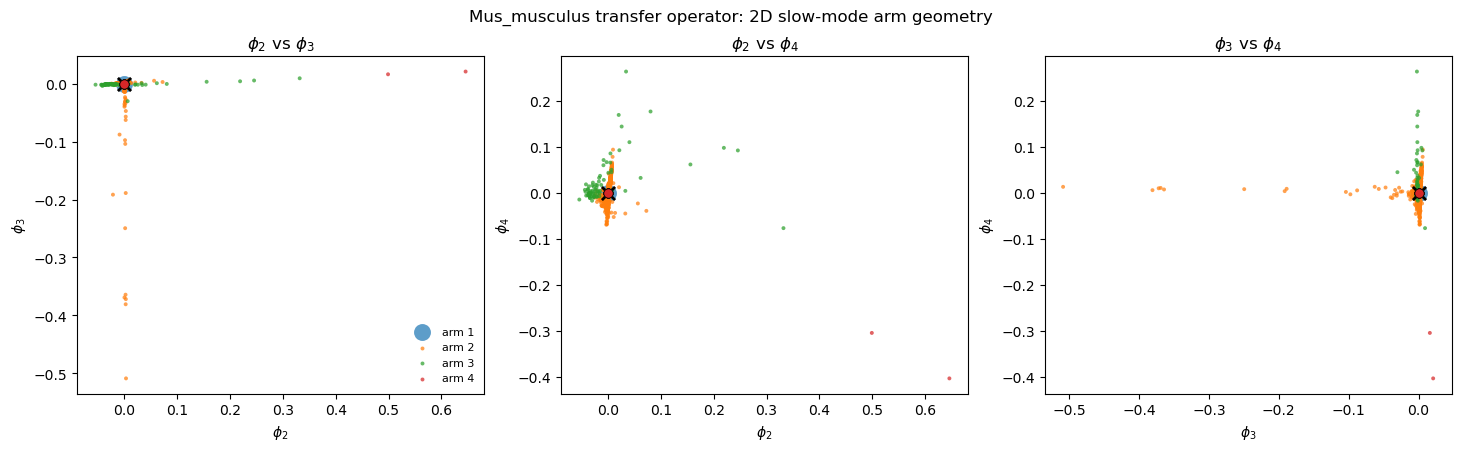

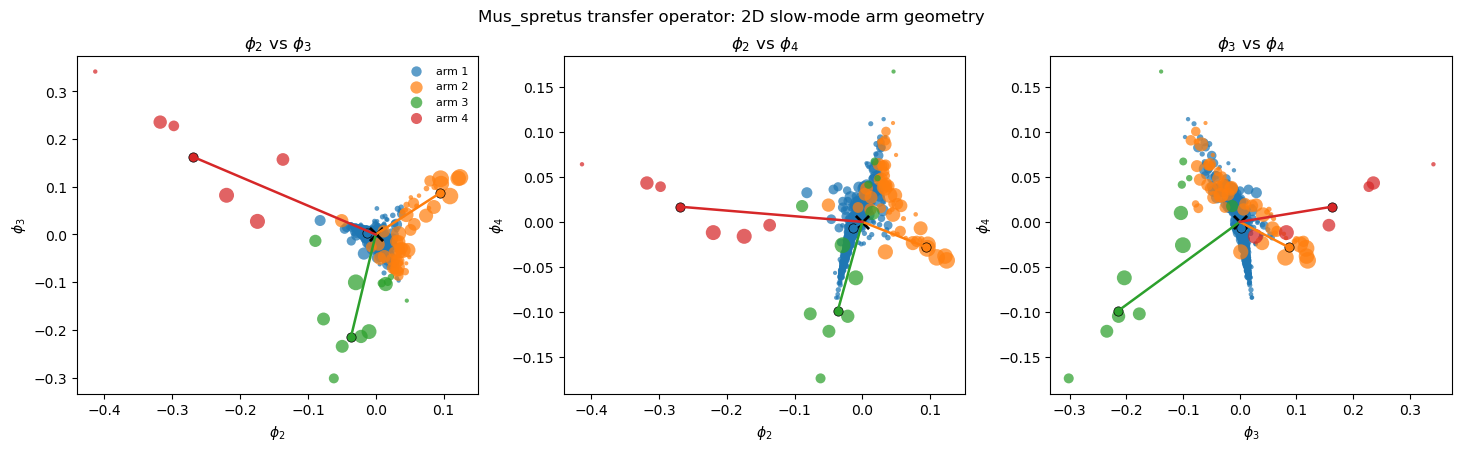

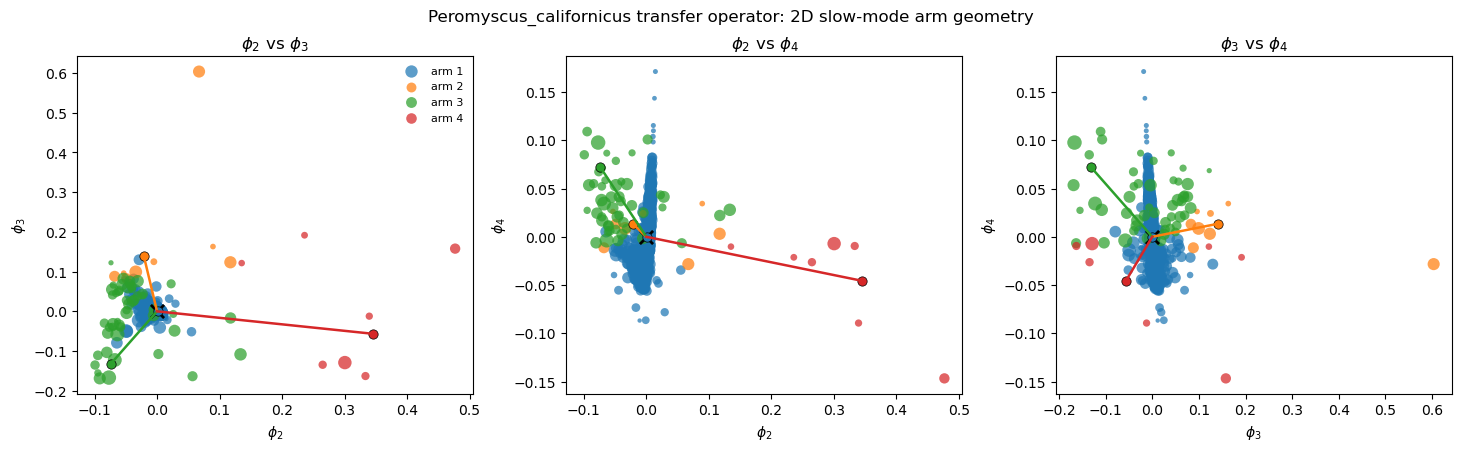

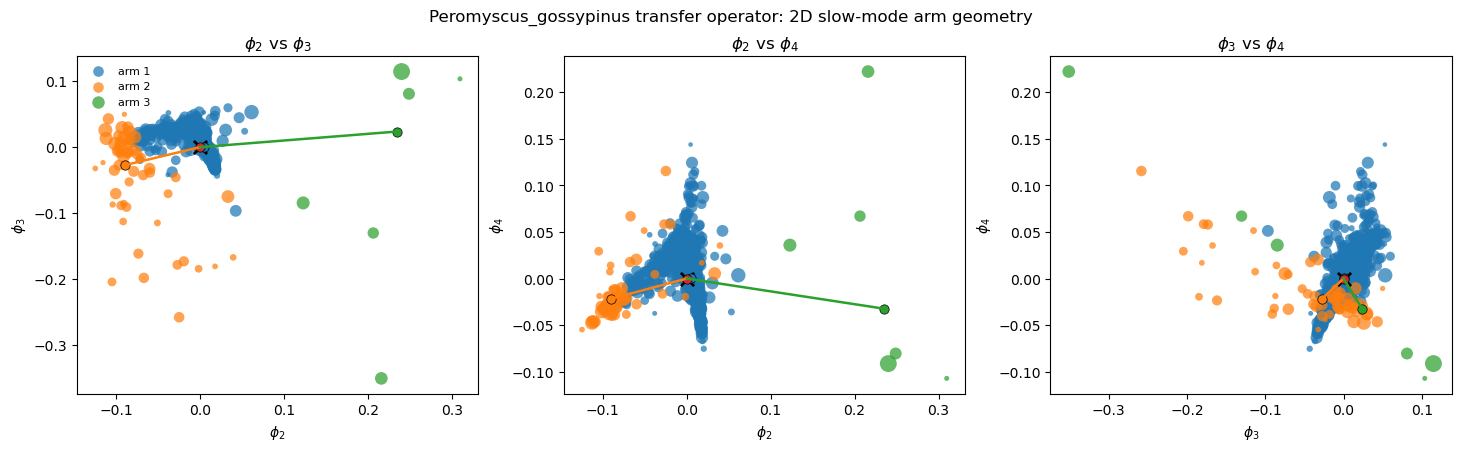

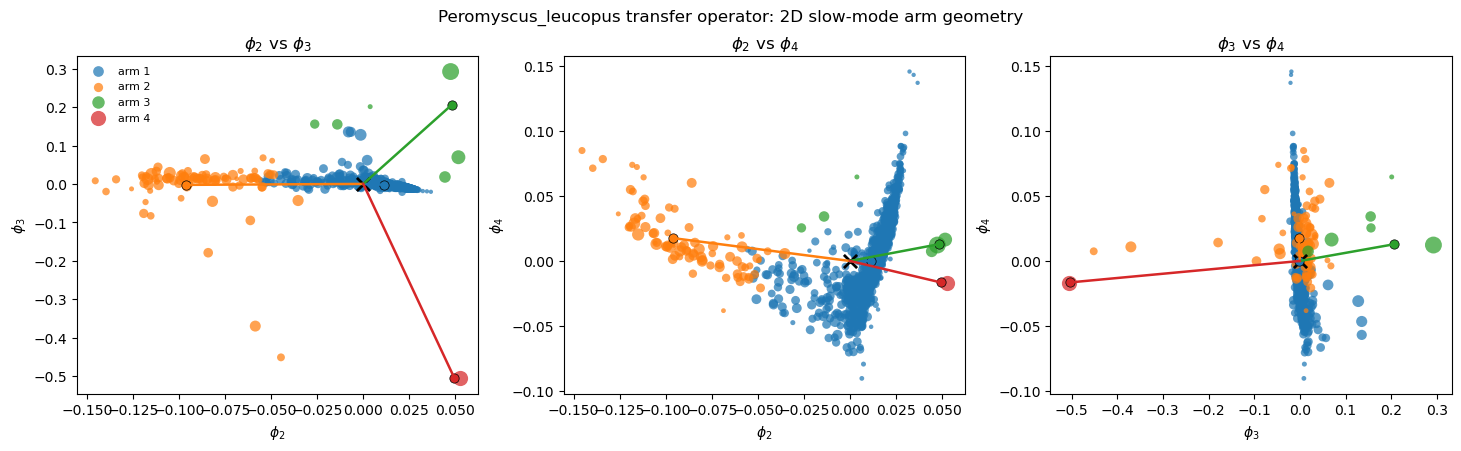

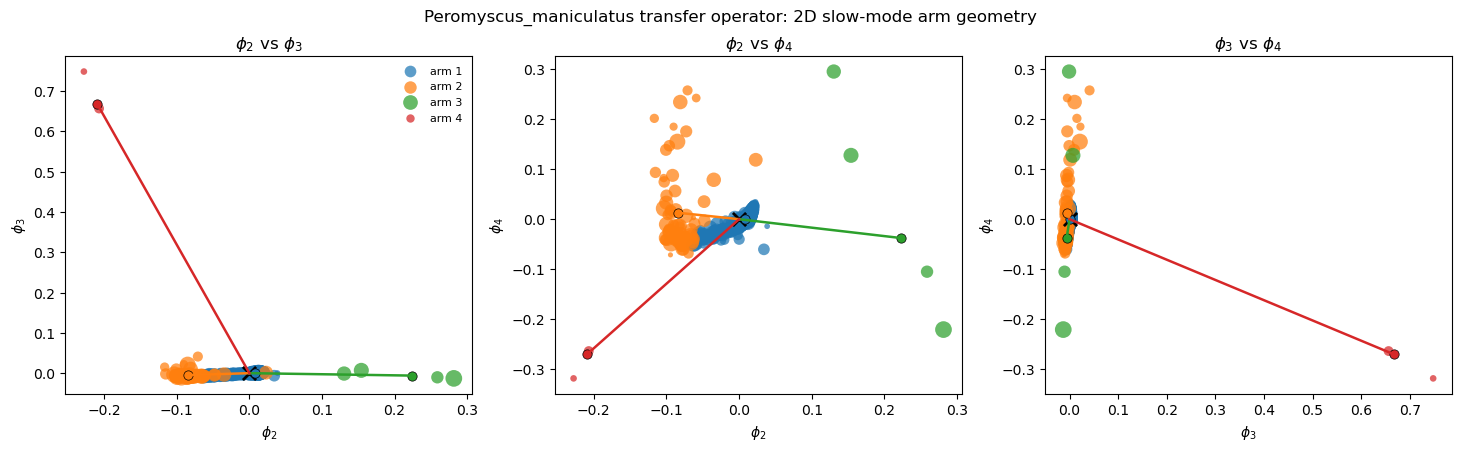

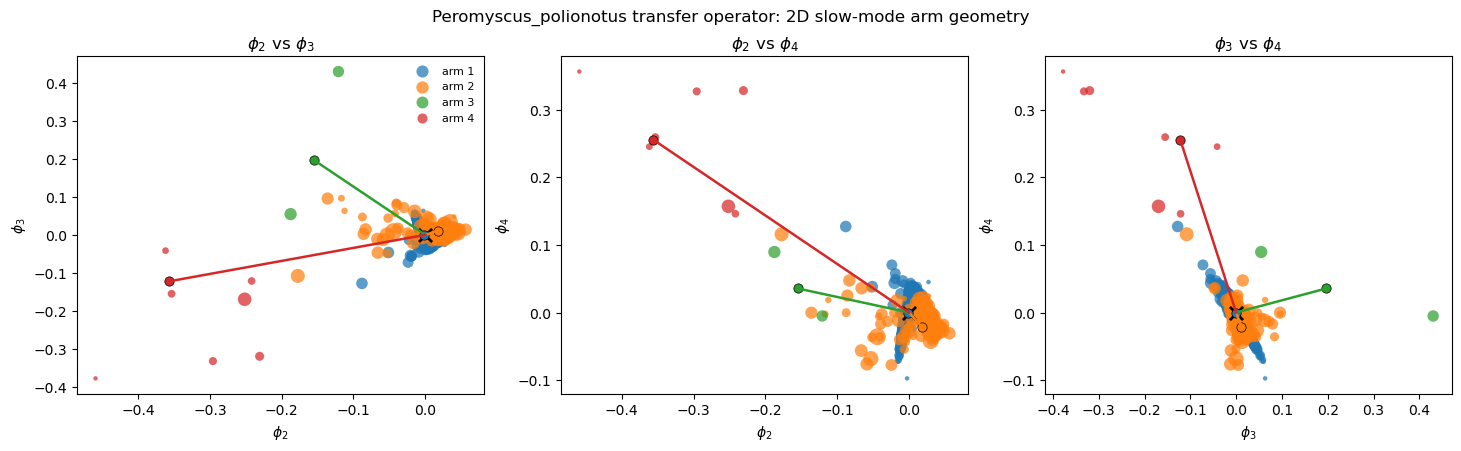

In [158]:
def plot_phi_2d_views(run, out_dir, *, title_prefix):
    out_dir.mkdir(parents=True, exist_ok=True)
    phi = np.asarray(run['phi'], dtype=float)
    chi = np.asarray(run['chi'], dtype=float)
    pi = np.asarray(run['pi'], dtype=float)
    assignments = np.asarray(run['assignments'], dtype=int)
    geometry = run.get('geometry', {})
    hub = np.asarray(geometry.get('hub', np.average(phi, axis=0, weights=np.maximum(pi, 1e-12))), dtype=float)
    centroids = np.asarray(geometry.get('arm_centroids', np.zeros((chi.shape[1], phi.shape[1]))), dtype=float)
    pairs = [
        (0, 1, r'$\phi_2$', r'$\phi_3$'),
        (0, 2, r'$\phi_2$', r'$\phi_4$'),
        (1, 2, r'$\phi_3$', r'$\phi_4$'),
    ]
    palette = plt.get_cmap('tab10')
    sizes = 8 + 140 * np.sqrt(pi / max(pi.max(), 1e-12))

    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), constrained_layout=True)
    for ax, (x_idx, y_idx, x_label, y_label) in zip(axes, pairs):
        for arm in range(chi.shape[1]):
            mask = assignments == arm
            if not mask.any():
                continue
            ax.scatter(
                phi[mask, x_idx],
                phi[mask, y_idx],
                s=sizes[mask],
                color=palette(arm % 10),
                alpha=0.72,
                linewidths=0,
                label=f'arm {arm + 1}',
            )
        ax.scatter(hub[x_idx], hub[y_idx], marker='x', s=90, color='black', linewidths=2)
        for arm in range(chi.shape[1]):
            if centroids.shape[0] <= arm:
                continue
            ax.plot(
                [hub[x_idx], centroids[arm, x_idx]],
                [hub[y_idx], centroids[arm, y_idx]],
                color=palette(arm % 10),
                linewidth=1.8,
            )
            ax.scatter(
                centroids[arm, x_idx],
                centroids[arm, y_idx],
                marker='o',
                s=45,
                color=palette(arm % 10),
                edgecolors='black',
                linewidths=0.5,
            )
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f'{x_label} vs {y_label}')
    axes[0].legend(loc='best', fontsize=8, frameon=False)
    fig.suptitle(f'{title_prefix}: 2D slow-mode arm geometry')
    fig.savefig(out_dir / 'phi_2d_arm_views.png', dpi=260)
    plt.show()

    view_rows = []
    for cluster in range(phi.shape[0]):
        row = {
            'cluster': int(cluster),
            'pi': float(pi[cluster]),
            'arm_assignment': int(assignments[cluster]),
        }
        for dim in range(phi.shape[1]):
            row[f'phi_{dim + 2}'] = float(phi[cluster, dim])
        for arm in range(chi.shape[1]):
            row[f'chi_arm_{arm + 1}'] = float(chi[cluster, arm])
        view_rows.append(row)
    pd.DataFrame(view_rows).to_csv(out_dir / 'phi_2d_view_cluster_table.csv', index=False)


plot_phi_2d_views(
    all_species_run,
    arm_dir / 'all_species_operator',
    title_prefix='All-species transfer operator',
)

for species in species_names:
    plot_phi_2d_views(
        species_runs[species],
        arm_dir / 'species_operators' / species,
        title_prefix=f'{species} transfer operator',
    )


In [ ]:
# Replicate the fly-analysis plot set for each species-specific GPCCA arm model.
# These plots use species_runs[species], so arms are fit separately for each species.
FLY_STYLE_FS_HZ = 120.0
FLY_STYLE_MIN_CLUSTER_TIME_SECONDS = 1.0 / FLY_STYLE_FS_HZ  # drop unvisited clusters.
FLY_STYLE_INDIVIDUALS_PER_PAGE = 6
FLY_STYLE_SAVE_FIGURES = True
FLY_STYLE_SHOW_FIGURES = False
RUN_FLY_STYLE_TRANSFER_OPERATOR_PLOTS = False  # many pages per species; enable when needed.
RUN_FLY_STYLE_FIGURE_4 = True
RUN_FLY_STYLE_FIGURE_5 = False
RUN_FLY_STYLE_CLUSTER_TIME = True
RUN_FLY_STYLE_SUPPLEMENT_8 = False  # skipped during full execution; powerlaw fit can fail on empty dwell arrays

fly_style_dir = OUT_DIR / 'fly_style_per_species_arms'
fly_style_dir.mkdir(parents=True, exist_ok=True)


def save_and_maybe_show(fig, out_dir, name):
    out_dir.mkdir(parents=True, exist_ok=True)
    if FLY_STYLE_SAVE_FIGURES:
        fig.savefig(out_dir / f'{name}.png', dpi=220, bbox_inches='tight')
        fig.savefig(out_dir / f'{name}.pdf', bbox_inches='tight')
    if FLY_STYLE_SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def species_state_arrays_and_ids(species):
    species_manifest = manifest.loc[manifest['species'].astype(str) == str(species)].copy()
    states = [np.asarray(np.load(path, mmap_mode='r'), dtype=np.int64) for path in species_manifest['state_file']]
    ids = species_manifest['global_id'].astype(str).tolist()
    state_files = species_manifest['state_file'].astype(str).tolist()
    return states, ids, state_files


def fly_style_species_run(species):
    run = dict(species_runs[species])
    states, individual_ids, state_files = species_state_arrays_and_ids(species)
    run.update({
        'root': KMEANS_ROOT,
        'species': species,
        'fs': float(FLY_STYLE_FS_HZ),
        'tau_seconds': float(lag_frames) / float(FLY_STYLE_FS_HZ),
        'states': states,
        'individual_ids': individual_ids,
        'state_files': state_files,
        'projection': {},
        'proj_files': [],
    })
    return run


fly_style_inventory_rows = []
for species in species_names:
    run = fly_style_species_run(species)
    species_out = fly_style_dir / species
    species_out.mkdir(parents=True, exist_ok=True)

    filter_report = fpr.export_cluster_time_filter_report(
        run,
        species_out / 'cluster_time_filter_report.csv',
        FLY_STYLE_MIN_CLUSTER_TIME_SECONDS,
    )

    if RUN_FLY_STYLE_CLUSTER_TIME:
        try:
            fig = fpr.plot_cluster_time_distribution(
                run,
                min_cluster_time_seconds=FLY_STYLE_MIN_CLUSTER_TIME_SECONDS,
            )
            fig.suptitle(f'{species}: shared-cluster occupancy for species-specific arms', fontsize=12, fontweight='bold')
            save_and_maybe_show(fig, species_out, 'cluster_time_distribution')
        except Exception as exc:
            record_plot_warning('fly_style_cluster_time', species, exc)

    if RUN_FLY_STYLE_TRANSFER_OPERATOR_PLOTS:
        pooled_T_fig, individual_T_figs, transfer_order = fpr.transfer_operator_figures(
            run,
            individuals_per_page=FLY_STYLE_INDIVIDUALS_PER_PAGE,
            visited_only=True,
            min_cluster_time_seconds=FLY_STYLE_MIN_CLUSTER_TIME_SECONDS,
        )
        pooled_T_fig.suptitle(f'{species}: pooled transfer operator', fontsize=12, fontweight='bold')
        save_and_maybe_show(pooled_T_fig, species_out, 'transfer_operator_pooled')
        np.save(species_out / 'transfer_operator_plot_order.npy', transfer_order)
        for page, fig in enumerate(individual_T_figs, start=1):
            fig.suptitle(f'{species}: individual transfer operators page {page}', fontsize=12, fontweight='bold')
            save_and_maybe_show(fig, species_out, f'transfer_operator_individuals_page_{page:02d}')

    if RUN_FLY_STYLE_FIGURE_4:
        try:
            fig4 = fpr.figure_4(
                run,
                fixed=None,
                min_cluster_time_seconds=FLY_STYLE_MIN_CLUSTER_TIME_SECONDS,
            )
            fig4.suptitle(f'{species}: fly-style slow-mode geometry on species-specific arms', fontsize=13, fontweight='bold')
            save_and_maybe_show(fig4, species_out, 'figure_4_species_specific_arms')
        except Exception as exc:
            record_plot_warning('fly_style_figure_4', species, exc)

    if RUN_FLY_STYLE_FIGURE_5:
        try:
            fig5 = fpr.figure_5(run, behavior_density=None)
            fig5.suptitle(f'{species}: fly-style dynamics on species-specific arms', fontsize=13, fontweight='bold')
            save_and_maybe_show(fig5, species_out, 'figure_5_species_specific_arms')
        except Exception as exc:
            record_plot_warning('fly_style_figure_5', species, exc)

    if RUN_FLY_STYLE_SUPPLEMENT_8:
        try:
            fig_s8 = fpr.supplement_8(run)
            fig_s8.suptitle(f'{species}: residence diagnostics on species-specific arms', fontsize=13, fontweight='bold')
            save_and_maybe_show(fig_s8, species_out, 'supplement_8_species_specific_arms')
        except Exception as exc:
            record_plot_warning('fly_style_supplement_8', species, exc)

    fly_style_inventory_rows.append({
        'species': species,
        'output_dir': str(species_out),
        'n_individuals': int(len(run['states'])),
        'n_clusters': int(run['n_clusters']),
        'n_fit_clusters': int(run.get('n_fit_clusters', len(run.get('active_clusters', [])))),
        'n_basins': int(run['n_basins']),
        'lag_frames': int(run['lag']),
        'fs_hz': float(run['fs']),
        'min_cluster_time_seconds': float(FLY_STYLE_MIN_CLUSTER_TIME_SECONDS),
        'kept_clusters_for_plots': int(filter_report['kept_clusters']),
        'dropped_clusters_for_plots': int(filter_report['dropped_clusters']),
    })

fly_style_inventory = pd.DataFrame(fly_style_inventory_rows)
fly_style_inventory.to_csv(fly_style_dir / 'fly_style_per_species_arm_plot_inventory.csv', index=False)
display(fly_style_inventory)
save_plot_warning_log()


/opt/anaconda3/lib/python3.10/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/opt/anaconda3/lib/python3.10/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


## Dwell, Residence, and Drift Comparisons Per Species


In [ ]:
# Reproduce all-species subplot figures for species-specific arms.
# Outputs are written under the evensamp notebook output directory.
import runpy
from IPython.display import Image, display

arm_dwell_velocity_script = REPO_ROOT / 'scripts' / 'plot_arm_dwell_velocity_comparisons.py'
runpy.run_path(str(arm_dwell_velocity_script), run_name='__main__')

arm_dwell_velocity_dir = OUT_DIR / 'arm_dwell_velocity_comparisons_occupancy_threshold'
for filename in [
    'species_arm_dwell_time_violin_subplots.png',
    'species_residence_time_ccdf_subplots.png',
    'species_drift_velocity_field_phi2_phi3_subplots.png',
]:
    display(Image(filename=str(arm_dwell_velocity_dir / filename)))


## Eigenspectra and Hungarian Arm Matching


In [ ]:
# Reproduce transfer-operator eigenspectra and pairwise Hungarian arm matching.
# Arm matching compares species-specific chi columns over the shared 1000-cluster space.
# The occupied-arm matrix ignores effectively zero-mass arms before Hungarian matching.
import runpy
from IPython.display import Image, display

eigenspectra_arm_matching_script = REPO_ROOT / 'scripts' / 'plot_eigenspectra_arm_matching.py'
runpy.run_path(str(eigenspectra_arm_matching_script), run_name='__main__')

eigenspectra_arm_matching_dir = OUT_DIR / 'eigenspectra_arm_matching_occupancy_threshold'
for filename in [
    'species_transfer_operator_eigenspectra.png',
    'species_pair_hungarian_matched_occupied_arm_mean_cosine_heatmap.png',
    'species_pair_hungarian_matched_arm_mean_cosine_heatmap.png',
    'species_pair_hungarian_matched_arm_min_cosine_heatmap.png',
]:
    display(Image(filename=str(eigenspectra_arm_matching_dir / filename)))


## Species-Specific Operator Arms On Shared Delay-Embedded UMAP


In [ ]:
# Reproduce species-specific transfer-operator arm overlays and matched-arm densities on the shared delay-embedded UMAP.
# Uses the saved global cluster embedding from the evensamp K-means cluster centers.
# The Hungarian-matched versions align arms across species, then relabel matched arms by total density so arm 1 is densest.
# Density panels show normalized matched-arm density directly, without subtracting or dividing by a species/across-species mean.
import runpy
from IPython.display import Image, display

species_operator_arm_umap_script = REPO_ROOT / 'scripts' / 'plot_species_operator_arm_umap_enrichment.py'
runpy.run_path(str(species_operator_arm_umap_script), run_name='__main__')

species_operator_arm_umap_dir = OUT_DIR / 'species_operator_arm_umap_enrichment_occupancy_threshold'
display(Image(filename=str(species_operator_arm_umap_dir / 'all_species_hungarian_matched_species_operator_hard_arms_shared_delay_umap.png')))
for arm in range(1, 5):
    display(Image(filename=str(species_operator_arm_umap_dir / f'hungarian_matched_arm_{arm}_density_by_species.png')))
for arm in range(1, 5):
    display(Image(filename=str(species_operator_arm_umap_dir / f'hungarian_matched_arm_{arm}_moseq_top_syllables_by_species.png')))
    display(Image(filename=str(species_operator_arm_umap_dir / f'hungarian_matched_arm_{arm}_moseq_probability_heatmap.png')))
for species in species_names:
    display(Image(filename=str(species_operator_arm_umap_dir / f'{species}_hungarian_matched_arm_density_panel.png')))


## Arm Enrichment Across MoSeq Syllables

In [ ]:
ARM_ENRICHMENT_TOP_N_SYLLABLES = 50
ARM_ENRICHMENT_TOP_LABELS_PER_ARM = 5
ARM_ENRICHMENT_EXCLUDE_MOSEQ_CLUSTERS = ()


def aggregate_arm_enrichment(enrichment_df, *, species=None):
    df = enrichment_df.copy()
    if species is not None:
        df = df.loc[df['species'].astype(str) == str(species)].copy()
    if ARM_ENRICHMENT_EXCLUDE_MOSEQ_CLUSTERS:
        excluded = {int(value) for value in ARM_ENRICHMENT_EXCLUDE_MOSEQ_CLUSTERS}
        df = df.loc[~df['moseq_cluster'].astype(int).isin(excluded)].copy()
    if df.empty:
        raise ValueError('No arm enrichment rows available after filtering.')

    weighted = (
        df.groupby(['arm', 'moseq_cluster'], as_index=False)['weighted_frames']
        .sum()
    )
    baseline = (
        df[['species', 'moseq_cluster', 'matched_frames']]
        .drop_duplicates(['species', 'moseq_cluster'])
        .groupby('moseq_cluster', as_index=False)['matched_frames']
        .sum()
        .rename(columns={'matched_frames': 'baseline_frames'})
    )

    arms = np.array(sorted(weighted['arm'].astype(int).unique()), dtype=int)
    syllables = np.array(sorted(set(weighted['moseq_cluster'].astype(int)) | set(baseline['moseq_cluster'].astype(int))), dtype=int)
    arm_index = {arm: i for i, arm in enumerate(arms)}
    syllable_index = {syllable: i for i, syllable in enumerate(syllables)}

    counts_matrix = np.zeros((len(arms), len(syllables)), dtype=float)
    for row in weighted.itertuples(index=False):
        counts_matrix[arm_index[int(row.arm)], syllable_index[int(row.moseq_cluster)]] += float(row.weighted_frames)

    baseline_counts = np.zeros(len(syllables), dtype=float)
    for row in baseline.itertuples(index=False):
        baseline_counts[syllable_index[int(row.moseq_cluster)]] += float(row.baseline_frames)

    arm_totals = counts_matrix.sum(axis=1, keepdims=True)
    global_freq = baseline_counts / max(baseline_counts.sum(), ARM_EPS)
    arm_syllable_freq = np.divide(
        counts_matrix,
        np.maximum(arm_totals, ARM_EPS),
        out=np.zeros_like(counts_matrix),
        where=arm_totals > 0,
    )
    log2_enrichment = np.log2((arm_syllable_freq + ARM_EPS) / (global_freq[None, :] + ARM_EPS))
    return {
        'arms': arms,
        'syllables': syllables,
        'weighted_frames': counts_matrix,
        'baseline_counts': baseline_counts,
        'global_freq': global_freq,
        'arm_syllable_freq': arm_syllable_freq,
        'log2_enrichment': log2_enrichment,
    }


def plot_arm_syllable_enrichment(summary, *, title, out_path, top_n=ARM_ENRICHMENT_TOP_N_SYLLABLES):
    syllables = summary['syllables']
    arms = summary['arms']
    global_freq = summary['global_freq']
    arm_syllable_freq = summary['arm_syllable_freq']
    log2_enrichment = summary['log2_enrichment']

    if log2_enrichment.size == 0:
        raise ValueError(f'No enrichment values to plot for {title}')

    max_abs_enrichment = np.nanmax(np.abs(log2_enrichment), axis=0)
    syllable_order = np.argsort(max_abs_enrichment)[::-1]
    top_n = min(int(top_n), len(syllables))
    syllable_order = syllable_order[:top_n]

    plot_syllables = syllables[syllable_order]
    plot_syllable_labels = label_syllables(plot_syllables) if 'label_syllables' in globals() else plot_syllables
    plot_enrichment = log2_enrichment[:, syllable_order]
    plot_arm_freq = arm_syllable_freq[:, syllable_order]
    plot_global_freq = global_freq[syllable_order]

    vmax = np.nanpercentile(np.abs(plot_enrichment), 98)
    vmax = max(float(vmax), 1e-6)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(13, 8),
        gridspec_kw={'height_ratios': [3, 1]},
        constrained_layout=True,
    )

    ax = axes[0, 0]
    im = ax.imshow(plot_enrichment, cmap='coolwarm', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title('Soft-chi MoSeq syllable enrichment', fontsize=10)
    ax.set_xlabel('MoSeq syllable', fontsize=9, fontweight='bold')
    ax.set_ylabel('GPCCA arm', fontsize=9, fontweight='bold')
    ax.set_yticks(np.arange(len(arms)))
    ax.set_yticklabels([f'arm {arm + 1}' for arm in arms])
    ax.set_xticks(np.arange(top_n))
    ax.set_xticklabels(plot_syllable_labels, rotation=90, fontsize=6, ha='right')
    fig.colorbar(im, ax=ax, label='log2 enrichment')

    ax = axes[0, 1]
    im = ax.imshow(plot_arm_freq, cmap='magma', aspect='auto', vmin=0)
    ax.set_title('p(syllable | arm), soft weighted', fontsize=10)
    ax.set_xlabel('MoSeq syllable', fontsize=9, fontweight='bold')
    ax.set_ylabel('GPCCA arm', fontsize=9, fontweight='bold')
    ax.set_yticks(np.arange(len(arms)))
    ax.set_yticklabels([f'arm {arm + 1}' for arm in arms])
    ax.set_xticks(np.arange(top_n))
    ax.set_xticklabels(plot_syllable_labels, rotation=90, fontsize=6, ha='right')
    fig.colorbar(im, ax=ax, label='frequency')

    ax = axes[1, 0]
    top_rows = []
    for arm_pos, arm in enumerate(arms):
        top_idx = np.argsort(log2_enrichment[arm_pos])[::-1][:ARM_ENRICHMENT_TOP_LABELS_PER_ARM]
        ax.scatter(np.repeat(arm_pos, len(top_idx)), log2_enrichment[arm_pos, top_idx], s=35)
        for syllable_idx in top_idx:
            top_rows.append({
                'arm': int(arm),
                'moseq_cluster': int(syllables[syllable_idx]),
                'syllable_label': str(syllable_label_map.get(int(syllables[syllable_idx]), int(syllables[syllable_idx]))) if 'syllable_label_map' in globals() else str(int(syllables[syllable_idx])),
                'log2_enrichment': float(log2_enrichment[arm_pos, syllable_idx]),
                'p_syllable_given_arm': float(arm_syllable_freq[arm_pos, syllable_idx]),
                'p_syllable_global': float(global_freq[syllable_idx]),
            })
    ax.axhline(0, color='k', linewidth=1)
    ax.set_title('Top enriched syllables per arm', fontsize=10)
    ax.set_xlabel('GPCCA arm', fontsize=9, fontweight='bold')
    ax.set_ylabel('log2 enrichment', fontsize=9, fontweight='bold')
    ax.set_xticks(np.arange(len(arms)))
    ax.set_xticklabels([f'arm {arm + 1}' for arm in arms])

    ax = axes[1, 1]
    ax.bar(np.arange(top_n), plot_global_freq)
    ax.set_title('Global MoSeq syllable frequency', fontsize=10)
    ax.set_xlabel('MoSeq syllable', fontsize=9, fontweight='bold')
    ax.set_ylabel('frequency', fontsize=9, fontweight='bold')
    ax.set_xticks(np.arange(top_n))
    ax.set_xticklabels(plot_syllable_labels, rotation=90, fontsize=6, ha='right')

    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.savefig(out_path, dpi=260)
    plt.show()

    top_table = pd.DataFrame(top_rows)
    top_table.to_csv(out_path.with_name(out_path.stem + '_top_syllables.csv'), index=False)
    matrix_df = pd.DataFrame(
        log2_enrichment,
        index=[f'arm_{arm + 1}' for arm in arms],
        columns=[f'moseq_{syllable}' for syllable in syllables],
    )
    matrix_df.to_csv(out_path.with_name(out_path.stem + '_log2_enrichment_matrix.csv'))
    return fig, top_table


plot_dir = arm_dir / 'arm_moseq_enrichment_plots'
plot_dir.mkdir(parents=True, exist_ok=True)

# 1. All-species level: pooled over all animals scored with the all-species transfer-operator arms.
all_species_enrichment_csv = arm_dir / 'arm_moseq_enrichment' / 'all_species_operator' / 'arm_moseq_enrichment.csv'
all_species_enrichment = pd.read_csv(all_species_enrichment_csv)
all_species_summary = aggregate_arm_enrichment(all_species_enrichment)
fig, all_species_top = plot_arm_syllable_enrichment(
    all_species_summary,
    title='All-species transfer operator: MoSeq syllable enrichment of GPCCA arms',
    out_path=plot_dir / 'all_species_operator_arm_moseq_syllable_enrichment.png',
)
display(all_species_top)

# 2. By-species level: each species scored with its own species-specific transfer-operator arms.
species_plot_rows = []
for species in species_names:
    species_csv = arm_dir / 'arm_moseq_enrichment' / 'species_operator' / species / 'arm_moseq_enrichment.csv'
    if not species_csv.exists():
        print(f'skipping {species}; missing {species_csv}')
        continue
    species_enrichment = pd.read_csv(species_csv)
    species_summary = aggregate_arm_enrichment(species_enrichment, species=species)
    species_out = plot_dir / f'{species}_operator_arm_moseq_syllable_enrichment.png'
    fig, top_table = plot_arm_syllable_enrichment(
        species_summary,
        title=f'{species} transfer operator: MoSeq syllable enrichment of GPCCA arms',
        out_path=species_out,
    )
    top_table = top_table.assign(species=species)
    species_plot_rows.append(top_table)

species_top_syllables = pd.concat(species_plot_rows, ignore_index=True) if species_plot_rows else pd.DataFrame()
species_top_syllables.to_csv(plot_dir / 'species_operator_top_enriched_syllables_by_arm.csv', index=False)
display(species_top_syllables.head(40))


## Arm-Specific MoSeq Enrichment On Shared Cluster UMAP

## Within-Species And Between-Species Variability In Cluster Space

In [ ]:
variability_dir = OUT_DIR / 'within_between_cluster_variability'
variability_dir.mkdir(parents=True, exist_ok=True)

# Individual-level cluster occupancy distributions in the shared 1000-cluster state space.
individual_rows = []
individual_distributions = []
for row in manifest.itertuples(index=False):
    states = np.asarray(np.load(row.state_file, mmap_mode='r'), dtype=np.int64)
    valid = (states >= 0) & (states < N_CLUSTERS)
    cluster_counts_ind = np.bincount(states[valid], minlength=N_CLUSTERS).astype(float)
    distribution = cluster_counts_ind / max(cluster_counts_ind.sum(), 1.0)
    individual_distributions.append(distribution)
    individual_rows.append({
        'global_id': str(row.global_id),
        'species': str(row.species),
        'n_frames': int(valid.sum()),
    })

individual_info = pd.DataFrame(individual_rows)
X_individual = np.vstack(individual_distributions)
np.save(variability_dir / 'individual_cluster_usage_distributions.npy', X_individual)
individual_info.to_csv(variability_dir / 'individual_cluster_usage_manifest.csv', index=False)

species_mean_rows = []
species_mean_matrix = []
within_var_by_species = []
for species in species_names:
    mask = individual_info['species'].astype(str).to_numpy() == str(species)
    X_species = X_individual[mask]
    species_mean = X_species.mean(axis=0)
    species_mean_matrix.append(species_mean)
    within_var = X_species.var(axis=0, ddof=1 if X_species.shape[0] > 1 else 0)
    within_var_by_species.append(within_var)
    species_mean_rows.append({
        'species': species,
        'n_individuals': int(mask.sum()),
        'mean_entropy_bits': float(-(species_mean[species_mean > 0] * np.log2(species_mean[species_mean > 0])).sum()),
    })

species_mean_matrix = np.vstack(species_mean_matrix)
within_var_by_species = np.vstack(within_var_by_species)
mean_within_var = within_var_by_species.mean(axis=0)
between_var = species_mean_matrix.var(axis=0, ddof=1 if len(species_names) > 1 else 0)

grand_mean = X_individual.mean(axis=0)
species_grand_mean = species_mean_matrix.mean(axis=0)

variability_summary = pd.DataFrame({
    'cluster': np.arange(N_CLUSTERS),
    'mean_within_species_variance': mean_within_var,
    'between_species_variance': between_var,
    'total_individual_mean_usage': grand_mean,
    'species_mean_usage': species_grand_mean,
    'within_between_variance_ratio': np.divide(
        mean_within_var,
        between_var,
        out=np.full(N_CLUSTERS, np.nan),
        where=between_var > 0,
    ),
})
variability_summary.to_csv(variability_dir / 'cluster_within_between_variability_summary.csv', index=False)
pd.DataFrame(species_mean_rows).to_csv(variability_dir / 'species_cluster_usage_summary.csv', index=False)

occupied = (variability_summary['total_individual_mean_usage'] > 0) | (variability_summary['species_mean_usage'] > 0)
fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
scatter = ax.scatter(
    variability_summary.loc[occupied, 'mean_within_species_variance'] + 1e-14,
    variability_summary.loc[occupied, 'between_species_variance'] + 1e-14,
    c=variability_summary.loc[occupied, 'total_individual_mean_usage'],
    s=18,
    cmap='viridis',
    alpha=0.78,
    linewidths=0,
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('mean within-species variance across individuals')
ax.set_ylabel('between-species variance of species means')
ax.set_title('Do variable clusters within species also vary between species?')
fig.colorbar(scatter, ax=ax, label='mean cluster usage')
fig.savefig(variability_dir / 'within_vs_between_cluster_variance_scatter.png', dpi=260)
plt.show()

try:
    from scipy.stats import spearmanr, pearsonr
    rho, rho_p = spearmanr(
        variability_summary.loc[occupied, 'mean_within_species_variance'],
        variability_summary.loc[occupied, 'between_species_variance'],
    )
    pearson_r, pearson_p = pearsonr(
        np.log10(variability_summary.loc[occupied, 'mean_within_species_variance'] + 1e-14),
        np.log10(variability_summary.loc[occupied, 'between_species_variance'] + 1e-14),
    )
except Exception as exc:
    print(f'correlation stats unavailable ({exc})')
    rho = rho_p = pearson_r = pearson_p = np.nan

# Subspace alignment: compare directions of within-species individual residual covariance
# to directions of between-species mean covariance.
species_index_for_individual = individual_info['species'].map({species: i for i, species in enumerate(species_names)}).to_numpy()
X_within_resid = X_individual - species_mean_matrix[species_index_for_individual]
X_between_resid = species_mean_matrix - species_mean_matrix.mean(axis=0, keepdims=True)

n_components = min(20, X_individual.shape[0] - len(species_names), len(species_names) - 1, N_CLUSTERS)
if n_components < 1:
    raise ValueError('Not enough individuals/species for covariance alignment analysis.')

within_pca = PCA(n_components=n_components, svd_solver='full').fit(X_within_resid)
between_pca = PCA(n_components=min(n_components, len(species_names) - 1), svd_solver='full').fit(X_between_resid)
W = within_pca.components_.T
B = between_pca.components_.T
cosine = np.abs(W.T @ B)
cosine_df = pd.DataFrame(
    cosine,
    index=[f'within_PC{i + 1}' for i in range(cosine.shape[0])],
    columns=[f'between_PC{i + 1}' for i in range(cosine.shape[1])],
)
cosine_df.to_csv(variability_dir / 'within_between_pca_direction_absolute_cosine.csv')

alignment_rows = []
for between_idx in range(B.shape[1]):
    for k in range(1, W.shape[1] + 1):
        alignment_rows.append({
            'between_pc': between_idx + 1,
            'top_within_pcs': k,
            'cumulative_squared_cosine': float(np.sum((W[:, :k].T @ B[:, between_idx]) ** 2)),
        })
alignment_curve = pd.DataFrame(alignment_rows)
alignment_curve.to_csv(variability_dir / 'between_direction_alignment_to_within_subspace.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
im = axes[0].imshow(cosine, aspect='auto', cmap='magma', vmin=0, vmax=1)
axes[0].set_title('Absolute cosine between variability PCs')
axes[0].set_xlabel('between-species PC')
axes[0].set_ylabel('within-species PC')
axes[0].set_xticks(np.arange(cosine.shape[1]))
axes[0].set_xticklabels(np.arange(1, cosine.shape[1] + 1))
axes[0].set_yticks(np.arange(cosine.shape[0]))
axes[0].set_yticklabels(np.arange(1, cosine.shape[0] + 1))
fig.colorbar(im, ax=axes[0], label='abs cosine')

for between_pc, sub in alignment_curve.groupby('between_pc'):
    axes[1].plot(sub['top_within_pcs'], sub['cumulative_squared_cosine'], marker='o', label=f'between PC{between_pc}')
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel('number of top within-species PCs')
axes[1].set_ylabel('between direction variance captured')
axes[1].set_title('Do between-species directions lie in within-species subspace?')
axes[1].legend(fontsize=7, frameon=False)
fig.savefig(variability_dir / 'within_between_variability_subspace_alignment.png', dpi=260)
plt.show()

stats = pd.DataFrame([{
    'n_individuals': int(X_individual.shape[0]),
    'n_species': int(len(species_names)),
    'n_clusters': int(N_CLUSTERS),
    'spearman_rho_cluster_variances': float(rho),
    'spearman_p_cluster_variances': float(rho_p),
    'pearson_r_log_cluster_variances': float(pearson_r),
    'pearson_p_log_cluster_variances': float(pearson_p),
    'within_pca_variance_first': float(within_pca.explained_variance_ratio_[0]),
    'between_pca_variance_first': float(between_pca.explained_variance_ratio_[0]),
}])
stats.to_csv(variability_dir / 'within_between_variability_alignment_stats.csv', index=False)
display(stats)


## Hierarchically Clustered Transfer Operators

In [ ]:
CLUSTERED_TRANSFER_METHOD = 'average'
CLUSTERED_TRANSFER_LOG_SCALE = False
CLUSTERED_TRANSFER_EPS = 1e-12
CLUSTERED_TRANSFER_CMAP = 'magma'
CLUSTERED_TRANSFER_VMAX_PERCENTILE = 99.7

clustered_transfer_dir = OUT_DIR / 'hierarchically_clustered_transfer_operators'
clustered_transfer_dir.mkdir(parents=True, exist_ok=True)


def transition_profiles_for_clustering(T):
    T = np.asarray(T, dtype=np.float64)
    return np.concatenate([T, T.T], axis=1)


def hierarchical_transfer_order(T, active_clusters=None, *, method=CLUSTERED_TRANSFER_METHOD):
    T = np.asarray(T, dtype=np.float64)
    if active_clusters is None:
        active_clusters = np.arange(T.shape[0], dtype=int)
    active_clusters = np.asarray(active_clusters, dtype=int)
    if active_clusters.size <= 2:
        return active_clusters
    sub = T[np.ix_(active_clusters, active_clusters)]
    profiles = transition_profiles_for_clustering(sub)
    try:
        from scipy.cluster.hierarchy import leaves_list, linkage
        from scipy.spatial.distance import pdist
        distances = pdist(profiles, metric='euclidean')
        if np.allclose(distances, 0):
            return active_clusters
        local_order = leaves_list(linkage(distances, method=method))
        return active_clusters[local_order]
    except Exception as exc:
        print(f'Hierarchical clustering failed ({exc}); using natural cluster order.')
        return active_clusters


def plot_hierarchically_clustered_transfer(T, pi, order, *, title, out_prefix, log_scale=CLUSTERED_TRANSFER_LOG_SCALE):
    T = np.asarray(T, dtype=np.float64)
    pi = np.asarray(pi, dtype=np.float64)
    order = np.asarray(order, dtype=int)
    ordered = T[np.ix_(order, order)]
    if log_scale:
        image_values = np.log10(np.maximum(ordered, CLUSTERED_TRANSFER_EPS))
        colorbar_label = 'log10 transition probability'
    else:
        image_values = ordered
        colorbar_label = 'transition probability'

    fig, axes = plt.subplots(
        2, 1,
        figsize=(7.0, 7.8),
        gridspec_kw={'height_ratios': [1, 12]},
        constrained_layout=True,
    )
    ax_pi, ax = axes
    ax_pi.bar(np.arange(order.size), pi[order], width=1.0, color='#4C78A8')
    ax_pi.set_ylabel('pi')
    ax_pi.set_xticks([])
    ax_pi.set_title(title)

    
    if log_scale:
        vmin = vmax = None
    else:
        positive = image_values[image_values > 0]
        vmax = np.nanpercentile(positive, CLUSTERED_TRANSFER_VMAX_PERCENTILE) if positive.size else 1.0
        vmax = max(float(vmax), CLUSTERED_TRANSFER_EPS)
        vmin = 0.0
    image = ax.imshow(image_values, aspect='auto', cmap=CLUSTERED_TRANSFER_CMAP, vmin=vmin, vmax=vmax)
    ax.set_xlabel('cluster at t + lag, hierarchical order')
    ax.set_ylabel('cluster at t, hierarchical order')
    fig.colorbar(image, ax=ax, label=colorbar_label)

    out_prefix.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_prefix.with_suffix('.png'), dpi=260)
    fig.savefig(out_prefix.with_suffix('.pdf'))
    plt.show()
    return fig


def save_clustered_transfer_outputs(name, T, pi, active_clusters=None):
    order = hierarchical_transfer_order(T, active_clusters=active_clusters)
    safe_name = str(name).replace('/', '_')
    np.save(clustered_transfer_dir / f'{safe_name}_hierarchical_cluster_order.npy', order)
    pd.DataFrame({'rank': np.arange(order.size), 'cluster': order}).to_csv(
        clustered_transfer_dir / f'{safe_name}_hierarchical_cluster_order.csv',
        index=False,
    )
    plot_hierarchically_clustered_transfer(
        T,
        pi,
        order,
        title=f'{name}: hierarchically clustered transfer operator',
        out_prefix=clustered_transfer_dir / f'{safe_name}_hierarchically_clustered_transfer_operator',
    )
    return order

# All-species pooled transfer operator first.
all_species_order = save_clustered_transfer_outputs(
    'all_species_operator',
    all_species_run['T'],
    all_species_run['pi'],
    active_clusters=all_species_run['active_clusters'],
)

species_transfer_order_rows = []
for species in species_names:
    run = species_runs[species]
    order = save_clustered_transfer_outputs(
        f'{species}_operator',
        run['T'],
        run['pi'],
        active_clusters=run['active_clusters'],
    )
    species_transfer_order_rows.append({
        'operator': f'{species}_operator',
        'n_ordered_clusters': int(order.size),
        'first_cluster': int(order[0]) if order.size else -1,
        'last_cluster': int(order[-1]) if order.size else -1,
    })

clustered_transfer_inventory = pd.DataFrame([
    {
        'operator': 'all_species_operator',
        'n_ordered_clusters': int(all_species_order.size),
        'first_cluster': int(all_species_order[0]) if all_species_order.size else -1,
        'last_cluster': int(all_species_order[-1]) if all_species_order.size else -1,
    },
    *species_transfer_order_rows,
])
clustered_transfer_inventory.to_csv(clustered_transfer_dir / 'hierarchically_clustered_transfer_operator_inventory.csv', index=False)
display(clustered_transfer_inventory)


## Species-Specific MoSeq Enrichment Using All-Species Chi

In [ ]:
ALL_SPECIES_CHI_TOP_N_SYLLABLES = 50
ALL_SPECIES_CHI_TOP_LABELS_PER_ARM = 5
ALL_SPECIES_CHI_UMAP_SYLLABLES_PER_SPECIES = 6
ALL_SPECIES_CHI_UMAP_POINT_SIZE = 10

all_chi_species_dir = arm_dir / 'all_species_chi_species_specific_enrichment'
all_chi_species_dir.mkdir(parents=True, exist_ok=True)
all_chi_umap_dir = all_chi_species_dir / 'umap_species_differences'
all_chi_umap_dir.mkdir(parents=True, exist_ok=True)

all_species_chi_enrichment = pd.read_csv(
    arm_dir / 'arm_moseq_enrichment' / 'all_species_operator' / 'arm_moseq_enrichment.csv'
)
all_species_chi_table = pd.read_csv(arm_dir / 'all_species_operator' / 'cluster_phi_chi_arms.csv').sort_values('cluster')
all_species_chi_cols = [col for col in all_species_chi_table.columns if col.startswith('chi_arm_')]
all_species_chi = all_species_chi_table[all_species_chi_cols].to_numpy(float)
cluster_embedding = pd.read_csv(embedding_dir / 'global_cluster_embedding.csv').sort_values('cluster')
cluster_xy = cluster_embedding[['x', 'y']].to_numpy(float)


def aggregate_shared_chi_species_enrichment(enrichment_df, species):
    df = enrichment_df.loc[enrichment_df['species'].astype(str) == str(species)].copy()
    if df.empty:
        raise ValueError(f'No all-species-chi enrichment rows for {species}')

    weighted = df.groupby(['arm', 'moseq_cluster'], as_index=False)['weighted_frames'].sum()
    baseline = (
        df[['moseq_cluster', 'matched_frames']]
        .drop_duplicates('moseq_cluster')
        .rename(columns={'matched_frames': 'baseline_frames'})
    )
    arms = np.array(sorted(weighted['arm'].astype(int).unique()), dtype=int)
    syllables = np.array(sorted(set(weighted['moseq_cluster'].astype(int)) | set(baseline['moseq_cluster'].astype(int))), dtype=int)
    arm_index = {arm: i for i, arm in enumerate(arms)}
    syllable_index = {syllable: i for i, syllable in enumerate(syllables)}

    counts_matrix = np.zeros((len(arms), len(syllables)), dtype=float)
    for row in weighted.itertuples(index=False):
        counts_matrix[arm_index[int(row.arm)], syllable_index[int(row.moseq_cluster)]] += float(row.weighted_frames)

    baseline_counts = np.zeros(len(syllables), dtype=float)
    for row in baseline.itertuples(index=False):
        baseline_counts[syllable_index[int(row.moseq_cluster)]] += float(row.baseline_frames)

    arm_totals = counts_matrix.sum(axis=1, keepdims=True)
    global_freq = baseline_counts / max(baseline_counts.sum(), ARM_EPS)
    arm_freq = np.divide(counts_matrix, np.maximum(arm_totals, ARM_EPS), out=np.zeros_like(counts_matrix), where=arm_totals > 0)
    log2_enrichment = np.log2((arm_freq + ARM_EPS) / (global_freq[None, :] + ARM_EPS))
    return {
        'arms': arms,
        'syllables': syllables,
        'weighted_frames': counts_matrix,
        'baseline_counts': baseline_counts,
        'global_freq': global_freq,
        'arm_syllable_freq': arm_freq,
        'log2_enrichment': log2_enrichment,
    }


def plot_shared_chi_species_syllable_enrichment(summary, *, species, out_path):
    syllables = summary['syllables']
    arms = summary['arms']
    log2_enrichment = summary['log2_enrichment']
    arm_freq = summary['arm_syllable_freq']
    global_freq = summary['global_freq']

    score = np.nanmax(np.abs(log2_enrichment), axis=0)
    order = np.argsort(score)[::-1][:min(ALL_SPECIES_CHI_TOP_N_SYLLABLES, len(syllables))]
    plot_syllables = syllables[order]
    plot_syllable_labels = label_syllables(plot_syllables) if 'label_syllables' in globals() else plot_syllables
    plot_enrichment = log2_enrichment[:, order]
    plot_arm_freq = arm_freq[:, order]
    plot_global_freq = global_freq[order]
    vmax = max(float(np.nanpercentile(np.abs(plot_enrichment), 98)), 1e-6)

    fig, axes = plt.subplots(
        2, 2, figsize=(13, 8),
        gridspec_kw={'height_ratios': [3, 1]},
        constrained_layout=True,
    )
    ax = axes[0, 0]
    im = ax.imshow(plot_enrichment, cmap='coolwarm', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title('All-species chi: species-specific syllable enrichment', fontsize=10)
    ax.set_xlabel('MoSeq syllable', fontsize=9, fontweight='bold')
    ax.set_ylabel('shared GPCCA arm', fontsize=9, fontweight='bold')
    ax.set_yticks(np.arange(len(arms)))
    ax.set_yticklabels([f'arm {arm + 1}' for arm in arms])
    ax.set_xticks(np.arange(len(plot_syllables)))
    ax.set_xticklabels(plot_syllable_labels, rotation=90, fontsize=6, ha='right')
    fig.colorbar(im, ax=ax, label='log2 enrichment')

    ax = axes[0, 1]
    im = ax.imshow(plot_arm_freq, cmap='magma', aspect='auto', vmin=0)
    ax.set_title('p(syllable | shared arm), soft weighted', fontsize=10)
    ax.set_xlabel('MoSeq syllable', fontsize=9, fontweight='bold')
    ax.set_ylabel('shared GPCCA arm', fontsize=9, fontweight='bold')
    ax.set_yticks(np.arange(len(arms)))
    ax.set_yticklabels([f'arm {arm + 1}' for arm in arms])
    ax.set_xticks(np.arange(len(plot_syllables)))
    ax.set_xticklabels(plot_syllable_labels, rotation=90, fontsize=6, ha='right')
    fig.colorbar(im, ax=ax, label='frequency')

    top_rows = []
    ax = axes[1, 0]
    for arm_pos, arm in enumerate(arms):
        top_idx = np.argsort(log2_enrichment[arm_pos])[::-1][:ALL_SPECIES_CHI_TOP_LABELS_PER_ARM]
        ax.scatter(np.repeat(arm_pos, len(top_idx)), log2_enrichment[arm_pos, top_idx], s=35)
        for syllable_idx in top_idx:
            top_rows.append({
                'species': species,
                'shared_arm': int(arm),
                'moseq_cluster': int(syllables[syllable_idx]),
                'syllable_label': str(syllable_label_map.get(int(syllables[syllable_idx]), int(syllables[syllable_idx]))) if 'syllable_label_map' in globals() else str(int(syllables[syllable_idx])),
                'log2_enrichment': float(log2_enrichment[arm_pos, syllable_idx]),
                'p_syllable_given_shared_arm': float(arm_freq[arm_pos, syllable_idx]),
                'p_syllable_given_species': float(global_freq[syllable_idx]),
            })
    ax.axhline(0, color='k', linewidth=1)
    ax.set_title('Top enriched syllables per shared arm', fontsize=10)
    ax.set_xlabel('shared GPCCA arm', fontsize=9, fontweight='bold')
    ax.set_ylabel('log2 enrichment', fontsize=9, fontweight='bold')
    ax.set_xticks(np.arange(len(arms)))
    ax.set_xticklabels([f'arm {arm + 1}' for arm in arms])

    ax = axes[1, 1]
    ax.bar(np.arange(len(plot_syllables)), plot_global_freq)
    ax.set_title(f'{species} MoSeq syllable frequency', fontsize=10)
    ax.set_xlabel('MoSeq syllable', fontsize=9, fontweight='bold')
    ax.set_ylabel('frequency', fontsize=9, fontweight='bold')
    ax.set_xticks(np.arange(len(plot_syllables)))
    ax.set_xticklabels(plot_syllable_labels, rotation=90, fontsize=6, ha='right')

    fig.suptitle(f'{species}: MoSeq enrichment using all-species chi', fontsize=12, fontweight='bold')
    fig.savefig(out_path, dpi=260)
    plt.show()

    top_table = pd.DataFrame(top_rows)
    top_table.to_csv(out_path.with_name(out_path.stem + '_top_syllables.csv'), index=False)
    pd.DataFrame(
        log2_enrichment,
        index=[f'shared_arm_{arm + 1}' for arm in arms],
        columns=[f'moseq_{syllable}' for syllable in syllables],
    ).to_csv(out_path.with_name(out_path.stem + '_log2_enrichment_matrix.csv'))
    return top_table


def shared_chi_cluster_scores(summary):
    arms = list(summary['arms'])
    enrichment = pd.DataFrame(
        summary['log2_enrichment'],
        index=arms,
        columns=summary['syllables'].astype(int),
    ).reindex(index=np.arange(all_species_chi.shape[1]), fill_value=0.0)
    scores = all_species_chi @ enrichment.to_numpy(float)
    return pd.DataFrame(scores, columns=enrichment.columns.astype(int))


def plot_shared_chi_species_umap(species, score_df, selected_syllables, out_path, *, diff_df=None):
    n = len(selected_syllables)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    plot_df = diff_df if diff_df is not None else score_df
    values_stack = plot_df[selected_syllables].to_numpy(float)
    vmax = max(float(np.nanpercentile(np.abs(values_stack), 98)), 1e-6)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows), squeeze=False, constrained_layout=True)
    for ax, syllable in zip(axes.flat, selected_syllables):
        values = plot_df[syllable].to_numpy(float)
        scatter = ax.scatter(
            cluster_xy[:, 0], cluster_xy[:, 1], c=values, s=ALL_SPECIES_CHI_UMAP_POINT_SIZE,
            cmap='coolwarm', vmin=-vmax, vmax=vmax, linewidths=0, alpha=0.82,
        )
        ax.set_title(f'MoSeq {syllable}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes.flat[n:]:
        ax.axis('off')
    title_suffix = 'minus across-species mean' if diff_df is not None else 'shared-arm score'
    fig.suptitle(f'{species}: all-species chi syllable enrichment UMAP ({title_suffix})', fontsize=12, fontweight='bold')
    fig.colorbar(scatter, ax=axes.ravel().tolist(), label='chi-weighted log2 enrichment')
    fig.savefig(out_path, dpi=260)
    plt.show()


shared_chi_top_tables = []
shared_chi_score_tables = {}
shared_chi_selected = {}
for species in species_names:
    summary = aggregate_shared_chi_species_enrichment(all_species_chi_enrichment, species)
    out_path = all_chi_species_dir / f'{species}_all_species_chi_arm_moseq_syllable_enrichment.png'
    top_table = plot_shared_chi_species_syllable_enrichment(summary, species=species, out_path=out_path)
    shared_chi_top_tables.append(top_table)

    scores = shared_chi_cluster_scores(summary)
    shared_chi_score_tables[species] = scores
    scores.to_csv(all_chi_umap_dir / f'{species}_all_species_chi_cluster_syllable_scores.csv', index_label='cluster')
    selected = [int(value) for value in pd.Series(np.nanmax(np.abs(summary['log2_enrichment']), axis=0), index=summary['syllables']).sort_values(ascending=False).head(ALL_SPECIES_CHI_UMAP_SYLLABLES_PER_SPECIES).index]
    shared_chi_selected[species] = selected
    plot_shared_chi_species_umap(
        species,
        scores,
        selected,
        all_chi_umap_dir / f'{species}_all_species_chi_syllable_enrichment_umap.png',
    )

all_shared_syllables = sorted(set().union(*(set(df.columns.astype(int)) for df in shared_chi_score_tables.values())))
shared_score_tensor = np.stack([
    shared_chi_score_tables[species].reindex(columns=all_shared_syllables, fill_value=0.0).to_numpy(float)
    for species in species_names
], axis=0)
shared_mean_scores = shared_score_tensor.mean(axis=0)
pd.DataFrame(shared_mean_scores, columns=all_shared_syllables).to_csv(
    all_chi_umap_dir / 'across_species_mean_all_species_chi_cluster_syllable_scores.csv',
    index_label='cluster',
)

for species_idx, species in enumerate(species_names):
    diff_df = pd.DataFrame(shared_score_tensor[species_idx] - shared_mean_scores, columns=all_shared_syllables)
    diff_df.to_csv(all_chi_umap_dir / f'{species}_all_species_chi_minus_species_mean_cluster_syllable_scores.csv', index_label='cluster')
    plot_shared_chi_species_umap(
        species,
        shared_chi_score_tables[species].reindex(columns=all_shared_syllables, fill_value=0.0),
        shared_chi_selected[species],
        all_chi_umap_dir / f'{species}_all_species_chi_syllable_enrichment_umap_minus_species_mean.png',
        diff_df=diff_df,
    )

shared_chi_top_syllables = pd.concat(shared_chi_top_tables, ignore_index=True)
shared_chi_top_syllables.to_csv(all_chi_species_dir / 'all_species_chi_species_specific_top_syllables_by_shared_arm.csv', index=False)

# Cross-species comparison panels for each shared arm.
shared_rows = []
for species in species_names:
    df = all_species_chi_enrichment.loc[all_species_chi_enrichment['species'].astype(str) == species].copy()
    shared_rows.append(df.assign(species=species))
shared_long = pd.concat(shared_rows, ignore_index=True)
for arm in sorted(shared_long['arm'].astype(int).unique()):
    arm_df = shared_long.loc[shared_long['arm'].astype(int) == arm]
    pivot = arm_df.pivot_table(index='species', columns='moseq_cluster', values='log2_enrichment', aggfunc='mean', fill_value=0.0).reindex(index=species_names)
    top_cols = pivot.abs().max(axis=0).sort_values(ascending=False).head(ALL_SPECIES_CHI_TOP_N_SYLLABLES).index
    plot_matrix = pivot[top_cols]
    vmax = max(float(np.nanpercentile(np.abs(plot_matrix.to_numpy()), 98)), 1e-6)
    fig, ax = plt.subplots(figsize=(13, 4.8), constrained_layout=True)
    im = ax.imshow(plot_matrix.to_numpy(), cmap='coolwarm', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(f'All-species chi shared arm {arm + 1}: species-specific MoSeq enrichment')
    ax.set_xlabel('MoSeq syllable')
    ax.set_ylabel('species')
    ax.set_xticks(np.arange(len(top_cols)))
    ax.set_xticklabels(label_syllables(top_cols) if 'label_syllables' in globals() else [int(value) for value in top_cols], rotation=90, fontsize=6, ha='right')
    ax.set_yticks(np.arange(len(species_names)))
    ax.set_yticklabels(species_names)
    fig.colorbar(im, ax=ax, label='log2 enrichment')
    fig.savefig(all_chi_species_dir / f'all_species_chi_shared_arm_{arm + 1}_species_by_syllable_enrichment.png', dpi=260)
    plt.show()

selected_summary = pd.DataFrame([
    {'species': species, 'selected_moseq_clusters': ';'.join(map(str, shared_chi_selected[species]))}
    for species in species_names
])
selected_summary.to_csv(all_chi_umap_dir / 'selected_moseq_clusters_for_all_species_chi_umap_plots.csv', index=False)
display(selected_summary)
